<img style="float: right; width: 200px; height: auto;" src="images/logo_LMU.png"/>

# Analyse de données

« Comment l’analyse d’annonces immobilières peut-elle permettre d’identifier les tendances du marché locatif à New Delhi et d’évaluer les facteurs influençant les prix des loyers ? »

L’analyse de données est un processus structuré qui vise à extraire des informations utiles à partir d’un ensemble d’observations. Elle repose sur différentes approches complémentaires, comme les statistiques descriptives, l’analyse exploratoire, l’inférence statistique ou encore la modélisation prédictive. Elle est largement utilisée dans de nombreux domaines (marketing, santé, finance, industrie, éducation…) dès lors que des données sont disponibles.

Ce processus comprend plusieurs étapes qui naturellement feront le plan de ce dossier : la collecte des données, le nettoyage (détection et correction des erreurs, des valeurs manquantes ou des doublons), l’exploration, l’analyse inférentielle, la modélisation, et enfin l’interprétation des résultats. Ces étapes permettent non seulement de répondre à des questions précises, mais aussi de découvrir des tendances, de valider des hypothèses et d’orienter la prise de décision.

L’analyse exploratoire des données, ou Exploratory Data Analysis (EDA), constitue une étape clé de cette démarche. Elle permet d’examiner les caractéristiques principales d’un jeu de données, en identifiant les variables présentes, leur type (quantitatives, qualitatives), leur distribution, ainsi que les relations potentielles entre elles (corrélations, regroupements). Elle est essentielle pour détecter les anomalies (valeurs extrêmes ou incohérentes), guider les choix méthodologiques et orienter les étapes suivantes de l’analyse.

L’EDA s’appuie sur des outils statistiques (univariés et multivariés) et des représentations graphiques (histogrammes, boxplots, nuages de points, etc.) pour offrir une compréhension globale et intuitive du jeu de données. Elle peut inclure des transformations comme la normalisation ou la réduction de variables, et permet souvent de faire émerger des hypothèses à tester ultérieurement via des analyses statistiques plus poussées ou des modèles prédictifs.

Ainsi, l’analyse des données ne se résume pas à une simple phase technique, mais constitue une véritable démarche d’exploration, de compréhension et d’aide à la décision, fondée sur la rigueur méthodologique et l’interprétation éclairée des résultats.
Nous allons tout d’abord passer à la phase la plus importante, celle de la récupération des données. En effet, sans donnée, aucune analyse n’est possible, bien que parfois, une absence de données nous donne déjà de l’information (cf. [les types de valeurs manquantes](#Les-différents-types-de-valeurs-manquantes)).

# La récupération des données

Pour cette analyse nous allons récupérer (scraper) des données du site [Magicbricks](https://www.magicbricks.com/property-for-sale-rent-in-New-Delhi/residential-real-estate-New-Delhi/?reqFrom=OA). Pour faire simple, le web scraping est une technique utilisée pour extraire automatiquement des données d'un site web. Contrairement à une extraction manuelle, le scraping repose sur des scripts ou des logiciels qui naviguent sur des pages web, collectent des informations et les stockent dans un format structuré (comme des fichiers .csv, .json, .xml ou encore .xls).

C'est une pratique légale, certains sites proposent même des API pour faciliter l'extraction des données. Nous pouvons citer Amazon qui propose grâce à son API de récupérer les prix des articles, ce qui permet après traitement de voir l'évolution des prix des articles sur une période donnée (le fameux "prix conseillé" visible à côté du prix de vente).

Cependant, tout n'est pas permis avec le scraping, en effet certains moyens utilisés pour scraper ou certaines utilisations des données ne sont pas autorisées. Il n'est par exemple pas permis d'utiliser des techniques agressives qui pourraient être perçu comme une intrusion ou une attaque informatique ou qui auraient pour conséquence de rendre inopérant le site d'où l'utilité d'utiliser des techniques comme le "rate-limiting". C'est une technique qui consiste à implémenter des délais entre les requêtes pour ne pas surcharger le serveur. Il est également interdit d'extraire des données qui ne sont pas accessibles publiquement, cela s'apparenterait à une intrusion illégale dans le site.

Comme nous l'avons dit, le Web scraping peut être utiliser pour regarder l'évolution des prix d'un produit. Il est également utilisé pour réaliser des études ou des analyses (comme nous allons le faire) mais est également utilisé pour réaliser des sites de comparaison (vols, hôtels, etc.) ou pour l'automatisation de tâches informatiques.

Les données que nous avons extraites sont des annonces de location de biens à New Delhi. Nous avons pu extraire ces données grâce à une application de [Web-scraping](https://www.octoparse.fr/). Nous avons choisi d'utiliser une application plutôt que de réaliser nous-même un script de scraping (sur Python nous aurions dû utiliser des librairies comme requests, BeautifulSoup et Selenium) car le scraping est une technique certes qui peut être puissante mais qui est également très complexe à réaliser. Nous aurions pu réaliser un dossier uniquement sur ce sujet tellement il est vaste et complexe.

Nous voulions au départ utiliser des données d'organismes officielles comme INSEE ou Eurostat, cependant, les bases de données proposées sont toutes complètes et pour la majorité ne nécessitant aucune phase de pré-traitement. De plus, les jeux de données fournis n'utilisent qu'en grande partie des variables catégorielles, ce qui réduit grandement la variété de techniques statistiques que nous aurions pu utiliser. Nous avions au départ voulu utiliser des sites français comme LeBonCoin ou Seloger mais les conditions générales d'utilisation (CGU) n'autorisant pas ce genre de technique, nous avons dû nous rabattre sur des sites qui l'autorisaient.

# Le Pré-traitement des données

La base de données que nous avons créé grâce au scraping est au format `.csv`. Comme celui-ci est assez léger car il ne contient que 1400 lignes environ, nous avons trouvé plus pertinent de réaliser la première partie du pré-traitement avec Excel.

Vous pouvez voir ci-dessous la base de données avant traitement, c'est assez chaotique.

In [9]:
# Importation des librairies
import pandas as pd

# Charger le fichier
fundamental_data = pd.read_csv("data/real_estate_data.csv")

# Avoir une idée des données
fundamental_data.head()

,Titre,image,mbsrp_card_photo_figcount,mbsrp_card_photo_figpost,nom,mbsrp_card_adssince,mbsrp_card_adsserved,nom_lien,nom1,motclé,...,motclé7,motclé8,motclé9,motclé10,motclé11,champ,prix,prix12,mbsrp_actionbtn,mbsrp_actionbtn13
0,"3 BHK Builder Floor for Rent in Kishangarh, Va...",https://img.staticmb.com/mbphoto/property/crop...,20\n+\nPhotos,Posted: Today,NaN,NaN,NaN,NaN,NaN,FURNISHING\nFurnished,...,FACING\nEast,OVERLOOKING\nMain Road,BATHROOM\n3,BALCONY\n1,NaN,"3bhk flat available for rent in kishangarh,, v...","₹\n70,000",Security Deposit,Contact Agent,Get Phone No.
1,"1 BHK Builder Floor for Rent in Saket, New Delhi",https://img.staticmb.com/mbphoto/property/crop...,16\n+\nPhotos,Posted: Yesterday,NaN,NaN,NaN,NaN,NaN,FURNISHING\nSemi-Furnished,...,FACING\nNorth - East,"OVERLOOKING\nGarden/Park, Main Road",BATHROOM\n1,BALCONY\n1,NaN,1bhk a luxury flats available near saket locat...,"₹\n18,000",Security Deposit,Contact Agent,Get Phone No.
2,3 BHK Builder Floor for Rent in New Friends Co...,https://img.staticmb.com/mbphoto/property/crop...,9\n+\nPhotos,Posted: Today,NaN,NaN,NaN,NaN,NaN,FURNISHING\nUnfurnished,...,OVERLOOKING\nGarden/Park,BATHROOM\n3,BALCONY\n2,NaN,NaN,"3 BHK, Builder Floor Apartment is available fo...","₹\n95,000",Security Deposit,Contact Agent,Get Phone No.
3,3 BHK Builder Floor for Rent in Safdarjung Enc...,"data:image/svg+xml;base64,PD94bWwgdmVyc2lvbj0i...",11\n+\nPhotos,Posted: Yesterday,NaN,NaN,NaN,NaN,NaN,FURNISHING\nUnfurnished,...,FACING\nWest,"OVERLOOKING\nGarden/Park, Main Road",BATHROOM\n3,BALCONY\n3,NaN,Builder floor apartment is available for rent ...,₹\n1 Lac,Security Deposit,Contact Agent,Get Phone No.
4,3 BHK Builder Floor for Rent in Defence Colony...,"data:image/svg+xml;base64,PD94bWwgdmVyc2lvbj0i...",8\n+\nPhotos,Posted: Today,Agent: Buniyad Realty Ltd.,Operating Since: 1985,NaN,NaN,NaN,FURNISHING\nSemi-Furnished,...,FACING\nNorth,OVERLOOKING\nGarden/Park,BATHROOM\n3,BALCONY\n2,NaN,Builder floor available for rent in defence co...,₹\n1.5 Lac,Security Deposit,Contact Agent,Get Phone No.


Cette base de données comporte des colonnes inutiles comme `mbsrp_actionbtn13` qui n'apporterait aucune information pour une analyse de données. De plus, les données ne sont pas directement exploitables, par exemple, les outils statistiques utilisables sur des données comme "BALCONY\n2" ou "₹\n1 Lac" sont limités, d'où l'intérêt de retravailler la base de données. Un autre problème de ce jeu de données est qu'une même variable (par exemple bathroom) peut se retrouver dans des colonnes différentes, il faut donc les remettre dans des mêmes colonnes.

En retravaillant les données, le fichier ressemble à :

In [11]:
# Charger le fichier retravaillé avec Excel
df = pd.read_csv("data/real_estate_cleaned.csv", sep=";")

df.head(5)

,price,price_per_sqft,photos_count,furnishing,bedroom,bathroom,tenant_preferred,availability,carpet_tot,super_tot,...,facing,overlooking,ownership,balcony,nb_caract_descript,contact,operating_since,buyers_served,titre,description
0,70000,54,20.0,Furnished,3.0,3.0,Bachelors/Family,Immediately,1300.0,NaN,...,East,Main Road,NaN,1.0,387,Agent,NaN,NaN,"3 BHK Builder Floor for Rent in Kishangarh, Va...","3bhk flat available for rent in kishangarh,, v..."
1,18000,36,16.0,Semi-Furnished,1.0,1.0,Bachelors,Immediately,500.0,NaN,...,North - East,"Garden/Park, Main Road",NaN,1.0,98,Agent,NaN,NaN,"1 BHK Builder Floor for Rent in Saket, New Delhi",1bhk a luxury flats available near saket locat...
2,95000,35,9.0,Unfurnished,3.0,3.0,Bachelors/Family,Immediately,2700.0,NaN,...,NaN,Garden/Park,NaN,2.0,134,Agent,NaN,NaN,3 BHK Builder Floor for Rent in New Friends Co...,"3 BHK, Builder Floor Apartment is available fo..."
3,100000,28,11.0,Unfurnished,3.0,3.0,Bachelors,Immediately,NaN,3600.0,...,West,"Garden/Park, Main Road",NaN,3.0,169,Agent,NaN,NaN,3 BHK Builder Floor for Rent in Safdarjung Enc...,Builder floor apartment is available for rent ...
4,150000,71,8.0,Semi-Furnished,3.0,3.0,Bachelors/Family,Immediately,2106.0,NaN,...,North,Garden/Park,NaN,2.0,602,Agent,1985.0,NaN,3 BHK Builder Floor for Rent in Defence Colony...,Builder floor available for rent in defence co...


Voici à quoi ressemble le fichier nettoyé grâce à Excel. Après avoir supprimé le lien des images, la date de parution de l'annonce, le nom de l'agent immobilier ou du propriétaire, mais également remis les variables dans des mêmes colonnes, avoir rendu les nombres utilisables (₹\n1 Lac devient 100 000 par exemple, car 1 Lac = 100 000 roupies indiennes, tous les prix sont maintenant dans la même unité : la roupie), de même les surfaces étaient dans des unités différentes, pour pouvoir les utiliser il a fallu les convertir dans une unité commune. Par ailleurs, deux colonnes ont été ajouté `price_per_sqft` et `nb_caract_descript`.

Vous retrouverez la signification des variables dans le fichier [metadata](metadata.txt).

Une fois le fichier propre, nous pouvons supprimer les lignes en doubles. Nous obtenons au final 1000 annonces de location immobilières. Nous allons maintenant nous pencher sur les valeurs manquantes.

## Les valeurs manquantes dans un jeu de données

Une valeur manquante (ou "missing value" en anglais) est une absence de donnée pour une observation dans un jeu de données. Cela signifie qu'à un emplacement spécifique (une cellule dans un tableau Excel par exemple), aucune information n'est enregistrée ou disponible.

### Les différents types de valeurs manquantes

Les valeurs manquantes peuvent être classées en trois grandes catégories selon leur origine et leur caractère aléatoire.

1. Valeurs manquantes complètement aléatoires (MCAR : Missing Completely At Random)

Les données manquent de manière purement aléatoire et ne dépendent ni des autres variables ni des valeurs elles-mêmes. Ce type de valeur manquante est généralement rare et sert souvent de cas théorique. Un exemple possible est une erreur de saisie aléatoire dans un formulaire en ligne.

2. Valeurs manquantes aléatoires (MAR : Missing At Random)

Les données manquent en fonction d'autres variables observées, mais pas en fonction de la variable elle-même.
Par exemple, les salaires manquent principalement pour les personnes âgées, mais pas directement en raison du salaire lui-même. En effet les personnes âgées ne peuvent renseigner de salaire car ils n'en ont pas.

3. Valeurs manquantes non aléatoires (MNAR : Missing Not At Random) 

Les données manquent en raison de facteurs liés à la variable elle-même ou à une absence systématique. Nous pouvons citer comme exemple les personnes ayant des revenus très élevés qui choisissent de ne pas divulguer leur salaire.

### La visualisation des valeurs manquantes

Une inspection manuelle peut être réalisée, cela consiste à repérer les chaînes de caractères vides (`""`), les zéros (`0`) dans des colonnes non numériques, ou des valeurs anormales (comme `999`) qui peuvent indiquer des valeurs manquantes.

Nous pouvons également utiliser les statistiques descriptives et regarder si une colonne a un nombre d'observations inférieur au nombre total de lignes.

Le plus simple est l'automatisation. Les valeurs manquantes sont souvent représentées par `NaN` (Not a Number), mais elles peuvent également apparaître sous forme de chaînes vides, de `None`, ou d'autres marqueurs personnalisés. En Python cela donne :

In [20]:
# Importation des librairies
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               1000 non-null   int64  
 1   price_per_sqft      1000 non-null   int64  
 2   photos_count        925 non-null    float64
 3   furnishing          992 non-null    object 
 4   bedroom             974 non-null    float64
 5   bathroom            996 non-null    float64
 6   tenant_preferred    1000 non-null   object 
 7   availability        1000 non-null   object 
 8   carpet_tot          786 non-null    float64
 9   super_tot           214 non-null    float64
 10  area                1000 non-null   int64  
 11  floor               996 non-null    object 
 12  num_floor           996 non-null    float64
 13  facing              755 non-null    object 
 14  overlooking         772 non-null    object 
 15  ownership           164 non-null    object 
 16  balcony

Nous pouvons voir que certaines variables comme `ownership` ou `super_tot` contiennent beaucoup de valeurs manquantes. Dans le cas de la variable `super_tot`, ce n'est pas grave car elle est complémentaire à `carpet_tot` et les deux se retrouvent dans la variable `area`. Les variables sur l’expérience du vendeur sont absentes dans près de la moitié des cas avec `operating_since` (551/1000) et `buyers_served` (516/1000).

En revanche, 7 variables ne contiennent aucune valeur manquante (elles ont 1000 valeurs non-nulles). Certaines variables ont très peu de valeurs manquantes comme `furnishing` ou `floor`.

Pour avoir une meilleure vision des valeurs manquantes, nous pouvons utiliser une matrice binaire :

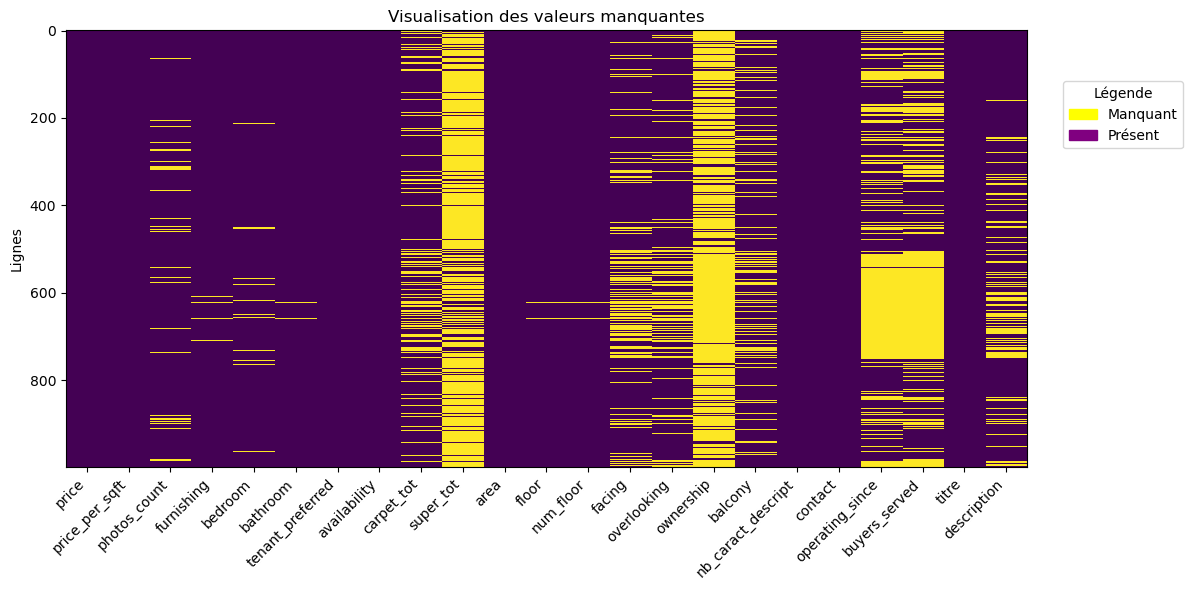

In [22]:
# Création du graphique
plt.figure(figsize=(12, 6))  # Taille de la figure
plt.imshow(df.isnull(), aspect='auto', cmap='viridis', interpolation='none')

# Ajout du titre et des étiquettes des colonnes
plt.ylabel("Lignes")
plt.title("Visualisation des valeurs manquantes")
plt.xticks(ticks=np.arange(df.shape[1]), labels=df.columns, rotation=45, ha='right', fontsize=10)

# Ajout d'une légende en dehors de la figure
present_patch = mpatches.Patch(color='purple', label='Présent')
missing_patch = mpatches.Patch(color='yellow', label='Manquant')
plt.legend(
    handles=[missing_patch, present_patch], 
    loc='upper center', 
    bbox_to_anchor=(1.1, 0.9),  # Position en dehors de la figure
    ncol=1,  # Nombre de colonnes dans la légende
    title="Légende", 
    fontsize=10
)

# Affichage
plt.tight_layout()  # Ajuste l'espacement pour éviter le chevauchement
plt.show()

Le graphique nous montre la représentation des valeurs manquantes parmi les valeurs présentes (en violet). La colonne `super_tot` comporte de nombreuses valeurs manquantes ainsi que les variables `operating_since`et `buyers_served`. Les nombreuses valeurs manquantes de ces deux variables s'expliquent par le fait qu'elles dépendent de la variable `contact`. En effet, seules les lignes avec la catégorie `agent` de la variable `contact` peuvent remplir dans ces deux colonnes. Ces variables s'expliquent respectivement comme l'année à laquelle l'agent immobilier a commencé à faire ce métier, et le nombre de clients servis. Nous pouvons donc aisément comprendre qu'une annonce mise en ligne par un particulier (`owner` dans la variable `contact`) ne peut pas remplir ces colonnes là. Ce sont donc des valeurs manquantes aléatoires (MAR).

Nous pouvons également mettre en lumière les valeurs manquantes à l'aide d'un diagramme en bâtons représentant la proportion de valeur présente.

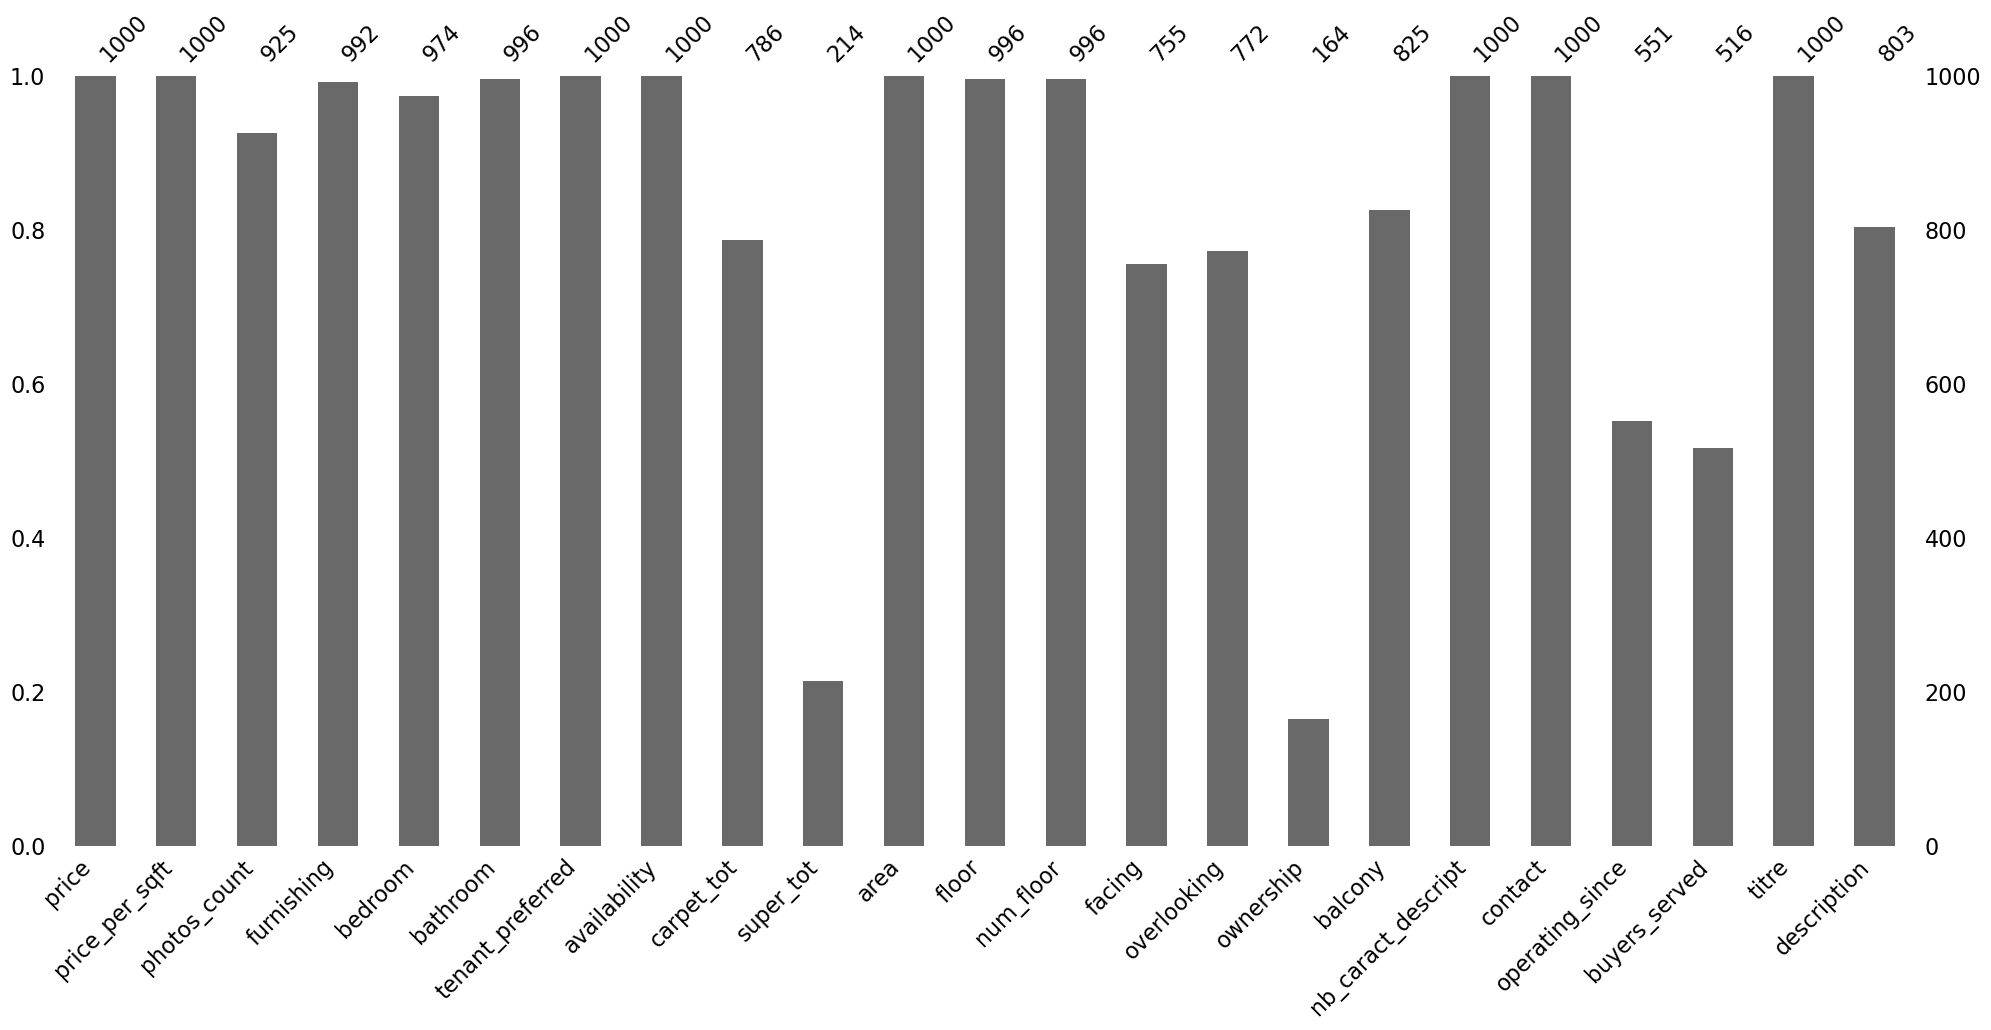

In [24]:
# Création du graphique
msno.bar(df)
plt.show()

Nous voyons bien la faible proportion de valeurs présentes dans les colonnes `super_tot` et `ownership`.

Nous pouvons également afficher le pourcentage de valeurs manquantes de chaque colonne pour être plus précis qu'un schéma, c'est un tableau complémentaire au premier.

In [26]:
# Tableau des valeurs manquantes par colonne
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_table = pd.DataFrame({'Valeurs manquantes': missing_values, 'Pourcentage': missing_percent})
print(missing_table)

                    Valeurs manquantes  Pourcentage
price                                0          0.0
price_per_sqft                       0          0.0
photos_count                        75          7.5
furnishing                           8          0.8
bedroom                             26          2.6
bathroom                             4          0.4
tenant_preferred                     0          0.0
availability                         0          0.0
carpet_tot                         214         21.4
super_tot                          786         78.6
area                                 0          0.0
floor                                4          0.4
num_floor                            4          0.4
facing                             245         24.5
overlooking                        228         22.8
ownership                          836         83.6
balcony                            175         17.5
nb_caract_descript                   0          0.0
contact     

La colonne `ownership` qui contient 83,6% de valeurs manquantes pourrait être supprimé car son taux de valeurs manquantes surpasse largement les 50% ou 70% recommandés pour supprimer une colonne. Nous attendrons d'avoir plus de connaissance à propos de cette variable pour prendre une décision.

Le module missingno propose une méthode pour visualiser les corrélations entre les valeurs manquantes des variables sous forme de heatmap. Cela permet de voir quelles variables ont des schémas de valeurs manquantes similaires. Comme le nombre de variables est importante, nous allons analyser les colonnes contenant des valeurs manquantes uniquement.

<Figure size 1200x800 with 0 Axes>

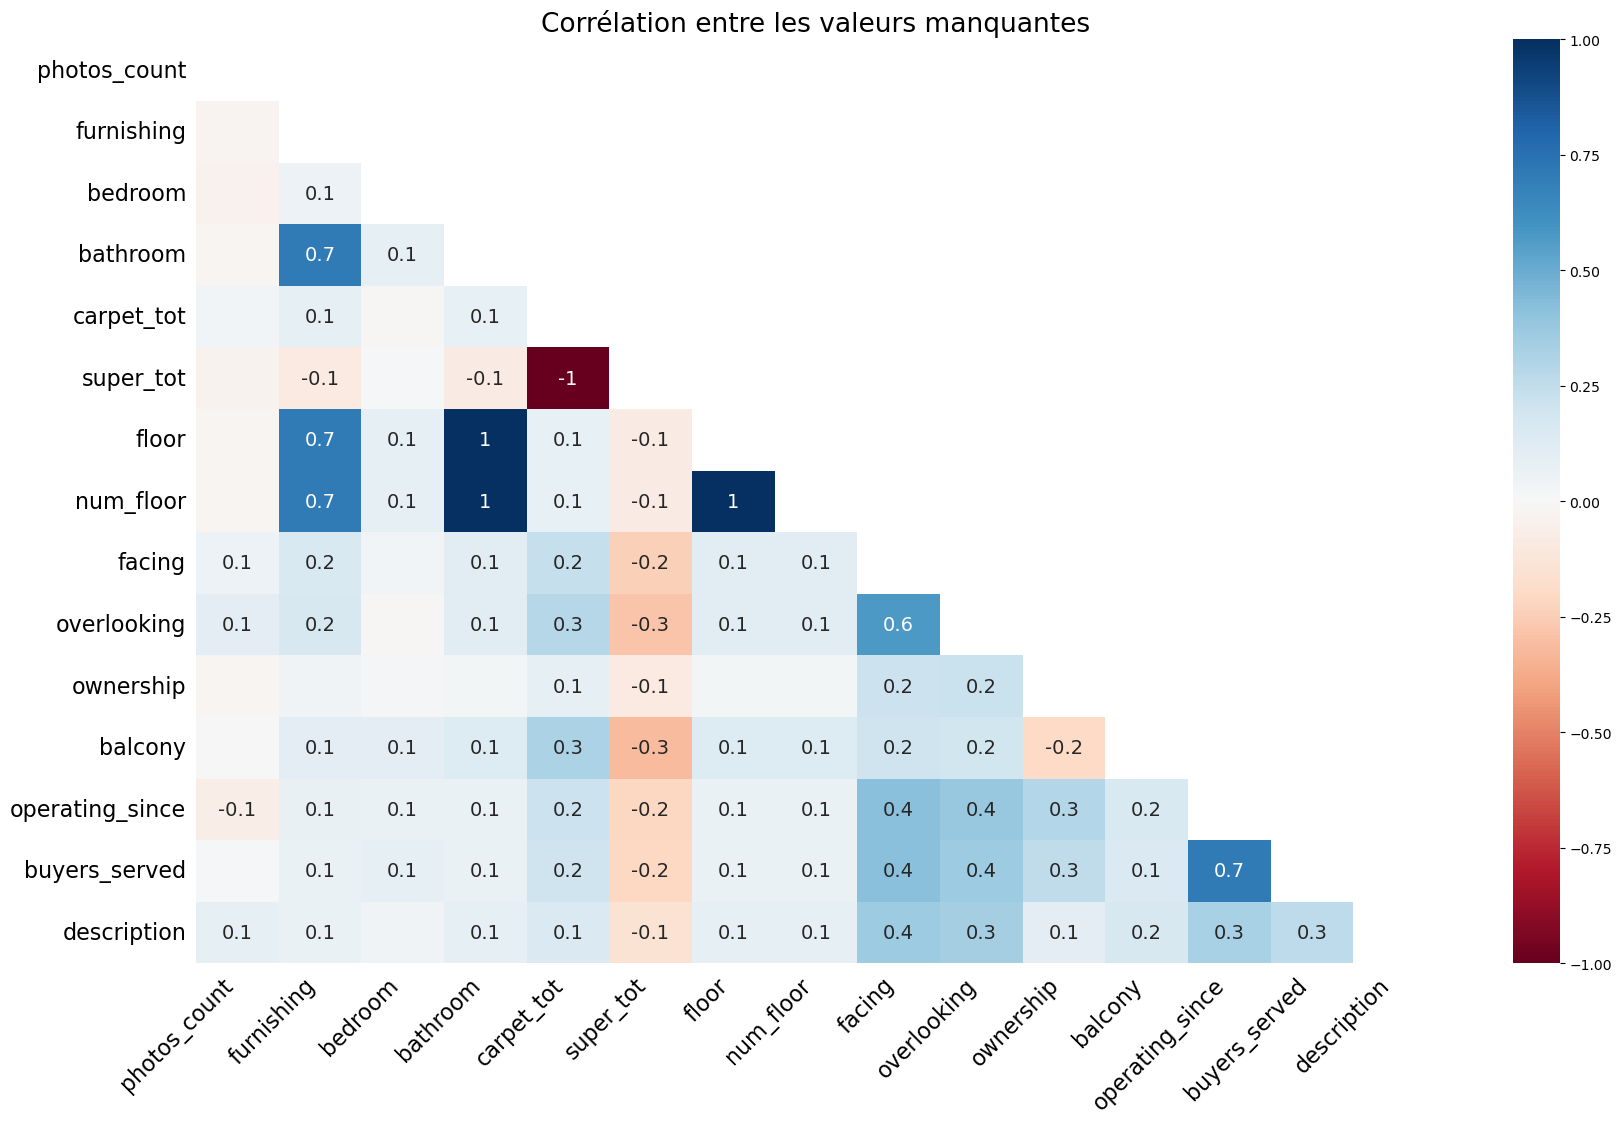

In [28]:
# Filtrage des colonnes contenant des valeurs manquantes
missing_cols = df.columns[df.isnull().any()]

# Création du graphique
plt.figure(figsize=(12, 8))
msno.heatmap(df[missing_cols])

# Ajout d'un titre au graphique
plt.title("Corrélation entre les valeurs manquantes", fontsize=19)

# Affichage
plt.show()

Nous pouvons voir que le schéma de répartition des valeurs manquantes entre les variables `bathroom` et `floor` est similaire. Nous pouvons penser que les personnes qui n'ont remplis entièrement les annonces immobilières pour ceux deux variables sont les mêmes. A ces deux variables nous pouvons ajouter `furnishing`, même si la corrélation est un peu plus faible. Le graphique de visualisation des valeurs manquantes (le premier graphique) nous montre bien cela.

La corrélation parfaite entre `floor` et `num_floor` s'explique par le fait que `num_floor` est une variable qui a été créée à partir de `floor` pendant la phase de netoyage des données.

Par ailleurs, la forte corrélation des valeurs manquantes entre `operating_since` et `buyers_served` pourrait s'expliquer par le fait que ces deux variables dépendent de la catégorie `agent` de la variable `contact`.

Enfin, la corrélation négative parfaite entre `super_tot` et `carpet_tot` est dû au fait que ceux qui ont remplis ces annonces ont du choisir entre une de ces deux options.

### Les méthodes de traitement des valeurs manquantes

#### La suppression des valeurs manquantes

En Python :
   - **Supprimer les lignes avec des valeurs manquantes** :
     ```python
     df.dropna(axix=0)
     ```
   - **Supprimer les colonnes avec des valeurs manquantes** :
     ```python
     df.dropna(axis=1)
     ```

Décider de supprimer une ligne ou une colonne contenant des valeurs manquantes dépend du contexte, de la proportion de données manquantes, et de l'importance des variables ou observations dans notre analyse. Plusieurs critères sont à prendre en compte avant une telle opération.

Dans le cas de la suppression d'une ligne, il faut d'abord regarder la proportion de lignes affectée. Si seul un petit nombre de lignes contient des valeurs manquantes (par exemple, <5% des lignes) une suppression peut être envisagée. De même si les données manquent de façon aléatoire (MCAR) et que leur suppression n'introduit pas de biais. C'est aussi le cas si les lignes concernées ne représentent pas des observations importantes (critiques) ou si elles sont considérées comme des "outliers". L'un des derniers cas est si le dataset est très grand et que la suppression de quelques lignes ne réduit pas significativement sa taille.

Pour la suppression des colonnes, nous pouvons décider de les supprimer si elles contiennent trop de valeurs manquantes. En effet, si une colonne contient une proportion élevée de valeurs manquantes (souvent >50% ou 70%), elle est généralement supprimée. Cependant, pour un jeu de données où chaque variable est importante, ce seuil peut être réduit à 20% ou 30%.

Exemple :
```python
# Supprimer les colonnes contenant plus de 50% de valeurs manquantes
threshold = 0.5
df_cleaned = df.loc[:, df.isnull().mean() < threshold]
```

Par ailleurs, si la colonne est peu informative (richesse de l’information faible), c’est-à-dire si la colonne a peu de variabilité ou de pertinence pour l’analyse, même si les données manquantes sont limitées, la colonne peut être supprimée car cette colonne a un impact minimal sur le modèle ou l'analyse et colonne n’a pas d’influence significative sur les résultats attendus. C'est par exemple le cas des colonne `titre` et `description` qui contienne des chaînes de caractères et dont le taux de valeur unique doit approcher les 100%.

In [33]:
# Suppression des colonnes titre et description

df = df.drop(columns=['titre', 'description'])

Enfin, si les informations de la colonne peuvent être déduites d'autres variables dans le dataset (redondance) car la colonne manquante est fortement corrélée avec d'autres colonnes qui ont peu ou pas de valeurs manquantes, nous pouvons envisager de la supprimer et d'utiliser les colonnes corrélées comme substituts.

Cependant, Si les valeurs manquantes sont non aléatoires (MNAR) et représentent une information importante (par exemple, un revenu non déclaré est peut-être corrélé à un revenu élevé), il peut être préférable de conserver la colonne et de coder les valeurs manquantes comme une catégorie distinctive ou une valeur spéciale pour conserver l’information.

Si la suppression de lignes ou de colonnes entraîne une perte importante d'informations, il peut être envisageable d'imputer les valeurs manquantes avec une méthode appropriée.

#### L'imputation des valeurs manquantes

Il peut être raisonnable de remplacer les valeurs manquantes par une constante ou une valeur par défaut :
```python
     df['colonne'].fillna(0, inplace=True)
```

C'est par exemple le cas de la variable `photos_count` où les valeurs manquantes peuvent être remplacées par 0.

In [37]:
df['photos_count'].fillna(0, inplace=True)

C:\Users\ORY\AppData\Local\Temp\ipykernel_6416\3583998869.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['photos_count'].fillna(0, inplace=True)


Il est également possible de remplacer les valeurs manquantes par une statistique comme la moyenne et la médiane pour les variables quantitatives ou encore le mode pour les variables qualitatives.
     
```python
     df['colonne'].fillna(df['colonne'].mean(), inplace=True)
```
     
Pour les données temporelles, il est possible de faire une interpolation (linéaire ou non).

```python
     df['colonne'].interpolate(method='linear', inplace=True)
```
     
Enfin, nous pouvons utiliser des techniques avancées dont des modèles prédictifs comme le KNN imputation, des régressions ou même des algorithmes d’apprentissage automatique pour prédire les valeurs manquantes, ce que nous ne ferons pas ici.

En résumé, la gestion des valeurs manquantes dépend du contexte et des données disponibles. Une compréhension approfondie de l'origine des valeurs manquantes est essentielle pour choisir la méthode la plus appropriée, par la suite il est important d’évaluer l’impact de cette méthode en vérifiant si l’imputation ou la suppression modifie significativement les résultats analytiques.

## Les Valeurs aberrantes

En statistiques, les valeurs aberrantes (ou outliers en anglais) sont des observations qui diffèrent significativement de la majorité des autres données. Elles peuvent être causées par des erreurs de mesure, des anomalies dans le processus de collecte des données ou des phénomènes réellement inhabituels.

Par exemple, nous réunissons 10 travailleurs dans une pièce et l'un d'eux est un joueur de football de renommé internationale. Nous faisons la moyenne des salaires de ces travailleurs et trouvons une valeur de 201.800€ par mois. En regardant le détail nous voyons que 9 travailleurs gagnent 2000€ par mois et le footballeur gagne 2.000.000€/mois. Nous voyons bien que le salaire du footballeur est une valeur aberrante dans cet échantillon. En effet, le salaire de ce travailleur est bien réel et non-erroné mais il diffère grandement de celui des autres travailleurs. Il tire donc la moyenne vers le haut.

Comme nous venons de le voir avec cet exemple, les valeurs aberrantes peuvent influencer les résultats statistiques, faussant les moyennes, les écarts-types et les modèles prédictifs. Elles ont un impact non négligeable sur les analyses, il est donc nécessaire de les identifier pour pouvoir les gérer et ainsi améliorer la qualité des données pour garantir des conclusions plus fiables. De plus, cela va fausser notre compréhension du jeu de données et nous conduire à émettre des hypothèses erronées sur ce dernier.

Cependant, dans certains cas, les valeurs aberrantes sont des indicateurs précieux (par exemple pour détecter les fraudes, pannes ou comportements rares). Il est donc important de découvrir la nature de ces valeurs aberrantes (erreur ou phénomène rare) et de prendre des actions adaptées en conséquence.

### Repérer les valeurs aberrantes

Plusieurs méthodes permettent d'identifier les valeurs aberrantes dans un jeu de données. 

#### Les Méthodes graphiques

Tout d'abord, une inspection visuelle peut être menée pour montrer graphiquement ces outliers. Ces différents graphiques peuvent être :
   - La [boîte à moustache](#La-Box-Plot) (boxplot) où les valeurs aberrantes apparaissent comme des points isolés au-dessus ou en dessous des "moustaches".
   - Le diagramme de dispersion est utile pour repérer les valeurs aberrantes dans des données bivariées ou multivariées. Les outliers apparaissent éloignés des autres points dans le nuage.
   - L'histogramme ou la courbe de densité montre les valeurs aberrantes. En effet, ces observations se retrouvent éloignées de la majorité.

#### La Règle des 1,5 fois l'écart interquartile (IQR)

Cette méthode utilise le calcul des quartiles $Q1$ (25e percentile) et $Q3$ (75e percentile) (signet boxplot) et celui de l'écart interquartile $IQR = Q3 - Q1$. Le seuil de décision pour déterminer les valeurs aberrantes est :

- Inférieur : $Q1 - 1,5 \times IQR$,
- Supérieur : $Q3 + 1,5 \times IQR$.

Les données en dehors de ces seuils sont considérées comme aberrantes.

#### La Méthode des z-scores

Le Z-score, également connu sous le nom de score standard, est une mesure statistique qui décrit la position d’une valeur donnée par rapport à la moyenne d’un groupe de valeurs. Plus précisément, un Z-score indique combien d’écarts-types une valeur donnée est au-dessus ou en dessous de la moyenne. Les données brutes sont converties selon une opération appelée « distribution Z » (ou normalisation). Il s'agit d'une distribution normale standard, avec une moyenne de 0 et un écart-type de 1.
     $$
     z = \frac{x - \mu}{\sigma}
     $$
     où $\mu$ est la moyenne et $\sigma$ l’écart-type.
     
En théorie, on devrait utiliser la moyenne et l'écart type de la population, en pratique les statisticiens utilisent souvent les indicateurs de l'échantillon.

Un Z-score peut être positif ou négatif, indiquant respectivement si la valeur est supérieure ou inférieure à la moyenne. Par exemple, un Z-score de +1,0 indique que la valeur est au-dessus de la moyenne, tandis qu’un Z-score de -1,0 indique qu’elle est en dessous de la moyenne. La règle courante est qu'un $|z| > 3$ indique une valeur aberrante, car cette valeur se situe au-delà de 3 $\sigma$ par rapport à la moyenne d'une distribution normale (voir le schéma distribution normale).

En plus d'identifier une valeur aberrante dans un jeu de données, le Z-score est utilisé en statistique pour normaliser les données (nous aurons l'occasion d'en reparler plus bas dans le document). Il est également utilisé en statistique inférentielle pour des tests d'hypothèses qui permettent de déterminer la probabilité d’observer une valeur donnée sous l’hypothèse nulle.

#### Les Méthodes basées sur des modèles

Il peut être utile d'utiliser des modèles statistiques dans certains cas (absence de normalité par exemple). Ces modèles peuvent être des modèles de régressions mais également des algorithmes plus complexes comme le K-Nearest Neighbors (KNN), l'Isolation Forest, ou le DBSCAN. Nous n'utiliserons pas ce genre de modèles dans cette analyse de données.

### Le traitement des valeurs aberrantes

Une fois détectées, les valeurs aberrantes peuvent être traitées de différentes manières, en fonction du contexte et des objectifs de l'analyse.

#### Conserver les valeurs aberrantes

Si elles représentent des phénomènes réels ou intéressants (p. ex., un tremblement de terre exceptionnel ou des ventes records), les valeurs extrêmes doivent être conservées. Elles peuvent aussi être analysées séparément.

#### Corriger les erreurs

Si les valeurs aberrantes sont dues à des erreurs (p. ex., erreur de saisie ou capteur défectueux), elles peuvent être corrigées si des informations supplémentaires sont disponibles. Par exemple, elles peuvent être remplacées par une estimation réaliste basée sur le contexte.

#### Exclure les valeurs aberrantes

Si elles sont dues à des erreurs ou si elles faussent significativement les analyses, les valeurs extrêmes peuvent être exclues.

#### Transformer les données

Nous pouvons aussi appliquer des transformations (p. ex., logarithmique, racine carrée) pour réduire l'impact des valeurs extrêmes. Il est également possible d'utiliser des métriques robustes comme la médiane ou l’écart interquartile au lieu de la moyenne et de l’écart-type.

#### Méthodes de pondération

Dans certains modèles, les valeurs aberrantes peuvent être pondérées pour réduire leur influence sans les supprimer totalement.

## Encodage des Données Catégorielles

L’encodage des données catégorielles est une étape de prétraitement en analyse de données qui consiste à transformer des variables catégorielles (qualitatives) en une représentation numérique utilisable par les algorithmes. En effet, les algorithmes mathématiques nécessitent généralement des données numériques pour fonctionner correctement, d’où l’importance de cette transformation.

Il existe plusieurs méthodes d'encodage dont le Label Encoding. Il faut alors remplacer chaque catégorie par un entier unique, cela a l'avantage de ne rajouter qu'une variable. Cependant, cela introduit un ordre artificiel entre les catégories (ce qui est problématique pour les données nominales), il est donc préférable d'utiliser cette méthode sur des variables ordinales.

Il existe également le One-Hot Encoding qui crée une colonne binaire (0 ou 1) pour chaque catégorie. Cette méthode permet d'éviter l’ordre artificiel et convient donc aux variables nominales. Cependant il augmente la dimension des données, surtout s'il y a beaucoup de catégories.

Des techniques d'encodage plus avancées existent, nous ne ferons que les mentionner ici. Il existe par exemple l'encodage à base de fréquence qui  remplace chaque catégorie par la fréquence d’apparition de cette catégorie dans le jeu de données. Il peut cependant introduire des biais si les fréquences sont déséquilibrées. Ce type d'encodage est utile si les fréquences contiennent une information pertinente.

Enfin, le Target Encoding remplace chaque catégorie par la moyenne de la variable cible associée à cette catégorie. Il permet de capturer directement la relation entre les catégories et la cible. Cependant, il y a un risque de surajustement ce qui nécessite donc une gestion appropriée.

Nous n'allons ici qu'utiliser le One-Hot Encoding à l'aide de la librairie Pandas.

In [65]:
# Application du One-Hot Encoding avec Pandas
df_encoded = pd.get_dummies(df, columns=['furnishing','tenant_preferred','availability','facing','overlooking','contact'], drop_first=True, dtype='int')

print("\nDataFrame après One-Hot Encoding :")
print(df_encoded)


DataFrame après One-Hot Encoding :
      price  price_per_sqft  photos_count  bedroom  bathroom  carpet_tot  \
0     70000              54          20.0      3.0       3.0      1300.0   
1     18000              36          16.0      1.0       1.0       500.0   
2     95000              35           9.0      3.0       3.0      2700.0   
3    100000              28          11.0      3.0       3.0         NaN   
4    150000              71           8.0      3.0       3.0      2106.0   
..      ...             ...           ...      ...       ...         ...   
995    8500              34           4.0      1.0       1.0       250.0   
996   10000              22           4.0      1.0       1.0       450.0   
997   55000              37          19.0      3.0       3.0         NaN   
998   35000              47           6.0      2.0       2.0       750.0   
999    7500              88           9.0      2.0       1.0        85.0   

     super_tot  area            floor  num_floor  .

Dans l'argument "columns", nous devons indiquer les colonnes à encoder. Pour éviter une colinéarité parfaite entre les colonnes et pour ne pas surcharger notre dataset nous utilisons l’option `drop_first=True` dans `pd.get_dummies` pour supprimer la première catégorie de nos variables, et ainsi ces catégories deviennent la catégorie de référence pour cette variable.

# Statistique Exploratoire

Avant de commencer l'analyse exploratoire, parlons de la taille de notre dataset.

In [69]:
print("Taille du tableau :", df.shape)
print("Noms des colonnes :", df.columns)

Taille du tableau : (1000, 21)
Noms des colonnes : Index(['price', 'price_per_sqft', 'photos_count', 'furnishing', 'bedroom',
       'bathroom', 'tenant_preferred', 'availability', 'carpet_tot',
       'super_tot', 'area', 'floor', 'num_floor', 'facing', 'overlooking',
       'ownership', 'balcony', 'nb_caract_descript', 'contact',
       'operating_since', 'buyers_served'],
      dtype='object')


Nous pouvons voir qu'il y a tout d'abord 1000 lignes et 21 colonnes dans notre jeu de données. Le nombre de données est suffisant pour être considéré comme représentatif de la "population". En effet, selon la formule de Cochran, pour qu'un échantillon représente la population cible dans son ensemble il faut que le nombre d'annonces d'immobilières soit de 664 annonces.

Taille de l’échantillon idéale = $(Z)^2 \times \frac{\sigma\times(1-\sigma)}{e^2}$

avec le score Z qui représente le niveau de confiance (99 % : score Z = 2,576), $\sigma$ l'écart type revient à estimer dans quelle mesure les annonces varieront les unes des autres et de la moyenne du groupe. Nous prennons généralement un écart type de 0,5. La marge d’erreur $e$ représente ici la différence acceptable, en pourcentage, entre la moyenne de votre échantillon et la moyenne de votre population. Nous choisissons ici une marge d'erreur de 5%.

Taille de l’échantillon idéale = $(2,576)^2 \times 0,5 \times \frac{0,5}{0,05^2} = 663,5776 = 664$

En tenant compte de la marge d'erreur : $663,5776 \times 1,05 = 696,76 = 697$ annonces

En ayant 1000 annonces nous avons un échantillon représentatif de la population des annonces de location de biens à New Delhi.

## Statistique Univariée

Après le prétraitement des données, nous pouvons commencer à regarder, comprendre et visualiser nos variables de façon tout d'abord univarié. Grâce à cela nous pourrons avoir une idée du type de distribution pris par nos données ou encore savoir s'il y a des points aberrants.

Nous allons utiliser dans un premier temps utiliser le dataset `df`, puis dans la phase d'interprétation nous utiliserons le dataset `df_encoded`, mais avant ça, commençons par parler des différents types de variables.


### Les différents types de données


Il existe différents types de données.

<img style="float: center; width: 500px; height: auto;" src="images/Types-de-variables.png"/>

Schéma de Gwezheneg ORY, fait avec Excel 2016

En statistique, les variables représentent des caractéristiques ou des attributs qui peuvent prendre différentes valeurs dans un ensemble de données. Les types de variables influencent les méthodes d'analyse appropriées. Elles se classent en plusieurs catégories.

Il y a tout d'abord les variables quantitatives qui mesurent des valeurs numériques pouvant être utilisées dans des calculs. Celles-ci se regroupent les variables discrètes, dont les valeurs sont des nombres entiers et qui sont souvent obtenus par comptage, et les variables continues, dont les valeurs peuvent prendre n’importe quelle valeur dans un intervalle donné (cela inclut des fractions ou des décimales). Il y a par exemple la taille (en cm) ou encore la durée d'une course (en secondes).

Il y a également les variables qualitatives (catégorielles) qui décrivent des catégories ou des groupes et qui ne sont pas mesurées numériquement. Nous retrouvons les variables nominales où les différentes catégories ne suivent pas d’ordre logique (couleur des yeux, sexe ou encore nationalité). Il y a aussi les variables ordinales, qui sont composées de catégories qui suivent un ordre logique, cependant l’écart entre les catégories n’est pas mesurable (niveau d’éducation ou satisfaction par exemple).


Nous allons commencer par nous intéresser aux variables quantitatives.

### Variables quantitatives

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               1000 non-null   int64  
 1   price_per_sqft      1000 non-null   int64  
 2   photos_count        1000 non-null   float64
 3   furnishing          992 non-null    object 
 4   bedroom             974 non-null    float64
 5   bathroom            996 non-null    float64
 6   tenant_preferred    1000 non-null   object 
 7   availability        1000 non-null   object 
 8   carpet_tot          786 non-null    float64
 9   super_tot           214 non-null    float64
 10  area                1000 non-null   int64  
 11  floor               996 non-null    object 
 12  num_floor           996 non-null    float64
 13  facing              755 non-null    object 
 14  overlooking         772 non-null    object 
 15  ownership           164 non-null    object 
 16  balcony

Nous pouvons voir que notre jeu de données comporte 11 variables quantitatives (ce sont les variables de type int64 ou float64). Bien que les variables `operating_since` et `num_floor` soient de type float64 (nombre décimale), elles ne représentent pas des variables quantitatives.

#### Tendances Centrales

##### La Moyenne
En statistique, il existe plusieurs types de moyennes, chacune ayant des propriétés spécifiques et des utilisations adaptées à différents contextes.

###### La moyenne arithmétique
La moyenne arithmétique est la mesure de position la plus utilisée et la plus importante elle mesure également la position de la tendance centrale d’une distribution. Elle permet de résumer la série statistique et elle prend en considération toutes les valeurs. Cependant, elle est sensible aux valeurs aberrantes (extrêmes). La moyenne est égale à la somme de toutes les valeurs divisées par le nombre de valeurs.
$$
\text{Moyenne arithmétique} = \frac{\sum_{i=1}^n x_i}{n}
$$ 
Où $x_i$ représente chaque valeur et $n$ le nombre total de valeurs. 
###### La Moyenne pondérée
La moyenne pondérée attribue un poids à chaque valeur pour refléter leur importance relative.
$$
\text{Moyenne pondérée} = \frac{\sum_{i=1}^n w_i x_i}{\sum_{i=1}^n w_i}
$$  
Où $w_i$ est le poids associé à chaque valeur $x_i$.  

Il existe d’autres types de moyenne telle que la moyenne géométrique, harmonique, quadratique ou encore tronquée, mais elles ne sont pas pertinentes dans le cadre de cette analyse.

In [78]:
# Moyenne arithmétique du prix de location des biens à New Delhi
df.loc[:, 'price'].mean()

64347.388

Le prix moyen d'un bien en location à New Delhi est d'environ 64347 roupies indiennes par mois.

Nous allons maintenant trouver la moyenne du prix de location des biens pondéré par le nombre de salle de bain. Cependant, comme la colonne `bathroom` possède des valeurs manquantes, nous allons exclure les lignes où les poids (le nombre de salles de bain) sont manquants.

In [80]:
# Calcul de la moyenne pondérée en ignorant les valeurs manquantes
def moyenne_ponderee(df, price, bathroom):
    # Filtrer les lignes où le poids n'est pas manquant
    valid_rows = df[bathroom].notna()
    
    # Extraire les valeurs et poids valides
    valeurs = df.loc[valid_rows, price]
    poids = df.loc[valid_rows, bathroom]
    
    # Calcul de la moyenne pondérée
    moyenne = (valeurs * poids).sum() / poids.sum()
    return moyenne

# Utilisation
moyenne = moyenne_ponderee(df, 'price', 'bathroom')
print("Moyenne pondérée :", moyenne)

Moyenne pondérée : 90132.03036783576


Selon le jeu de données, la moyenne du prix de location des biens pondéré par le nombre de salle de bain est de 90132 roupies indiennes.

Dans ce cas présent, la moyenne pondérée fournit une mesure plus représentative du prix moyen en tenant compte de l'impact différentiel des salles de bains sur les prix de location. Nous considérons en faisant ce calcul la possibilité que les biens avec plus de salles de bains aient un impact proportionnel à leur "importance fonctionnelle". Si les biens avec de nombreuses salles de bains sont rares mais très chers, la moyenne pondérée sera tirée vers ces valeurs.

##### La Médiane

La médiane est la valeur qui partage une série d’observations (classées par ordre croissant ou décroissant) en deux sous parties égales. Elle est par conséquent la mesure de la position centrale la plus pertinente en présence des valeurs extrêmes. C’est donc l’indicateur préféré dans la mesure de tendance centrale pour certaines variables en raison de la sensibilité de la moyenne aux valeurs extrêmes. Cependant, elle est influencée par le nombre de données. La médiane peut également être indiquée par l’intersection des polygones des fréquences cumulatives croissantes et décroissantes pour les données groupées.

La médiane est calculée différemment selon que le nombre de valeurs est impair ou pair. Si le nombre de valeurs est impair, la médiane est la valeur au milieu de la série ordonnée (la médiane est la valeur de rang) $\frac{(n+1)}{2}$, où $n$ est le nombre total de valeurs. 

Si le nombre de valeurs est pair, la médiane est la moyenne des deux valeurs centrales : $$Med = \frac{[\frac{n}{2} + (\frac{n}{2} + 1)]}{2}$$

In [83]:
# Médiane du prix de location des biens à New Delhi
df.loc[:, 'price'].median()

38000.0

La médiane est de 38000 roupies par mois ce qui est beaucoup plus faible que la moyenne qui était de 64347 roupies. Cela signifie que des biens avec des prix de location très élevés augmentent la moyenne. 

Nous allons visualiser la médiane et la moyenne dans un histogramme de fréquence.

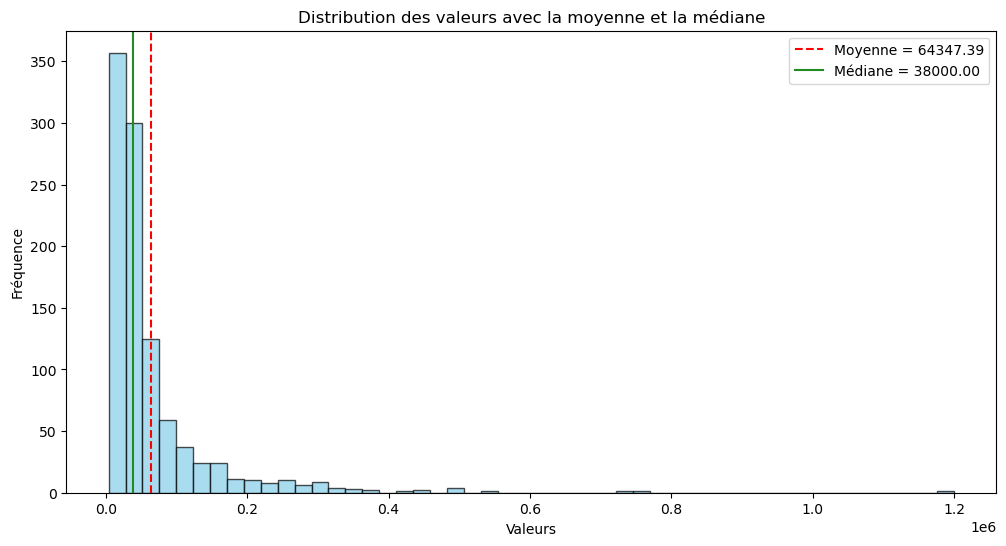

In [85]:
moyenne = df.loc[:, 'price'].mean()
mediane = df.loc[:, 'price'].median()

# Création du graphique
plt.figure(figsize=(12, 6))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Ajout de la moyenne et de la médiane
plt.axvline(moyenne, color='red', linestyle='--', label=f'Moyenne = {moyenne:.2f}')
plt.axvline(mediane, color='forestgreen', linestyle='-', label=f'Médiane = {mediane:.2f}')

# Ajout du titre et des étiquettes
plt.title('Distribution des valeurs avec la moyenne et la médiane')
plt.xlabel('Valeurs')
plt.ylabel('Fréquence')
plt.legend()

# Affichage
plt.show()

La plage de valeur étant très grande, le graphique n'est pas forcément très lisible. Pour remédier à ce problème nous pouvons par exemple visualiser uniquement les valeurs inférieures à 500.000roupies, même si cela signifie perdre à priori 3 valeurs (celles entre 0.6 et 0.8 mais aussi celle à 1.2).

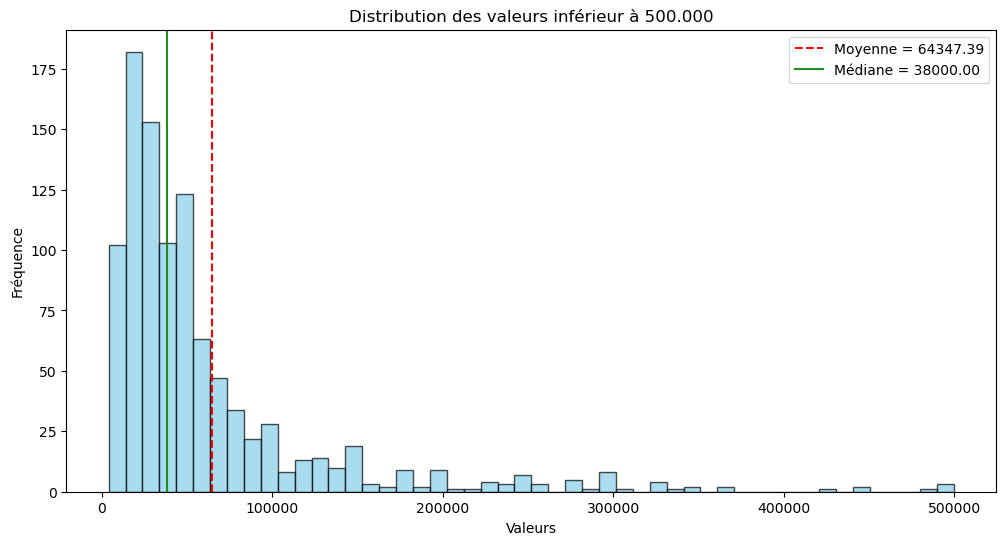

In [87]:
moyenne = df.loc[:, 'price'].mean()
mediane = df.loc[:, 'price'].median()

# Création du graphique
plt.figure(figsize=(12, 6))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7, range=(df['price'].min(),500000))

# Ajout de la moyenne et de la médiane
plt.axvline(moyenne, color='red', linestyle='--', label=f'Moyenne = {moyenne:.2f}')
plt.axvline(mediane, color='forestgreen', linestyle='-', label=f'Médiane = {mediane:.2f}')

# Ajout du titre et des étiquettes
plt.title('Distribution des valeurs inférieur à 500.000')
plt.xlabel('Valeurs')
plt.ylabel('Fréquence')
plt.legend()

# Affichage
plt.show()

L'échelle du graphique est un peu plus lisible avec cette transformation. Nous pouvons remarquer que la moyenne est plus à droite que la médiane, nous viendrons interpréter ce résultat dans la section Indicateur de forme. Nous pouvons déjà dire que ces deux indicateurs se trouvent vers la gauche de la plage de distribution des données.

Par ailleurs, nous pouvons voir que la distribution de la variable `price` ressemble à une loi du khi-2 inverse, une loi hypo-exponentielle ou encore à une loi log-normale, nous aurons l'occasion de tester cette hypothèse plus bas dans le document.


Pour éviter de faire trop de script à la suite nous pouvons générer toutes les variables numériques dans un même graphique et ainsi gagner de la place.

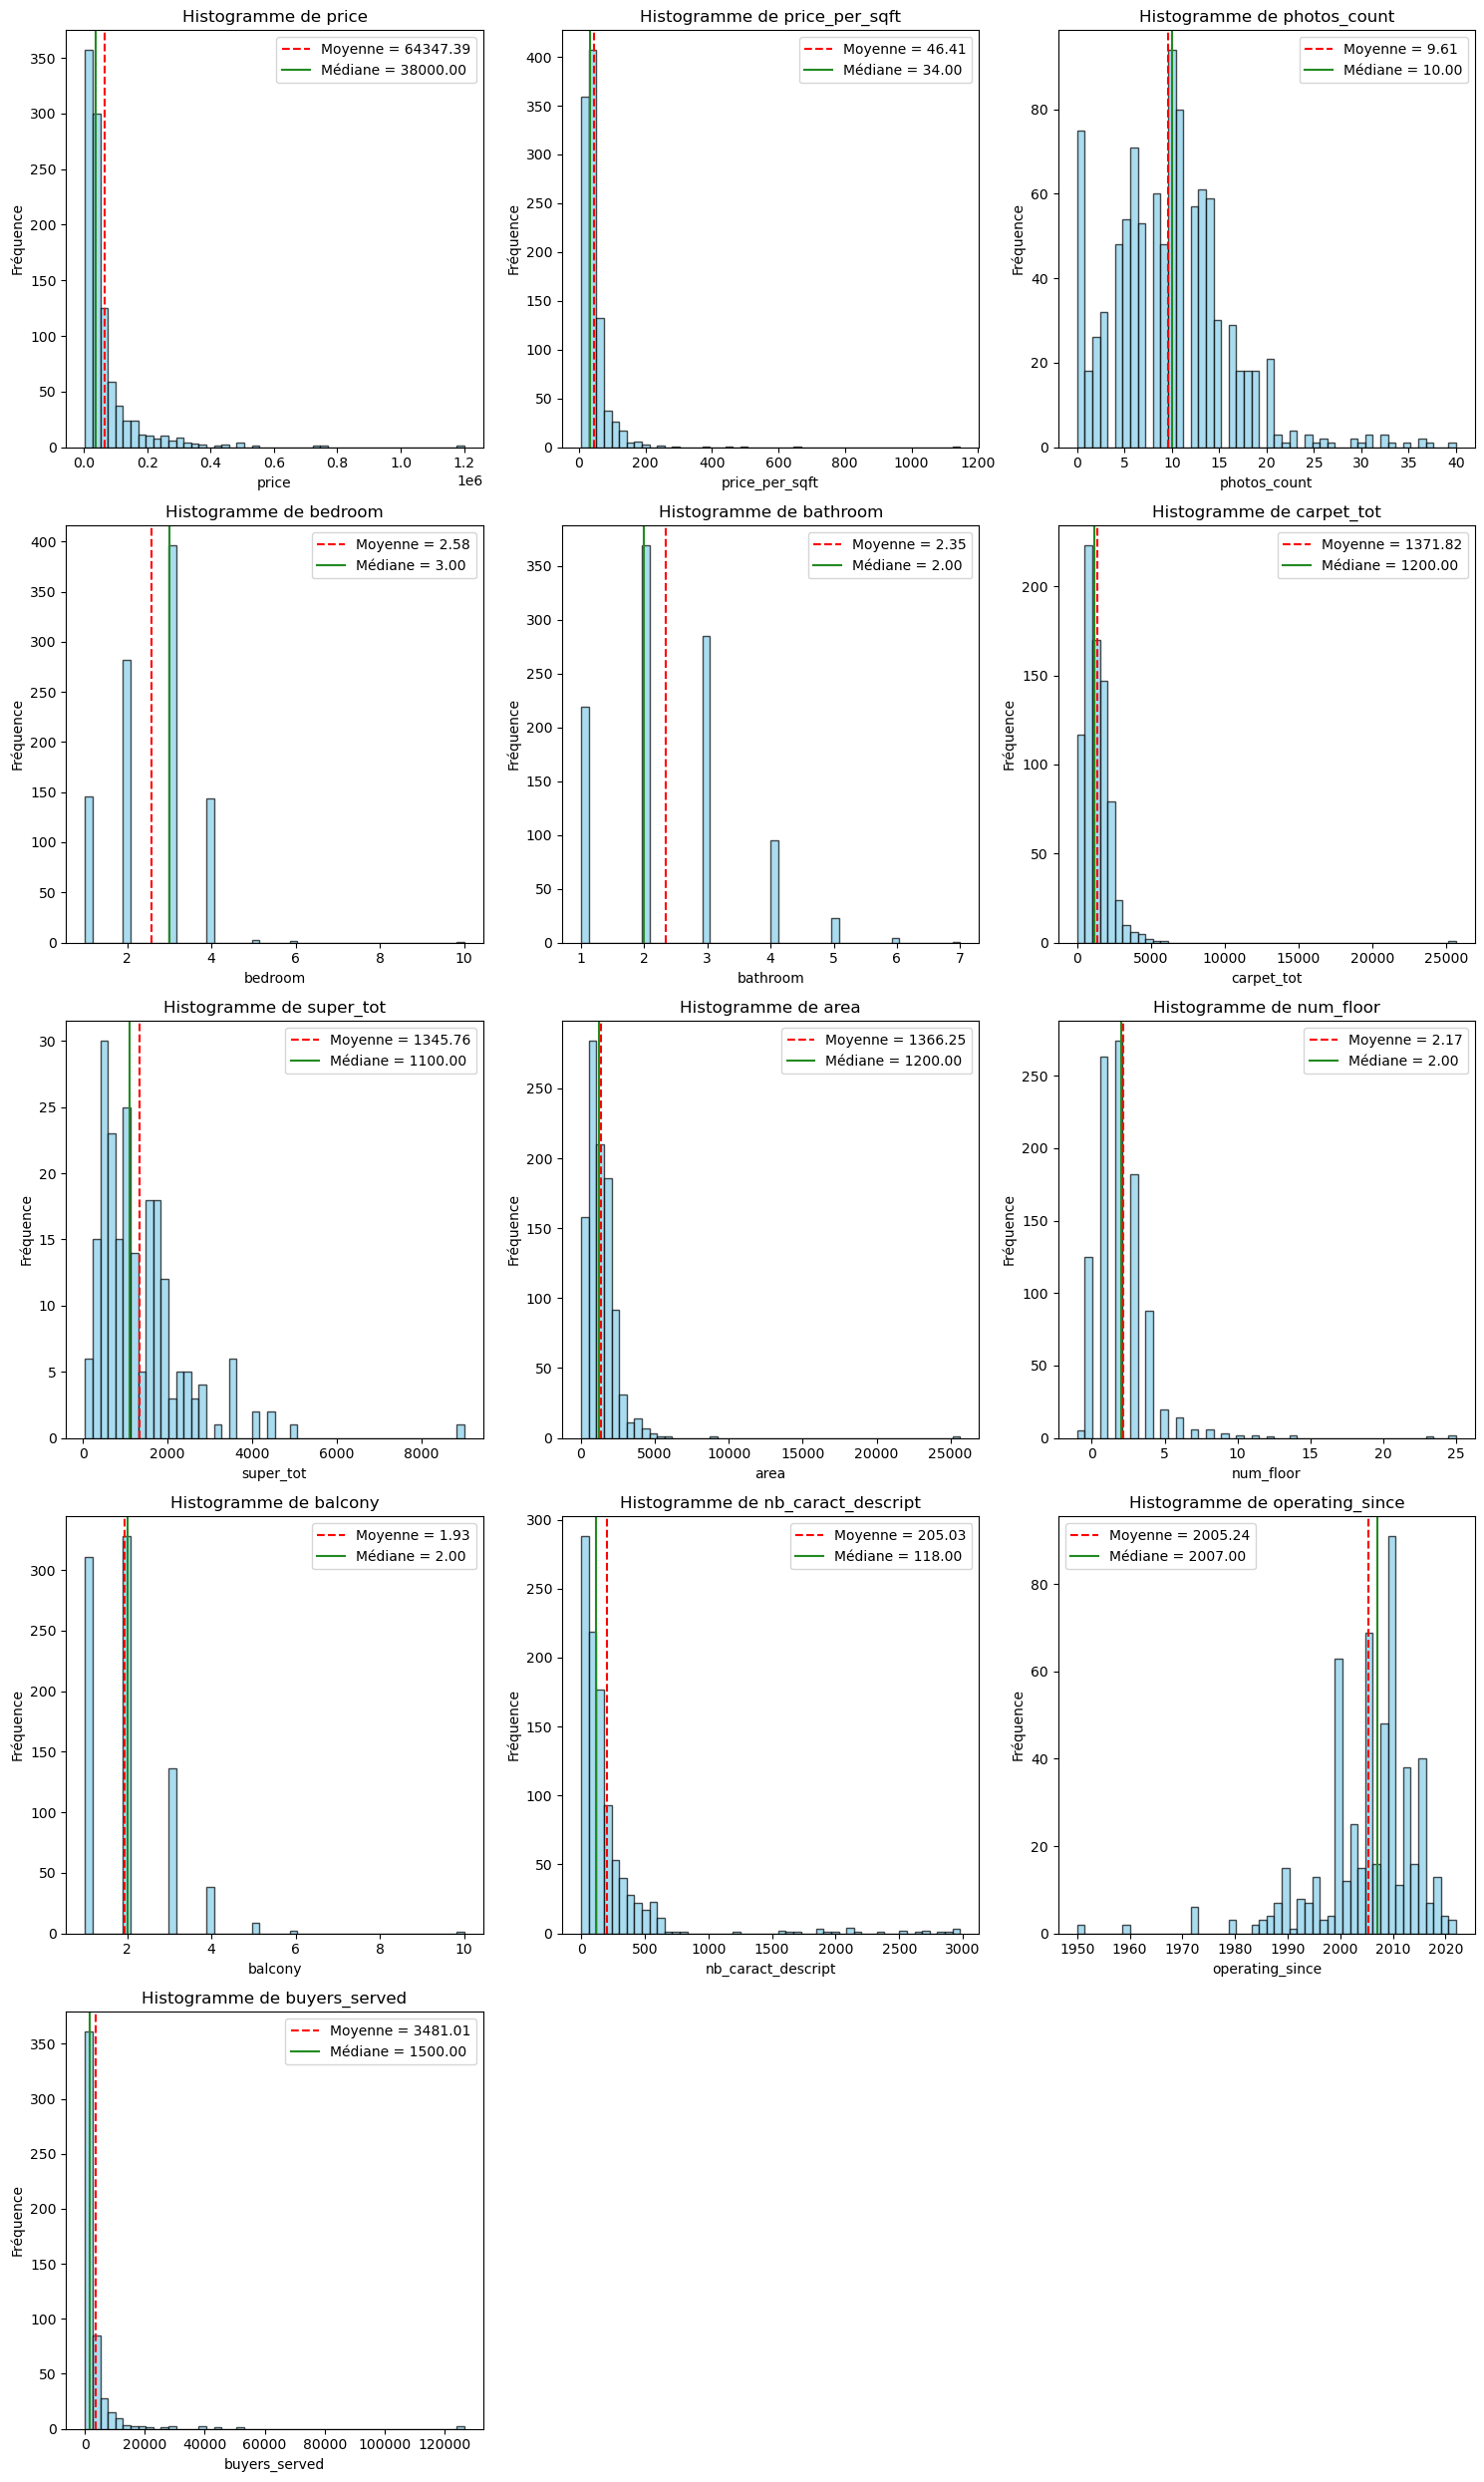

In [89]:
def plot_histograms(df):
    # Sélection des colonnes numériques (int et float)
    numeric_cols = df.select_dtypes(include=['int', 'float']).columns
    
    # Nombre de colonnes numériques
    n_cols = len(numeric_cols)
    
    # Paramètres pour les subplots
    rows = (n_cols // 3) + (n_cols % 3 > 0)  # Calcul des lignes (3 graphiques par ligne)
    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))  # Taille ajustée
    
    # Aplatir les axes pour un accès facile
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        # Calcul de la moyenne et de la médiane
        moyenne = df[col].mean()
        mediane = df[col].median()
        
        # Tracer l'histogramme pour chaque colonne
        axes[i].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Histogramme de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Fréquence')

        # Ajouter la moyenne et la médiane
        axes[i].axvline(moyenne, color='red', linestyle='--', label=f'Moyenne = {moyenne:.2f}')
        axes[i].axvline(mediane, color='forestgreen', linestyle='-', label=f'Médiane = {mediane:.2f}')
        axes[i].legend()
    
    # Supprimer les sous-graphiques inutilisés
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Appel de la fonction
plot_histograms(df)

Les échelles pour les différents graphiques ne sont pas forcément les meilleurs mais il est difficile de trouver des paramètres qui conviendraient pour les 12 graphiques. Cependant, nous pouvons retrouver l'essence globale de chaque variable dans ces graphiques.

Nous savons que la majorité des variables sont discrètes, de plus, les différentes distributions de densité se ressemblent pour beaucoup de variables. Nous pouvons estimer visuellement la densité de la distribution des données de cet échantillon grâce au module `stats` du package `scipy`.

La fonction `gaussian_kde` de `stats` se base sur le principe de l'estimation par noyau (aussi appelé méthode de Parzen-Rosenblatt ou encore kernel density estimation). C'est une méthode non paramétrique d’estimation de la densité de probabilité sous-jacente d’une variable aléatoire. Cette méthode se base sur un échantillon d’une population et elle permet d’estimer la densité en tout point du support. C'est donc une généralisation de la méthode d’estimation par un histogramme.

Si $(x_1, x_2, \ldots, x_N \sim f)$ est un échantillon de $N$ observations i.i.d. d'une variable aléatoire, alors l'estimateur non-paramétrique par la méthode du noyau de la densité est donné par :  

$$\widehat{f}_h(x) = \frac{1}{N \times h} \sum_{i=1}^N K\left(\frac{x - x_i}{h}\right)$$

où $K$ est une fonction de noyau (*kernel*) et $h>0$ est un paramètre appelé "fenêtre", qui régule le degré de lissage de l'estimation. 

Un choix fréquent pour $K$ est la densité d'une loi normale standard (espérance nulle et variance unitaire), définie par :  

$K(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}x^2}$. Cette fonction est utilisée pour pondérer l'influence des points autour de $x$.

Le paramètre de fenêtre $h$ détermine la largeur des noyaux autour de chaque point de données $x_i$. Une petite valeur de $h$ donne une estimation très détaillée, mais sujette au bruit (sur-ajustement). Au contraire, une grande valeur de $h$ produit une estimation plus lisse, mais peut masquer les structures fines des données (sous-ajustement).

Comme nous l'avons dit, c'est une estimation non paramétrique, c'est-à-dire que contrairement aux modèles paramétriques qui supposent une forme précise pour la densité (par exemple, une loi normale), la KDE ne fait aucune hypothèse forte sur la distribution. Elle construit une approximation à partir des données observées uniquement.

Résumons le fonctionnement du KDE : pour chaque point $x$ où la densité doit être estimée, la distance entre $x$ et chaque observation $x_i$ est calculée et pondérée par le noyau $K$. Ces pondérations sont normalisées par $h$, qui ajuste la largeur effective du noyau. La somme des contributions de tous les points est normalisée par le facteur 
$\frac{1}{N\times h}$ pour produire une estimation cohérente de la densité.

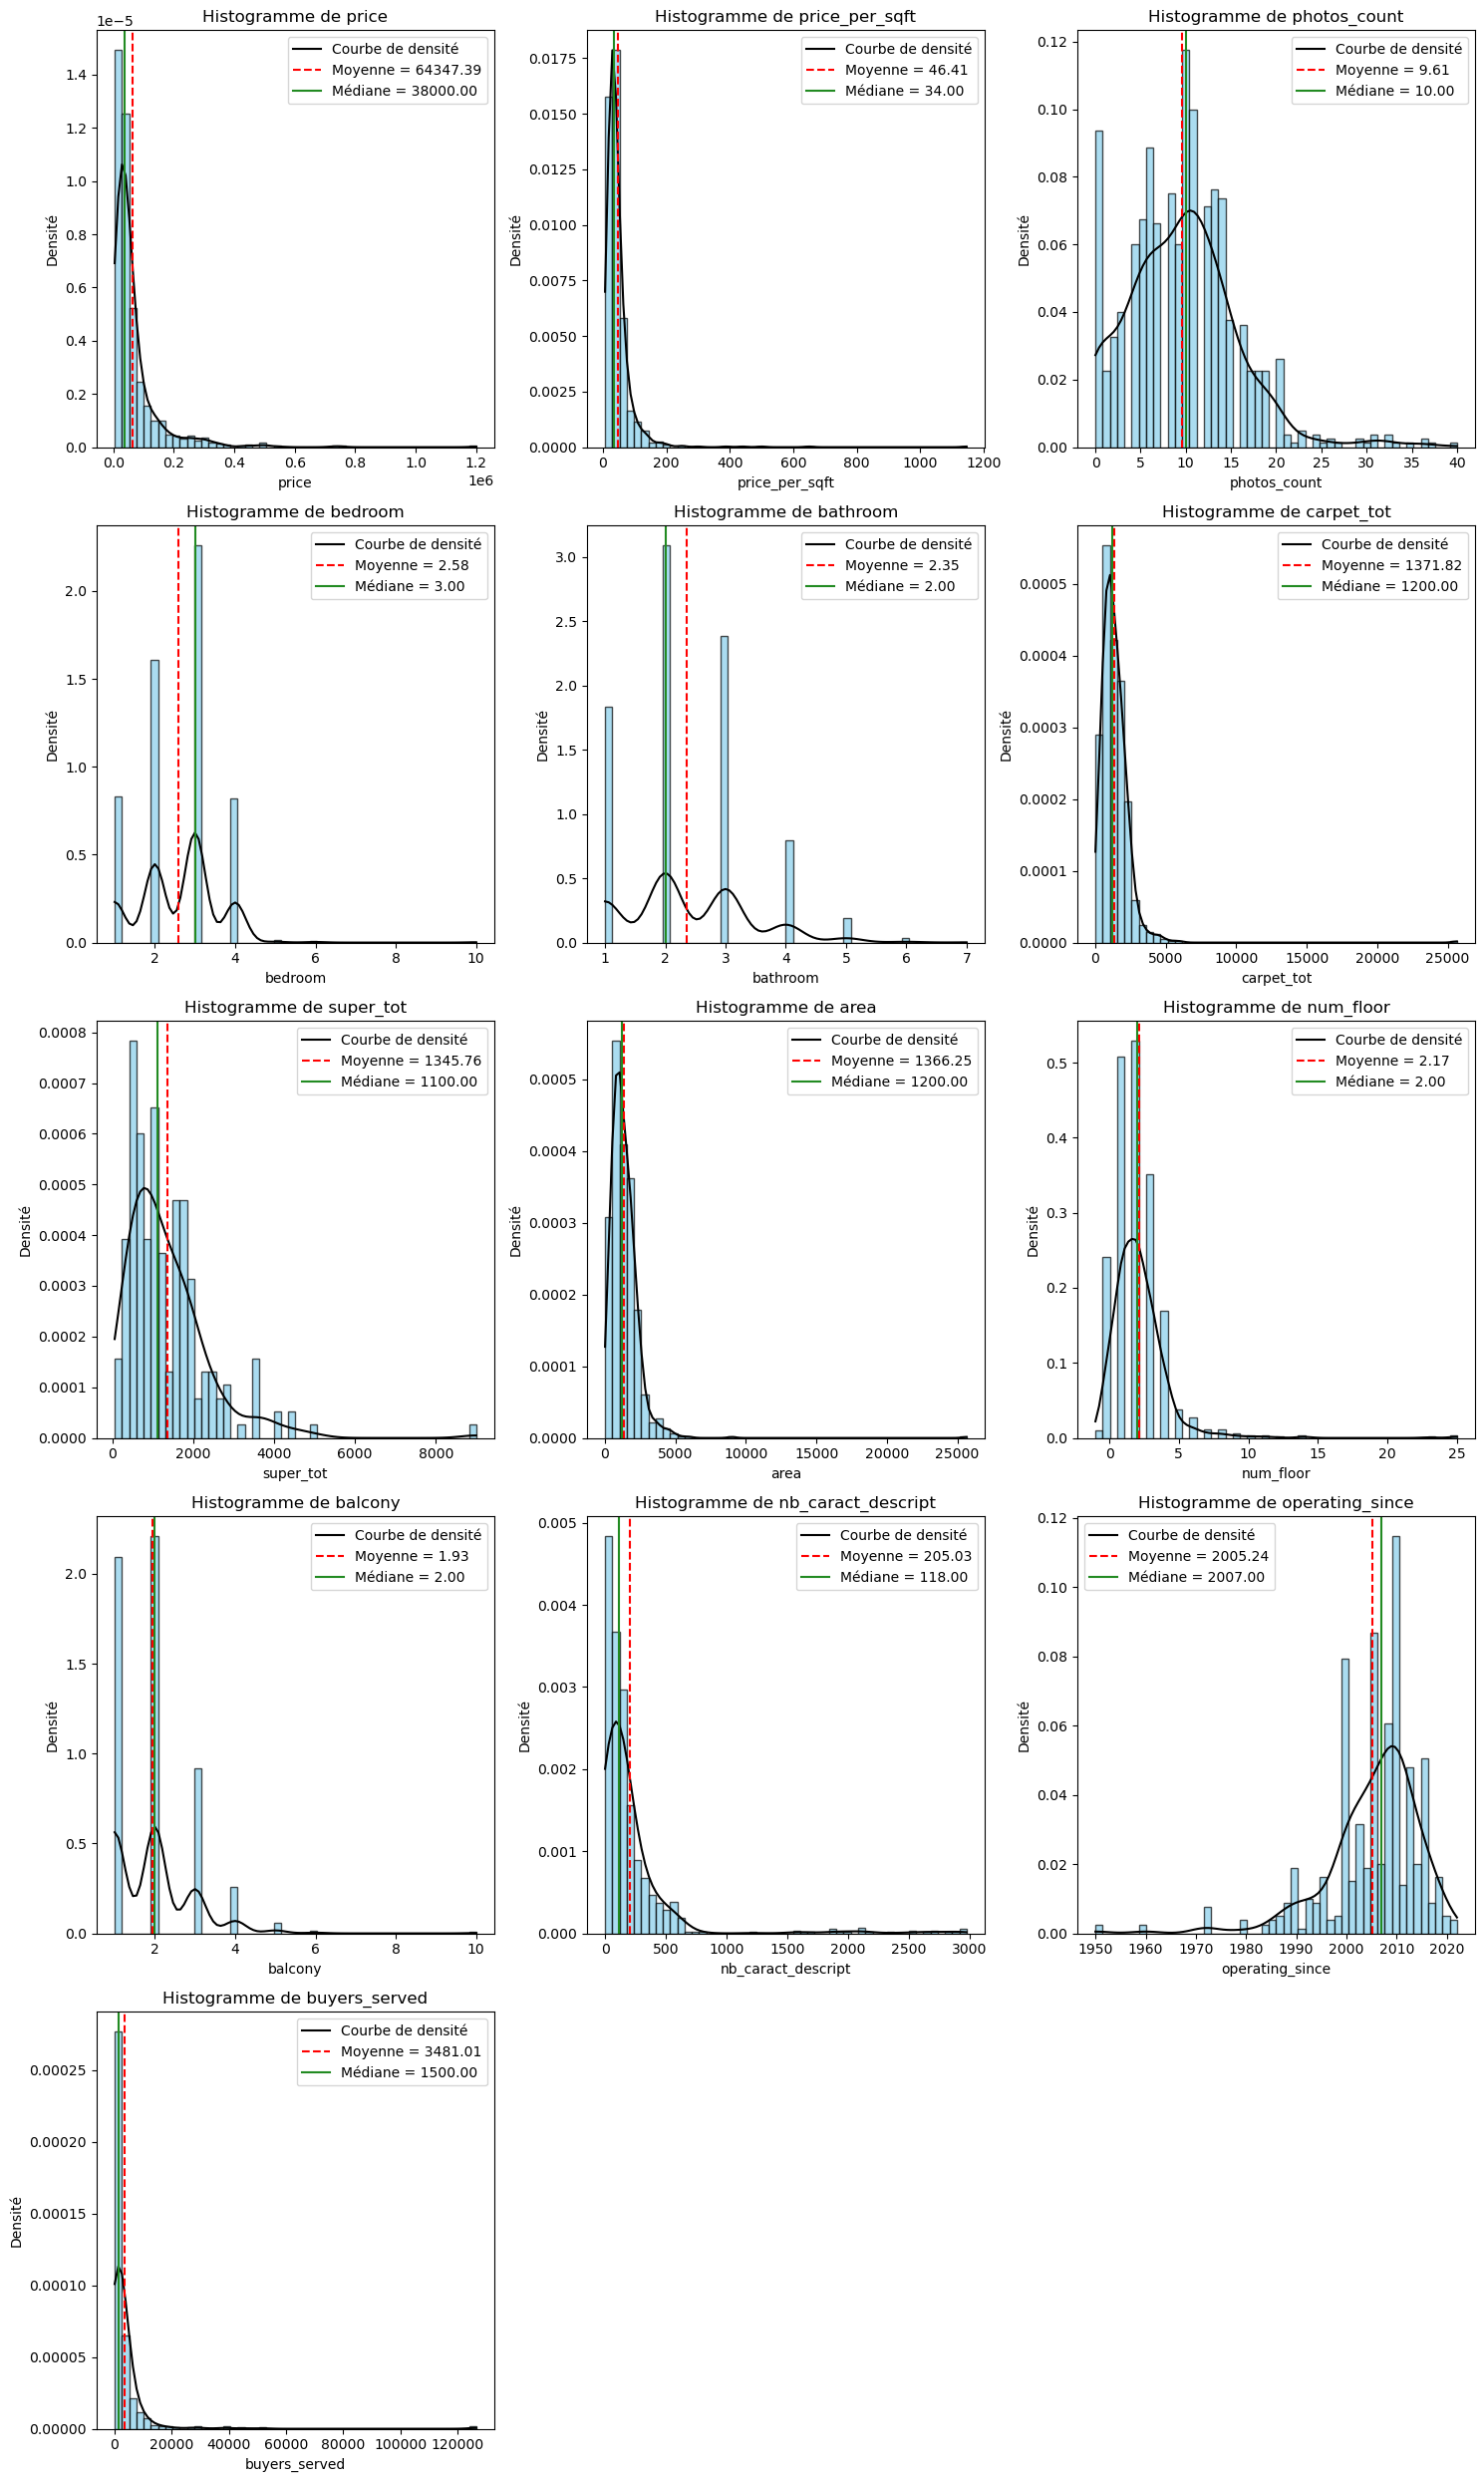

In [91]:
from scipy.stats import gaussian_kde

def plot_histograms(df):
    # Sélection des colonnes numériques (int et float)
    numeric_cols = df.select_dtypes(include=['int', 'float']).columns
    
    # Nombre de colonnes numériques
    n_cols = len(numeric_cols)
    
    # Paramètres pour les subplots
    rows = (n_cols // 3) + (n_cols % 3 > 0)  # Calcul des lignes (3 graphiques par ligne)
    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))  # Taille ajustée
    
    # Aplatir les axes pour un accès facile
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        # Calcul de la moyenne et de la médiane
        moyenne = df[col].mean()
        mediane = df[col].median()
        
        # Tracer l'histogramme pour chaque colonne
        axes[i].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=True)
        axes[i].set_title(f'Histogramme de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Densité')

        # Ajouter la courbe de densité
        kde = gaussian_kde(df[col].dropna(), bw_method='silverman')
        x_vals = np.linspace(df[col].min(), df[col].max(), 100)
        density = kde(x_vals)
        axes[i].plot(x_vals, density, color='black', label='Courbe de densité')

        # Ajouter la moyenne et la médiane
        axes[i].axvline(moyenne, color='red', linestyle='--', label=f'Moyenne = {moyenne:.2f}')
        axes[i].axvline(mediane, color='forestgreen', linestyle='-', label=f'Médiane = {mediane:.2f}')
        axes[i].legend()
    
    # Supprimer les sous-graphiques inutilisés
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Appel de la fonction
plot_histograms(df)

Il existe plusieurs algorithmes pour déterminer la fenêtre de lissage ($h$) optimale, les méthodes Scott et Silverman sont deux approches couramment utilisées dans l'estimation par noyau d'une distribution unimodale. Elles reposent sur des formules différentes, mais partagent l'objectif de choisir un $h$ adapté pour obtenir une estimation lisse de la densité.

Avec la méthode de Scott (Scott’s rule of thumb) la bande passante $h$ est donnée par :
$$h_{\text{Scott}} = \left(\frac{4}{(d+2)n}\right)^{1/(d+4)} \cdot \hat\sigma$$

où $n$ est le nombre d'échantillons, $d$ la dimension des données (dans un cas unidimensionnel, $d = 1$) et $\hat\sigma$ l'écart-type des données.

La méthode de Silverman utilise une fenêtre $h$ telle que :
$$h_{\text{Silverman}} = \left(\frac{4}{(d+2)n}\right)^{1/(d+4)} \cdot \min\left(\hat\sigma, \frac{\text{IQR}}{1.349}\right)$$
où $\text{IQR}$ est l'intervalle interquartile qui élimine l'effet des outliers et où ($n, d$) et $\hat\sigma$ sont les mêmes que pour Scott.

La méthode de Silverman est plus robuste aux outliers, car elle utilise $\text{IQR}$ (intervalle interquartile) pour limiter leur effet sur $h$. Si $\hat\sigma$ est affecté par des valeurs extrêmes, Silverman peut ajuster $h$ en se basant sur $\text{IQR}$. En revanche, la méthode de Scott, qui dépend uniquement de $\hat\sigma$, est plus sensible aux outliers.

Nous avons choisi la "Silverman’s rule of thumb" car les données sont asymétriques (cf voir Asymétrie) avec une possibilité de présence d'outliers dans le jeu de données. De plus, la méthode de Silverman offre une estimation plus précise dans des contextes où la robustesse est essentielle.

Pour en revenir aux graphiques, nous pouvons voir que l'estimation de densité sur les variables `bathroom` et `balcony` sont assez mauvaises, cela est dû au fait que ces variables sont discrètes et possèdent une étendue assez faible. En parlant d'étendue, nous allons maintenant nous pencher sur les indicateurs de dispersion.

#### Indicateur de dispertion

##### Etendue
L'indicateur de dispersion le plus simple est l'étendue. Pour rappel, elle fournit une indication rapide de l'amplitude totale des données en soustrayant la valeur minimale à celle maximale.

$$ Etendue = valeur.max - valeur.min$$

L'étendue est une mesure qui ne peut être raisonnablement envisagée que pour des séries dont les observations sont réparties de façon homogène car c'est un indicateur qui très sensible aux valeurs extrêmes.

Voici un script qui va nous permettre d'obtenir l'étendue de toutes les variables quantitatives :

In [94]:
def calculate_range(df):
    # Sélectionner les variables quantitatives
    columns = df.select_dtypes(include=['number']).columns

    # Calcul l'étendue et le range dans un dictionnaire
    range_dict = {}
    for col in columns:
        col_range = df[col].max() - df[col].min()
        range_dict[col] = col_range
    
    return range_dict

# Calcul de l'étendue pour toutes les colonnes numériques
ranges = calculate_range(df)
print("Étendues des colonnes :", ranges)

Étendues des colonnes : {'price': 1196000, 'price_per_sqft': 1139, 'photos_count': 40.0, 'bedroom': 9.0, 'bathroom': 6.0, 'carpet_tot': 25640.0, 'super_tot': 8950.0, 'area': 25640, 'num_floor': 26.0, 'balcony': 9.0, 'nb_caract_descript': 2978, 'operating_since': 72.0, 'buyers_served': 126400.0}


Comme nous avons pu le dire plus haut, les colonnes `bathroom` et `balcony` ont des étendues très faibles contrairement à des variables comme `price` ou `buyers_served` qui ont une étendue respective de 1.196.000 et 126.400.

Un autre indicateur de dispersion très largement utilisé est la variance. 

##### Variance
La variance est un indicateur primordial en statistique, c'est l'une des mesure de dispersion les plus utilisées. Elle peut refléter dans certains cas le risque, l’homogénéité ou encore l’instabilité.

La variance représente la moyenne des écarts au carré moyen par rapport à la moyenne. Elle est toujours positive et elle donne l’écart quadratique moyen. Plus la variance est petite, plus les valeurs sont regroupées autour de la moyenne. Plus la variance est grande, plus les valeurs sont dispersées.


Pour une population entière, la formule est :  
$$
\text{Variance de la population} (\sigma^2) = \frac{\sum_{i=1}^N (x_i - \mu)^2}{N}
$$

avec $N$ la taille de la population et $\mu$ la moyenne de la population $(\mu = \frac{\sum_{i=1}^N x_i}{N}$).

La variance des variables sont :

In [97]:
def variance(df):
    # Sélectionner les variables quantitatives
    columns = df.select_dtypes(include=['number']).columns

    # Calcul la variance et la range dans un dictionnaire
    var_dict = {}
    for col in columns:
        col_var = df[col].var()
        var_dict[col] = col_var
    
    return var_dict

# Calcul de la variance pour toutes les colonnes numériques
var = variance(df)
print("Variances des variables :", var)

Variances des variables : {'price': 7470587100.780326, 'price_per_sqft': 3003.057136136131, 'photos_count': 37.07230330330333, 'bedroom': 0.9409761718346069, 'bathroom': 1.0651288571370927, 'carpet_tot': 1409092.873593621, 'super_tot': 1104914.2599271638, 'area': 1342941.881365367, 'num_floor': 4.429811709148149, 'balcony': 0.9371344513092039, 'nb_caract_descript': 137533.87519919995, 'operating_since': 90.29347632403902, 'buyers_served': 84894240.53586209}


La variance étant au carré, il est parfois plus facile d'interpréter l'écart type plutôt que la variance.

##### Ecart type (standart deviation)
L’intérêt de l’écart type est qu’il s’exprime dans la même unité de mesure que les données. Il indique la dispersion des valeurs d’un ensemble de données par rapport à leur moyenne et correspond à la racine carrée de la variance.

Pour la population :
$\sigma = \sqrt{\sigma^2} = \sqrt{\frac{\sum_{i=1}^N (x_i - \mu)^2}{N}}$ 

Par exemple, un écart type important indique que les données sont dispersées autour de la moyenne, il y a donc beaucoup de variances dans les données observées. À l'inverse, si l'écart type est proche de zéro, les données sont alors très peu dispersées par rapport à la moyenne. Un écart type ne peut pas être négatif.

Nous pouvons modifier le script ci-dessus pour obtenir l'écart type des variables.

In [99]:
def std_deviation(df):
    # Sélectionner les variables quantitatives
    columns = df.select_dtypes(include=['number']).columns

    # Calcul l'écart type et le range dans un dictionnaire
    std_dict = {}
    for col in columns:
        col_std = df[col].std()
        std_dict[col] = col_std
    
    return std_dict

# Calcul de l'écart type pour toutes les colonnes numériques
standart_dev = std_deviation(df)
print("Ecart type des variables :", standart_dev)

Ecart type des variables : {'price': 86432.5581061924, 'price_per_sqft': 54.80015635138399, 'photos_count': 6.088702924540113, 'bedroom': 0.9700392630376395, 'bathroom': 1.0320508016261083, 'carpet_tot': 1187.0521781259747, 'super_tot': 1051.1490188965424, 'area': 1158.853692821215, 'num_floor': 2.104711787667886, 'balcony': 0.9680570496149511, 'nb_caract_descript': 370.85559885108916, 'operating_since': 9.502287952069176, 'buyers_served': 9213.807059834826}


Avant d'interpréter ces résultats nous allons parler du coefficient de variation.

##### Le coefficient de variation
Il est utilisé pour comparer la dispersion des variables qui ne sont pas exprimées dans une même unité de mesure. En d’autres termes, le coefficient de variation est un indicateur de dispersion neutre car il ne dépend pas des unités choisies. Il est généralement exprimé en pourcentage.

Pour une population ce coefficient est :
$$
CV = \frac{\sigma}{\mu}
$$
Pour un échantillon ce coefficient est :
$$
CV = \frac{s}{\bar x}
$$

Il peut être intéressant d'analyser la moyenne, l'écart type et le coefficient de variation ensemble pour avoir une vision plus complète.

In [102]:
def stats_summary(df):
    """
    Affiche un tableau contenant la moyenne, l'écart type 
    et l'amplitude relative de la dispersion des valeurs
    pour toutes les colonnes numériques d'un dataframe.
    """
    # Filtrer les colonnes numériques
    numeric_cols = df.select_dtypes(include=['number'])
    
    # Calculer la moyenne, l'écart type et l'amplitude relative
    summary = pd.DataFrame({
        'Moyenne': numeric_cols.mean(),
        'Écart type': numeric_cols.std(),
        'Coefficient de variation': numeric_cols.std()/numeric_cols.mean()*100
    })
    
    return summary

# Appeler la fonction
result = stats_summary(df)

# Afficher les résultats
print(result)

                         Moyenne    Écart type  Coefficient de variation
price               64347.388000  86432.558106                134.321782
price_per_sqft         46.411000     54.800156                118.075793
photos_count            9.613000      6.088703                 63.338218
bedroom                 2.578029      0.970039                 37.627170
bathroom                2.347390      1.032051                 43.965894
carpet_tot           1371.824427   1187.052178                 86.530911
super_tot            1345.757009   1051.149019                 78.108381
area                 1366.246000   1158.853693                 84.820281
num_floor               2.168675      2.104712                 97.050599
balcony                 1.932121      0.968057                 50.103329
nb_caract_descript    205.026000    370.855599                180.882229
operating_since      2005.243194      9.502288                  0.473872
buyers_served        3481.007752   9213.807060     

Nous pouvons voir que les écarts types sont en général de même ordre de grandeur que leur moyenne. Par exemple, la moyenne du prix de location est de 64347 roupies et son écart type est de 86432 roupies.

Comme nous l'avons vu plus haut, le coefficient de variation (ou amplitude relative de la dispersion) est le quotient entre l'écart type et la moyenne. Plus ce ratio est grand, plus il y a une forte dispersion relative des données autour de leur moyenne. Nous voyons que 4 ratios sont supérieurs à 100, cela signifie qu'il y a une très grande dispersion relative des valeurs autour de leur moyenne respective. En revanche, la variable `operating_since` a un ratio extrêmement faible, les variables sont très peu dispersées relativement à la moyenne. En réalité ce ratio ne nous apporte pas beaucoup d'information dans ce cas précis car la variable en question ne devrait pas être traiter de cette façon puisqu'elle représente une année.

Pour terminer avec les indicateurs de dispersion nous pouvons parler des intervalles interquartiles et interdéciles.

##### L’intervalle interquartile et interdécile

Si la médiane est la valeur au-dessous de laquelle se trouvent la moitié des valeurs, les quantiles séparent une population en $n$ classes d’effectif égal.

$n= 4$ : les quartiles, qui contiennent 25% de la population

$n=10$ : les déciles, qui en contiennent 10%

$n=100$ : les centiles, qui en contiennent 1%

Il existe 3 quartiles, notés Q1 (premier quartile), Q2 et Q3.


Avec ces 3 quartiles, nous pouvons calculer l’écart interquartile : 

$$IQ = Q3 - Q1$$

De même, avec $n$ classes d'effectif égal nous pouvons créer un intervalle interquantile qui serait la différence entre la dernière classe et la première classe : $II = Q_N - Q_1$

Nous pouvons créer une fonction qui calcul l'écart interquartile :

In [105]:
def calculate_iqr(df):
    """
    Calcule l'écart interquartile (IQR) pour les colonnes numériques d'un DataFrame.
    """
    # Filtrer les colonnes numériques
    numeric_cols = df.select_dtypes(include=['int', 'float']).columns
    
    # Calculer les IQR pour chaque colonne numérique
    iqr_values = []
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)  # Premier quartile
        q3 = df[col].quantile(0.75)  # Troisième quartile
        iqr = q3 - q1
        iqr_values.append({'Colonne': col, 'IQR': iqr})
    
    # Créer un DataFrame avec les résultats
    result_df = pd.DataFrame(iqr_values)
    return result_df

iqr_result = calculate_iqr(df)
print(iqr_result)

               Colonne       IQR
0                price  48775.00
1       price_per_sqft     25.00
2         photos_count      8.00
3              bedroom      1.00
4             bathroom      1.00
5           carpet_tot    998.25
6            super_tot   1200.00
7                 area   1008.75
8            num_floor      2.00
9              balcony      1.00
10  nb_caract_descript    168.25
11     operating_since     10.00
12       buyers_served   2500.00


Il existe un type de graphique particulier qui permet de mettre en évidence les différents quartiles ainsi que l'écart interquartiles. Ces graphiques sont les boîtes à moustache ou "box plot". La box plot met en évidence la dispersion, la symétrie mais également la présence d'éventuelles valeurs aberrantes dans un jeu de données.


La Box Plot a été inventé par John Wilder Tukey (1915 - 2000), l'un des plus grands statisticiens américains du XXe siècle. Il est notamment connu pour avoir distingué l'analyse de données exploratoires (Exploratory data analysis) et l'analyse liée aux tests d'hypothèses (confirmatory data analysis). Il publia son livre Exploratory Data Analysis en 1977 où il traite des méthodes d'analyse descriptive mais aussi des représentations graphiques des données. Il y présente entre-autres le principe de la boîte à moustaches (ou diagramme de quartiles) mais aussi les diagrammes branche-et-feuille (stem-and-leaf), une variante des histogrammes.

##### La Box-Plot

Une boîte à moustache se compose d'une boîte où les limites représentent le 1er quartile ($Q1$) et le 3e quartile ($Q3$). La ligne à l'intérieur de la boîte représente la médiane. Enfin, les "moustaches" représentent la fin calculée de la distribution (les valeurs pivots) grâce à la formule $Q1−1.5×IQR$ et $Q3+1.5×IQR$, où $IQR=Q3−Q1$ est l'écart interquartile. Ces valeurs pivots ne sont généralement pas des valeurs observées mais simplement des valeurs calculées. Les points isolés, qui sont en dehors des moustaches, peuvent être des valeurs aberrantes, mais ce n'est pas toujours le cas. En revanche, les valeurs extrêmes se situent toujours en dehors des moustaches.

![images](https://www.simplypsychology.org/wp-content/uploads/boxplot-outliers.png)
Source: https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51

De façon générale, la boîte et les moustaches seront d'autant plus étendues que la dispersion de la série statistique est grande.

Les box plot peuvent être utiliser pour comparer la distribution sur des variables quantitatives ou qualitatives et résumer graphiquement la dispersion et la symétrie des données.

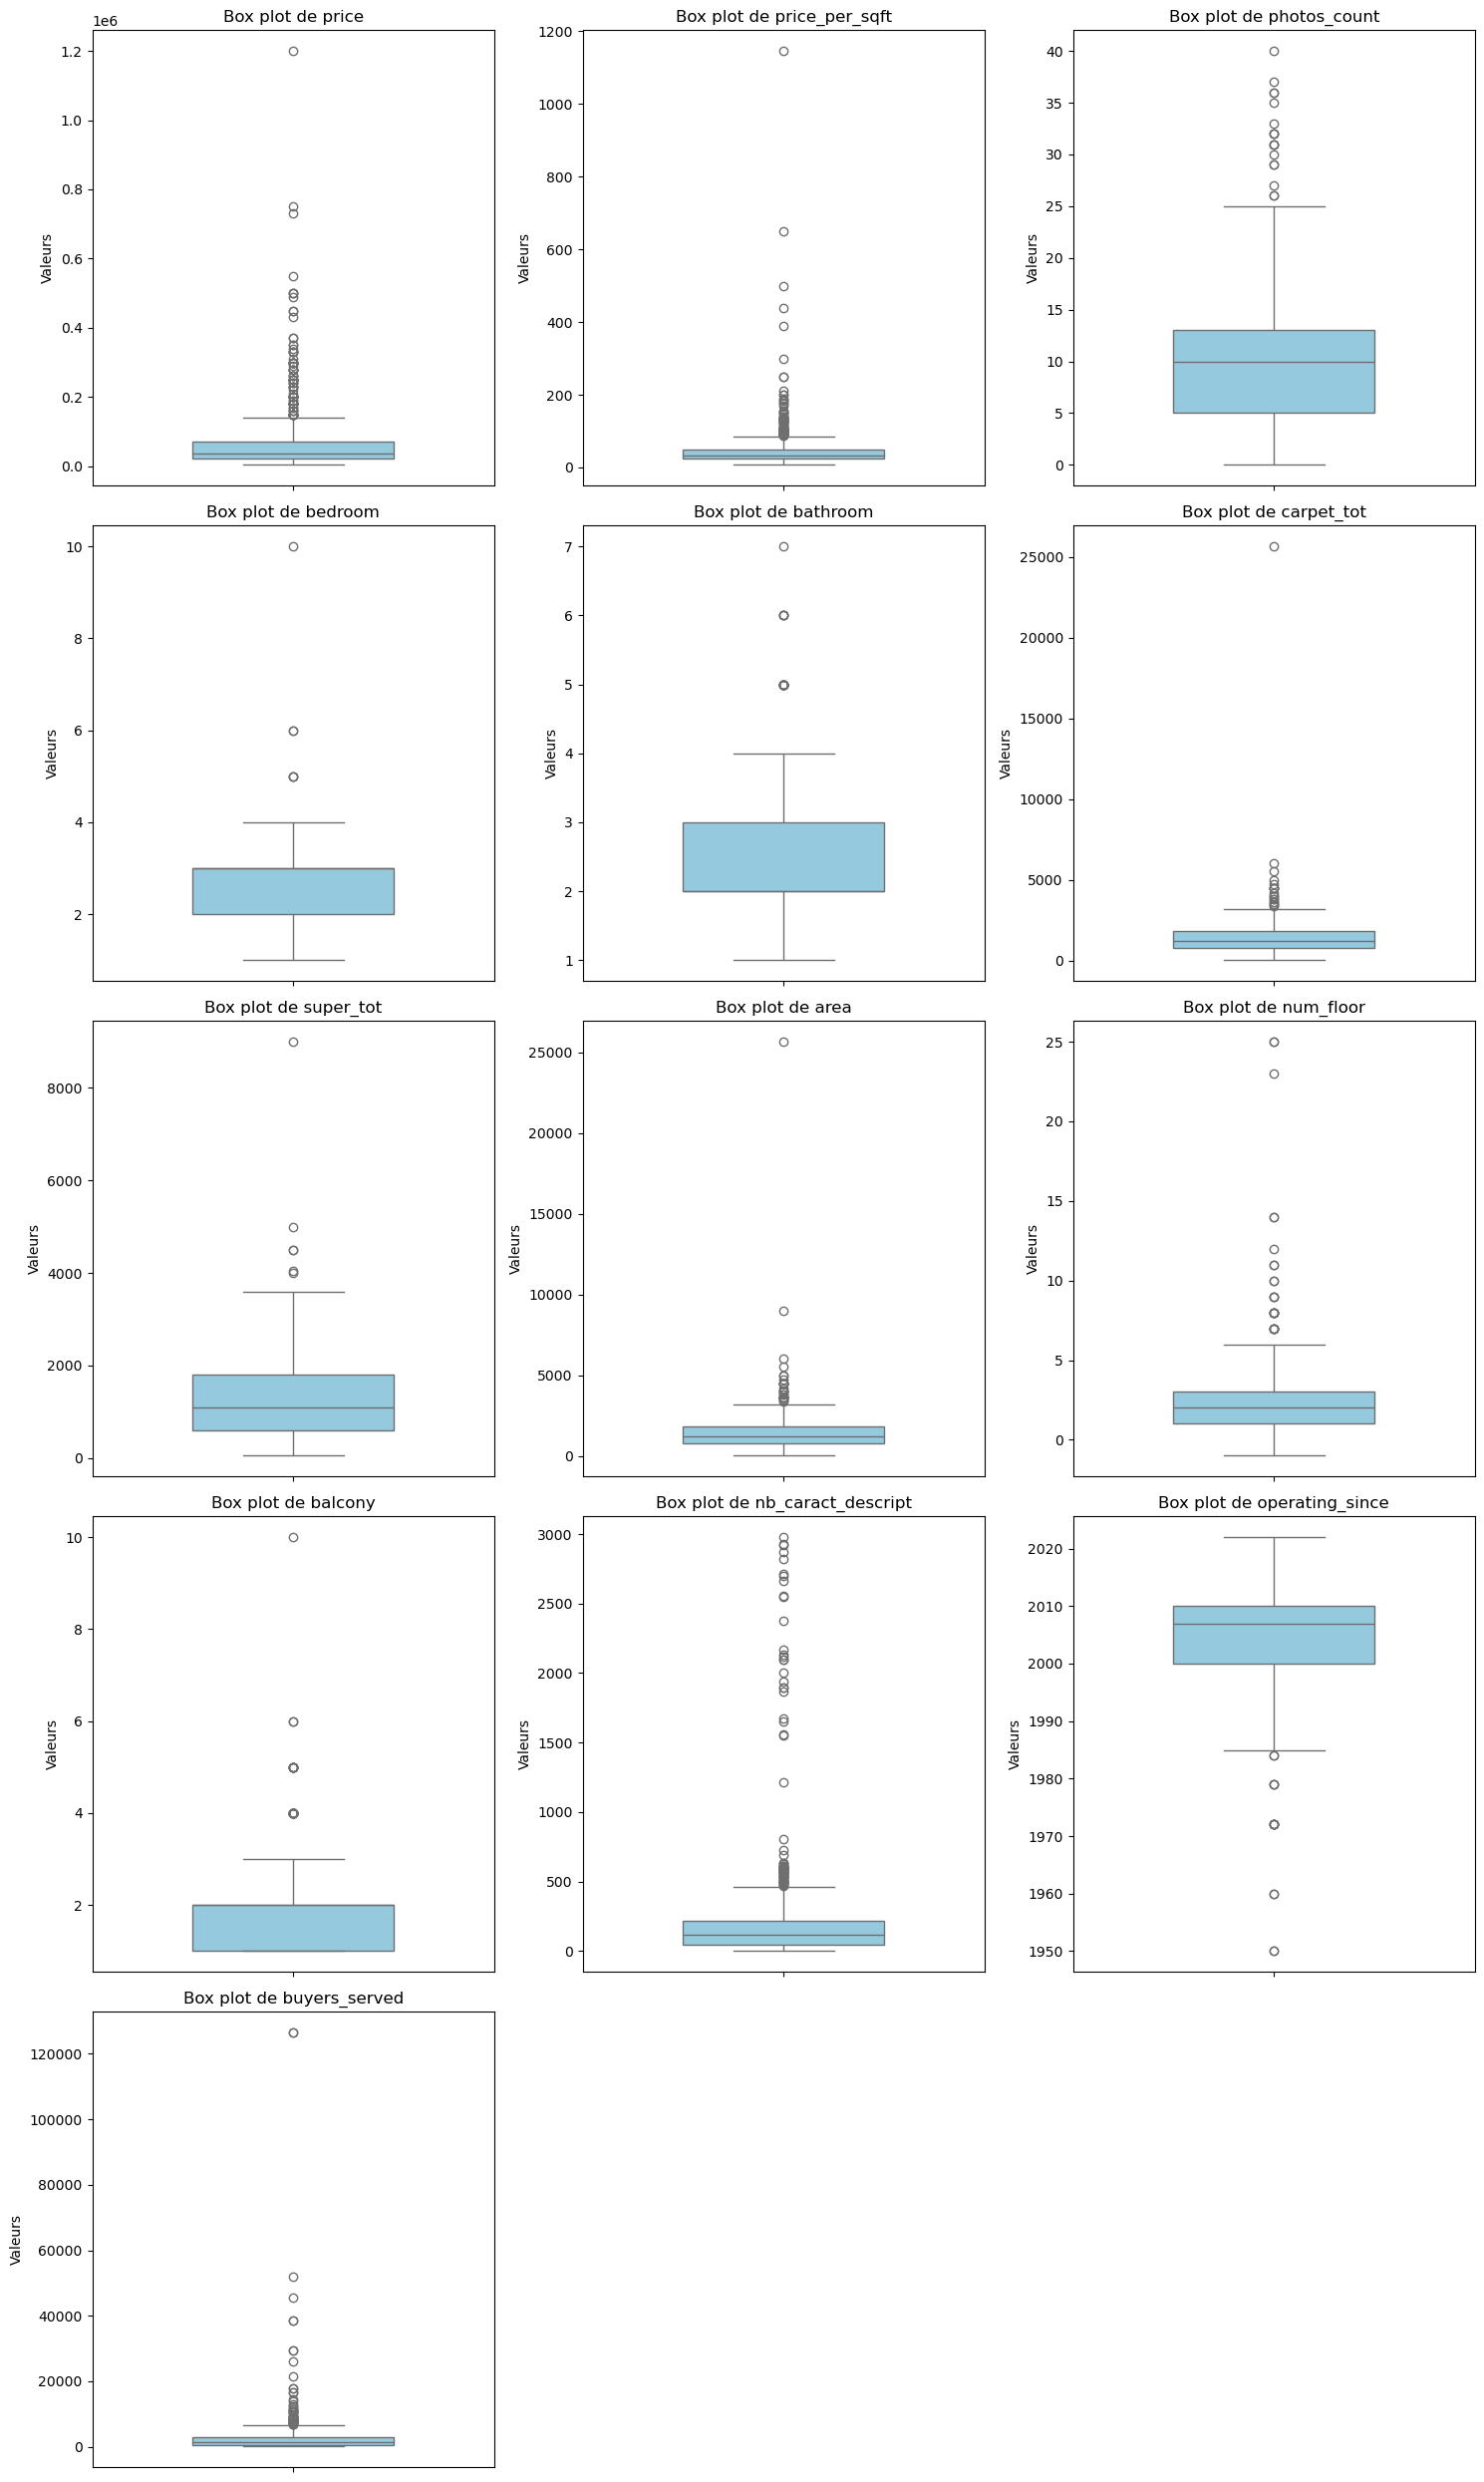

In [109]:
# Importation de la librairie
import seaborn as sns


# Fonction pour tracer les box plots avec axes indépendants
def plot_boxplots_with_seaborn(df):
    # Sélection des colonnes numériques
    numeric_cols = df.select_dtypes(include=['int', 'float']).columns
    
    # Nombre de colonnes numériques
    n_cols = len(numeric_cols)
    
    # Paramètres des subplots
    rows = (n_cols // 3) + (n_cols % 3 > 0)  # Maximum 3 plots par ligne
    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Aplatir les axes pour un accès facile
    
    # Création des box plots pour chaque colonne
    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i], color='skyblue', width=0.5, linewidth=1)
        axes[i].set_title(f'Box plot de {col}', fontsize=12)
        axes[i].set_ylabel('Valeurs', fontsize=10)
        axes[i].set_xlabel('')  # Pas de label pour l'axe des x
    
    # Supprimer les axes inutilisés si le nombre de colonnes n'est pas un multiple de 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Affichage
    plt.tight_layout()
    plt.show()

# Appel de la fonction
plot_boxplots_with_seaborn(df)

Les boxplots nous montrent ici que les différentes variables ont toutes des valeurs aberrantes avec la méthode de l'IQR.

Nous avons pu expliquer et décrire les principaux indicateurs de tendances centrales et de dispersion qu'il existe. La librairie Pandas de Python a créé une méthode qui résumait en un seul tableau les principaux indicateurs tout en excluant les valeurs manquantes.

Cette méthode est `.describ()`.

In [112]:
# Info général
df.describe()

,price,price_per_sqft,photos_count,bedroom,bathroom,carpet_tot,super_tot,area,num_floor,balcony,nb_caract_descript,operating_since,buyers_served
count,1.000000e+03,1000.000000,1000.000000,974.000000,996.000000,786.000000,214.000000,1000.000000,996.000000,825.000000,1000.000000,551.000000,516.000000
mean,6.434739e+04,46.411000,9.613000,2.578029,2.347390,1371.824427,1345.757009,1366.246000,2.168675,1.932121,205.026000,2005.243194,3481.007752
std,8.643256e+04,54.800156,6.088703,0.970039,1.032051,1187.052178,1051.149019,1158.853693,2.104712,0.968057,370.855599,9.502288,9213.807060
min,4.000000e+03,7.000000,0.000000,1.000000,1.000000,10.000000,50.000000,10.000000,-1.000000,1.000000,0.000000,1950.000000,100.000000
25%,2.122500e+04,25.000000,5.000000,2.000000,2.000000,801.750000,600.000000,791.250000,1.000000,1.000000,48.750000,2000.000000,500.000000
50%,3.800000e+04,34.000000,10.000000,3.000000,2.000000,1200.000000,1100.000000,1200.000000,2.000000,2.000000,118.000000,2007.000000,1500.000000
75%,7.000000e+04,50.000000,13.000000,3.000000,3.000000,1800.000000,1800.000000,1800.000000,3.000000,2.000000,217.000000,2010.000000,3000.000000
max,1.200000e+06,1146.000000,40.000000,10.000000,7.000000,25650.000000,9000.000000,25650.000000,25.000000,10.000000,2978.000000,2022.000000,126500.000000


Grâce à ce tableau, nous pouvons voir qu'en moyenne les biens en location ont une superficie de 1366 square feet (sqrft), alors que la médiane est de 1200 sqrft. Cela signifie que des biens très spacieux tirent la moyenne vers le haut. De plus, le bien avec la plus faible superficie est de 10 sqrft alors que le plus grand est de 25650 sqrft.

Les valeurs de la ligne `count` nous indique le nombre de valeurs non-nul de la colonne. Par exemple, la colonne `area` possède 1000 valeurs non-nulles, il n'y a donc aucune valeur manquante dans cette colonne.

Après avoir aborder les grands points de Tendance Centrale et de Dispersion, nous allons aborder les indicateurs de forme.

#### Les indicateurs de Forme

Les indicateurs de forme sont des outils statistiques utilisés pour décrire la forme d’une distribution de données. Ils permettent de caractériser comment les données sont réparties autour de leur moyenne.

##### Le coefficient d'asymétrie (Skewness)

Il existe plusieurs formules pour définir le coefficient d'asymétrie d'une distribution. Le plus utilisé étant le coefficient d'asymétrie de Fisher qui utilise le moment d'ordre 3 (les moments d'ordre 1 et 2 étant respectivement la moyenne et la variance).

Le skewness empirique $\gamma_1$ de Fisher est :
$$\gamma_1 = \frac{\mu_3}{\sigma_3} \qquad avec \qquad \mu_3 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^3$$

L'asymétrie d'une distribution traduit la régularité (ou non) avec laquelle les observations se répartissent autour de la valeur centrale. On interprète cette mesure de cette manière :

> Si $\gamma_1 = 0$ alors la distribution est symétrique (mode = médiane = moyenne)

> Si $\gamma_1 > 0$ alors la distribution est étalée à droite (mode < médiane < moyenne)

> Si $\gamma_1 < 0$ alors la distribution est étalée à gauche (mode > médiane > moyenne)

Nous voyons que le signe de $\mu_3$ permet d'objectiver l'existence d'une asymétrie de la distribution observons. Cependant, l'interprétation  de la valeur de $\mu_3$ en elle même peut être difficile car elle dépend de l'unité choisit pour exprimer les différentes observations. La solution pour parer ce problème a été de proposer un coefficient d'asymétrie qui partage le même signe que $\mu_3$ tout en étant sans unité (sans dimension) pour que ce coefficent reste inchangée quelle que soit l'unité choisie pour exprimer les observations de la distribution. C'est le coefficent qu'a introduit Fischer en faisant le rapport entre $\mu_3$ et son écart type au cube.

##### Le coefficient d'aplatissement (le Kurtosis)

L'aplatissement est une mesure de la forme de la distribution qui est évaluée par rapport à la distribution gaussienne. C'est un indicateur qui permet de préciser l'allure de la courbe sans avoir à la représenter graphiquement. En effet, on dira qu'une distribution est platicurtique si une forte variation de la variable (sur l'axe des abscisses) donne lieu à une faible variation de la fréquence relative (sur l'axe des ordonnées), à l'inverse, on dira qu'une distribution est leptocurtique si une faible variation de la variable donne lieu  à une forte variation de la fréquence relative.

Le kurtosis est généralement noté $\gamma_2$ et se calcule avec le moment d'ordre 4, soit :
$$ \gamma_2 = \frac{\mu_4}{\sigma_4} - 3  \qquad avec \qquad \mu_4 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^4 $$

La manière d'interpréter le kurtosis est similaire à celle du skewness :
> Si $\gamma_2 = 0$ alors la distribution a le même aplatisssement que la distribution normale.

> Si $\gamma_2 > 0$ alors la distribution est moins aplatie que la distribution normale, les observations sont donc plus concentrées.

> Si $\gamma_2 < 0$ alors la distribution est moins aplatie, les observations sont alors moins concentrées.

Lorsque l'on a un jeu de données, il est indispensable de résumer les séries d'observations par des indicateurs typiques comme la moyenne par exemple. Cependant, il est toujours insuffisant de résumer ces données par un unique indicateur. Il est donc important d'utiliser plusieurs indicateurs dont des mesures de tendances centrales mais également de dispersion et de forme.

In [118]:
# Importation des fonctions
from scipy.stats import skew
from scipy.stats import kurtosis

def summary_statistics(df):
    """
    Crée un tableau résumant les indicateurs de tendances centrales, dispersion et forme
    pour les colonnes numériques d'un DataFrame.

    Paramètres :
        df (pd.DataFrame) : Le DataFrame d'entrée.
        
    Retourne :
        pd.DataFrame : Un tableau récapitulatif des indicateurs pour les colonnes numériques.
    """
    
    # Filtrer les colonnes numériques
    numeric_cols = df.select_dtypes(include=['int', 'float'])
    
    # Créer un dictionnaire pour stocker les statistiques
    summary = {
        "Effectif": numeric_cols.count(),
        "Moyenne": numeric_cols.mean(),
        "Écart type": numeric_cols.std(),
        "Minimum": numeric_cols.min(),
        "1er quartile": numeric_cols.quantile(0.25),
        "Médiane": numeric_cols.median(),
        "3ème quartile": numeric_cols.quantile(0.75),
        "Maximum": numeric_cols.max(),
        "Intervalle interquartile (IQR)": numeric_cols.quantile(0.75) - numeric_cols.quantile(0.25),
        "Étendue": numeric_cols.max() - numeric_cols.min(),
        "Asymétrie": numeric_cols.apply(lambda x: skew(x, nan_policy='omit')),
        "Aplatissement": numeric_cols.apply(lambda x: kurtosis(x, nan_policy='omit', fisher=True)),
        "Coeff. de variation": numeric_cols.std() / numeric_cols.mean(),
    }
    
    # Convertir le dictionnaire en DataFrame
    summary_df = pd.DataFrame(summary)
    
    # Transposer pour avoir les colonnes en index
    return summary_df.T


result = summary_statistics(df)
print(result)

                                       price  price_per_sqft  photos_count  \
Effectif                        1.000000e+03     1000.000000   1000.000000   
Moyenne                         6.434739e+04       46.411000      9.613000   
Écart type                      8.643256e+04       54.800156      6.088703   
Minimum                         4.000000e+03        7.000000      0.000000   
1er quartile                    2.122500e+04       25.000000      5.000000   
Médiane                         3.800000e+04       34.000000     10.000000   
3ème quartile                   7.000000e+04       50.000000     13.000000   
Maximum                         1.200000e+06     1146.000000     40.000000   
Intervalle interquartile (IQR)  4.877500e+04       25.000000      8.000000   
Étendue                         1.196000e+06     1139.000000     40.000000   
Asymétrie                       4.963214e+00       11.088035      0.899811   
Aplatissement                   4.128683e+01      184.567557    

En analysant ces résultats nous pouvons dire par exemple que le prix moyen est environ de 64 347 roupies, que la médiane est de 38 000, ce qui est plus représentatif en raison d'une asymétrie. La variable a un écart-type élevé de 86 432, suggérant une forte variabilité des prix. Le minimum et le maximum sont de 4 000 et 1 200 000, ce qui indique la présence de valeurs extrêmes. Il y a une asymétrie de 4.96 et un aplatissement très élevé (41.28), confirmant que la distribution est fortement biaisée à droite avec de rares annonces très chères. 

Concernant le nombre de chambres et de salles de bains, la moyenne est respectivement de 2,58 et de 2,35, avec la majorité des annonces ayant entre 2 et 3 de ces pièces. Les variables montrent une distribution légèrement asymétrique vers les valeurs plus élevées, mais reste proche d’une distribution normale. La majorité des annonces concernent donc des logements standards (2-3 chambres et salles de bains).  

La superficie des logements nous indique qu'en moyenne un logement fait 1366 pieds carrés (square feet) avec un écart-type de 1 159. Il y a une forte asymétrie (9.96) et un aplatissement élevé (193.7) indiquant que certains biens sont extrêmement grands (max 25 650 pieds carrés).  

Enfin, pour parler du nombre de balcons, les logements en possèdent en moyenne 1.93, avec une majorité des annonces ayant 1 ou 2 balcons. Cependant, un logement a 10 balcons, ce qui semble inhabituel.

### Variables qualitatives

L’outil privilégié pour décrire une variable qualitative est le diagramme en bâtons. Il s’agit
d’énumérer les valeurs (les modalités) prises par la variable, et pour chaque modalité fournir
l’effectif correspondant, et éventuellement la proportion (effectif par modalité / effectif total) associée.

In [121]:
def detect_qualitative(df, threshold=df.shape[0]*0.005, max_unique_values=df.shape[0]*0.05):
    """
    Détecte les colonnes qualitatives dans un DataFrame Pandas.

    Arguments :
        - df : DataFrame Pandas à analyser.
        - threshold : Nombre maximum de valeurs uniques pour considérer une colonne numérique comme qualitative.
        - max_unique_values : Nombre maximum de valeurs uniques pour une colonne 'object' ou 'category' soit considérée comme qualitative.
    
    Retourne :
        - Liste des colonnes qualitatives.
    """
    
    qualitative_cols = []
    for col in df.columns:
        if (df[col].dtype == 'object' or df[col].dtype.name == 'category'):
            if df[col].nunique() <= max_unique_values:  # Vérifie le nombre de valeurs uniques
                qualitative_cols.append(col)
        elif df[col].nunique() <= threshold:  # Vérifie les colonnes numériques avec un seuil
            qualitative_cols.append(col)
    return qualitative_cols

# Exemple d'utilisation
qualitative_cols = detect_qualitative(df)
print("Colonnes qualitatives :", qualitative_cols)


Colonnes qualitatives : ['furnishing', 'tenant_preferred', 'availability', 'facing', 'overlooking', 'ownership', 'contact']


Nous avons écrit un script pour essayer de détecter quelles étaient les variables qualitatives dans ce jeu de données. Nous avons choisi de mettre comme limite du nombre de valeurs uniques 5% du nombre de valeurs total dans le jeu de données pour les variables de type 'object' et 'category' et 0.5% pour les données de type 'numérique' dans le but de capter uniquement des variables qualitatives. En effet, une variable qui contient beaucoup de valeurs uniques a moins de chance d'être une variable qualitative.

##### Le Mode

En statistique descriptive, le mode est une mesure de tendance centrale qui correspond à la valeur ou la modalité la plus fréquente dans un ensemble de données. En d'autres termes, c'est la valeur qui apparaît le plus souvent.  

Le mode est applicable à différents types de données dont les données qualitatives (catégorielles), le mode représente alors la catégorie la plus fréquente. Le mode est également applicable aux données quantitatives et représente la valeur numérique la plus fréquente.  

Un ensemble de données peut être :  
- Unimodal s’il n’y a qu'un seul mode (une valeur majoritaire).  
- Bimodal si deux valeurs apparaissent avec la même fréquence maximale.  
- Multimodal s'il y a alors plusieurs modes au sein du jeu de données. 
- Sans mode il n'y a alors aucune valeur qui apparaît plus souvent que les autres.

Le mode se caractérise par sa simplicité. En effet, le mode est facile à identifier dans un ensemble de données ou dans un histogramme. Cependant il est peu représentatif si les données sont dispersées et il est sensible aux variations dans la fréquence. De plus, le mode est moins utile dans des distributions continues ou symétriques où l’on utilisera plutôt une classe modale.  

In [124]:
# Fonction qui calcul le mode des colonnes d'un dataframe
def calculate_mode(df, columns=None):
    """
    Calcule le mode des colonnes spécifiées d'un DataFrame.

    Paramètres :
        df (pd.DataFrame) : Le DataFrame d'entrée.
        columns (list) : Liste des colonnes pour lesquelles calculer le mode. 
                         Si None, le mode est calculé pour toutes les colonnes.

    Retourne :
        pd.DataFrame : Un DataFrame contenant le mode des colonnes spécifiées.
    """
    # Si aucune colonne spécifiée, utiliser toutes les colonnes du DataFrame
    if columns is None:
        columns = df.columns

    # Vérifier si les colonnes existent dans le DataFrame
    columns = [col for col in columns if col in df.columns]

    # Calculer le mode pour chaque colonne spécifiée
    modes = {}
    for col in columns:
        mode_values = df[col].mode()
        # Vérifier si plusieurs modes existent
        if len(mode_values) > 1:
            modes[col] = list(mode_values)  # Liste si plusieurs modes
        else:
            modes[col] = mode_values[0]  # Valeur unique si un seul mode

    # Convertir en DataFrame
    result_df = pd.DataFrame(modes, index=["Mode"]).T
    return result_df


# Calculer le mode pour des colonnes spécifiques
result = calculate_mode(df, columns=['furnishing','tenant_preferred','availability','facing','overlooking','ownership','contact'])
print(result)

                                    Mode
furnishing                Semi-Furnished
tenant_preferred        Bachelors/Family
availability                 Immediately
facing                      North - East
overlooking       Garden/Park, Main Road
ownership                       Freehold
contact                           Agent 


Nous pouvons voir graphiquement la répartition des différentes valeurs dans un graphique spécifique, le "Camembert" ou pie chart en anglais.

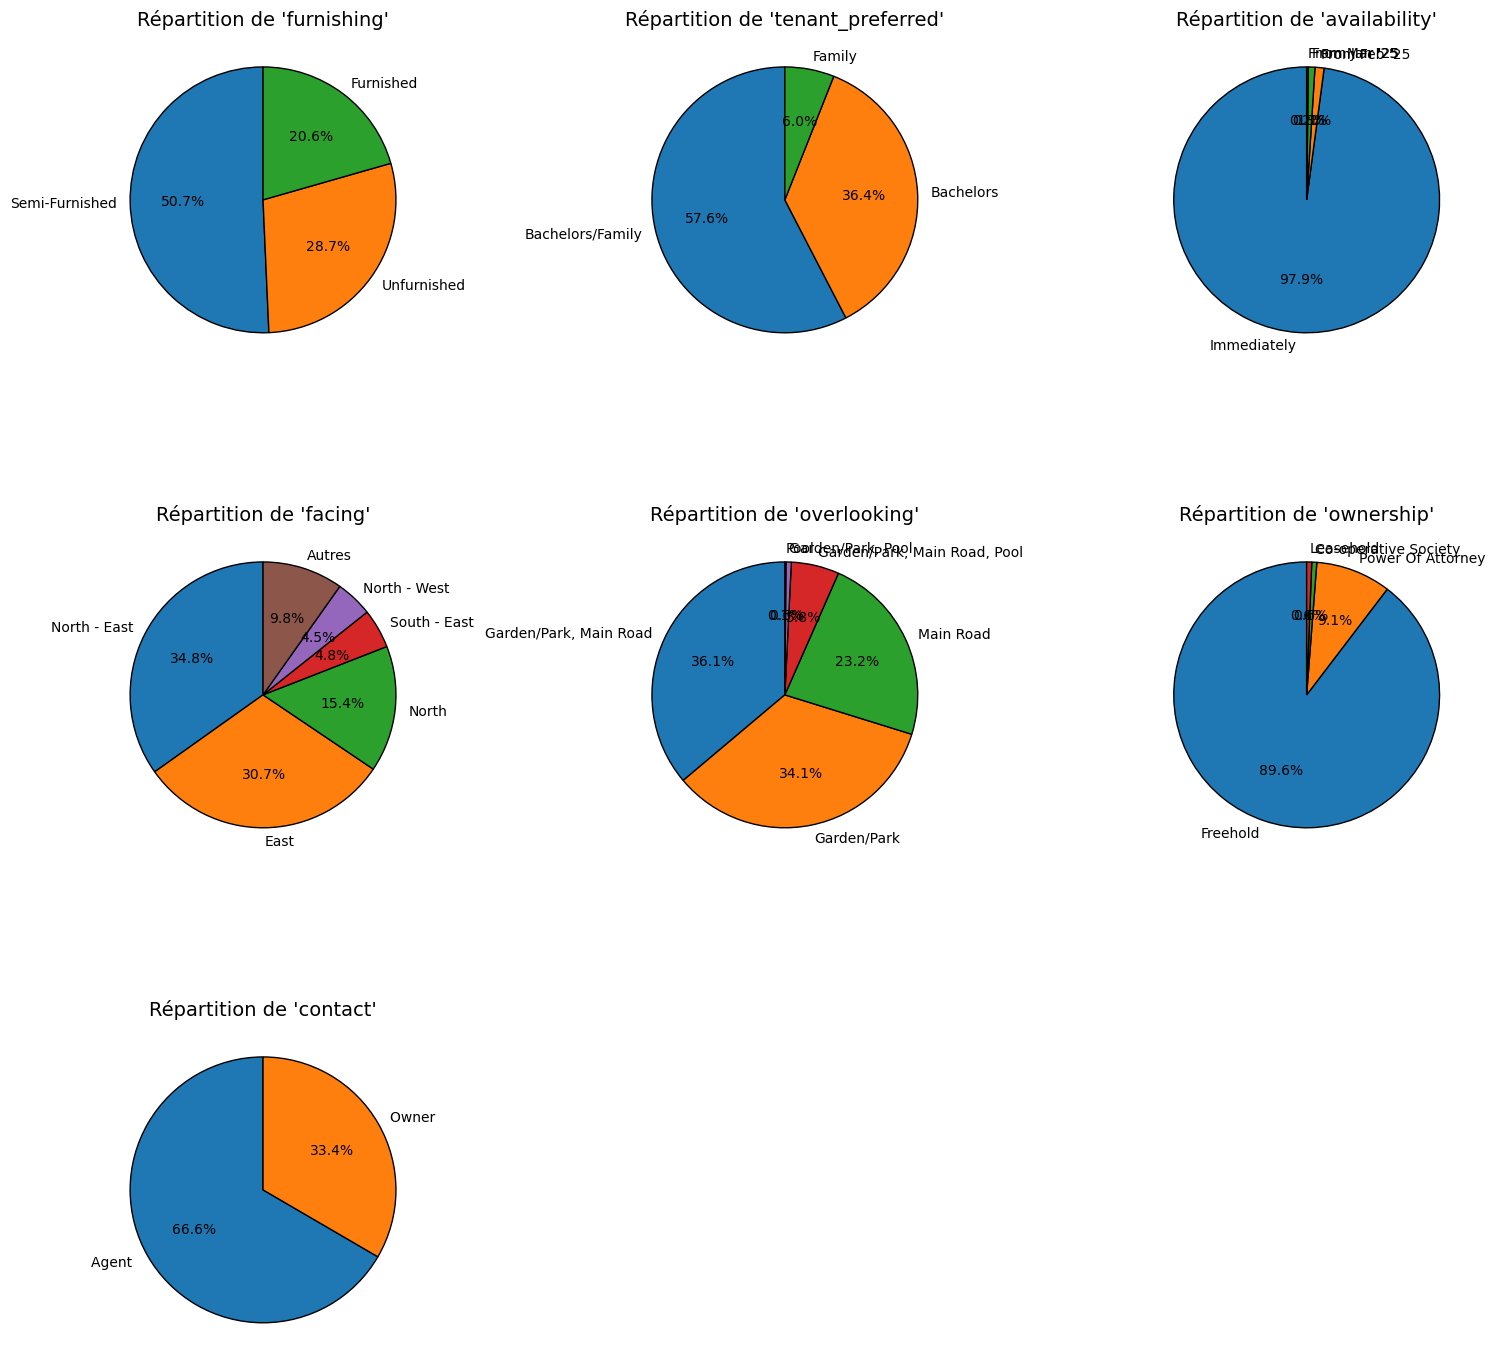

In [126]:
# Fonction qui génère des Pie Charts
def plot_pie_charts(df, columns, max_unique_values=6):
    """
    Crée des pie charts pour chaque colonne spécifiée dans un DataFrame, en ignorant les valeurs nulles.
    
    Paramètres :
        df (pd.DataFrame) : Le DataFrame contenant les données.
        columns (list) : Liste des colonnes pour lesquelles créer les pie charts.
        max_unique_values (int) : Nombre maximum de valeurs uniques avant de regrouper les plus petites en 'Autres'.
    """
    num_cols = len(columns)
    rows = (num_cols // 3) + (num_cols % 3 > 0)  # Calcul des lignes pour un maximum de 3 graphiques par ligne
    
    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Aplatir les axes pour un accès facile
    
    for i, col in enumerate(columns):
        if col not in df.columns:
            print(f"La colonne '{col}' n'existe pas dans le DataFrame.")
            continue
        
        # Calcul des fréquences, en ignorant les NaN
        value_counts = df[col].value_counts(dropna=True)
        total = value_counts.sum()
        
        # Vérifier s'il reste des données après suppression des NaN
        if total == 0:
            print(f"La colonne '{col}' ne contient aucune donnée non nulle.")
            fig.delaxes(axes[i])
            continue

        # Regrouper les petites valeurs si nécessaire
        if len(value_counts) > max_unique_values:
            others_count = value_counts[max_unique_values - 1:].sum()
            value_counts = pd.concat(
                [value_counts[:max_unique_values - 1], pd.Series(others_count, index=['Autres'])]
            )
        
        # Données pour le pie chart
        labels = value_counts.index
        sizes = value_counts.values
        percentages = [f'{(val / total) * 100:.1f}%' for val in sizes]
        
        # Création du pie chart
        axes[i].pie(
            sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 10}, wedgeprops={'edgecolor': 'black'},
        )
        axes[i].set_title(f"Répartition de '{col}'", fontsize=14)

    # Supprimer les axes inutilisés
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Appel de la fonction
plot_pie_charts(df, columns=['furnishing','tenant_preferred','availability','facing','overlooking','ownership','contact'])

Certains graphiques posent problème car certaines parts sont trop petites, elles contiennent peu de valeurs. Comme elles se retrouvent à côté, elles se chevauchent et rendent le graphique en partie illisible. C'est par exemple le cas du graphique 'Availability'.

Avec les différentes analyses précédentes nous savons que la variable `ownership` possède 836 valeurs manquantes sur 1000, et sur les 164 valeurs existantes 89,6% des valeurs sont de la catégorie `Freehold` (147 valeurs sur 164). Selon, [la suppression des valeurs manquantes](#La-suppression-des-valeurs-manquantes) que nous avons vu plus haut, il est pertinent de supprimer cette colonne.

In [128]:
# Suppresion de la colonne ownership
df = df.drop('ownership', axis=1)

L'autre type de graphique très utilisé pour visualiser les variables qualitatives sont les diagrammes en barres.

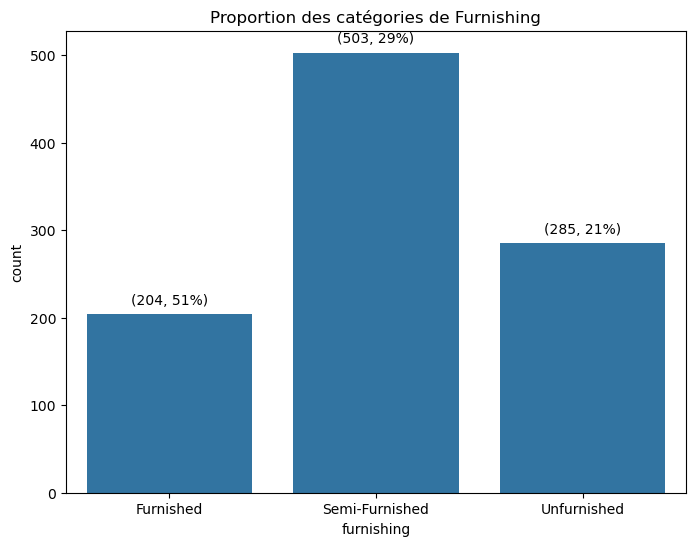

In [130]:
# Graphique en barres pour la proportion de chaque catégorie

# Calculer la proportion de chaque catégorie
prop_df = df["furnishing"].value_counts(normalize=True).reset_index()
prop_df.columns = ["furnishing", "proportion"]

# Graphique en barres pour la fréquence de chaque catégorie
plt.figure(figsize=(8,6))
ax = sns.countplot(x="furnishing", data=df)
plt.title("Proportion des catégories de Furnishing")

# Ajouter le nombre et la proportion de chaque catégorie sur les barres
for p, prop, count in zip(ax.patches, prop_df["proportion"], df["furnishing"].value_counts().sort_index()):
    ax.annotate(f'({count}, {prop:.0%})', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

# Affichage
plt.show()

Dans ce graphique, la barre la plus haute représente la catégorie avec l'effectif le plus important. Nous voyons ici que la catégorie semi-furnishing est la plus présente dans le jeu de données. Les étiquettes que nous avons ajoutés à chaque barre nous indique la fréquence et l'effectif de la catégorie par rapport au jeu de données.

Voici un script pour faire des diagrammes en barres pour les variables qualitatives :

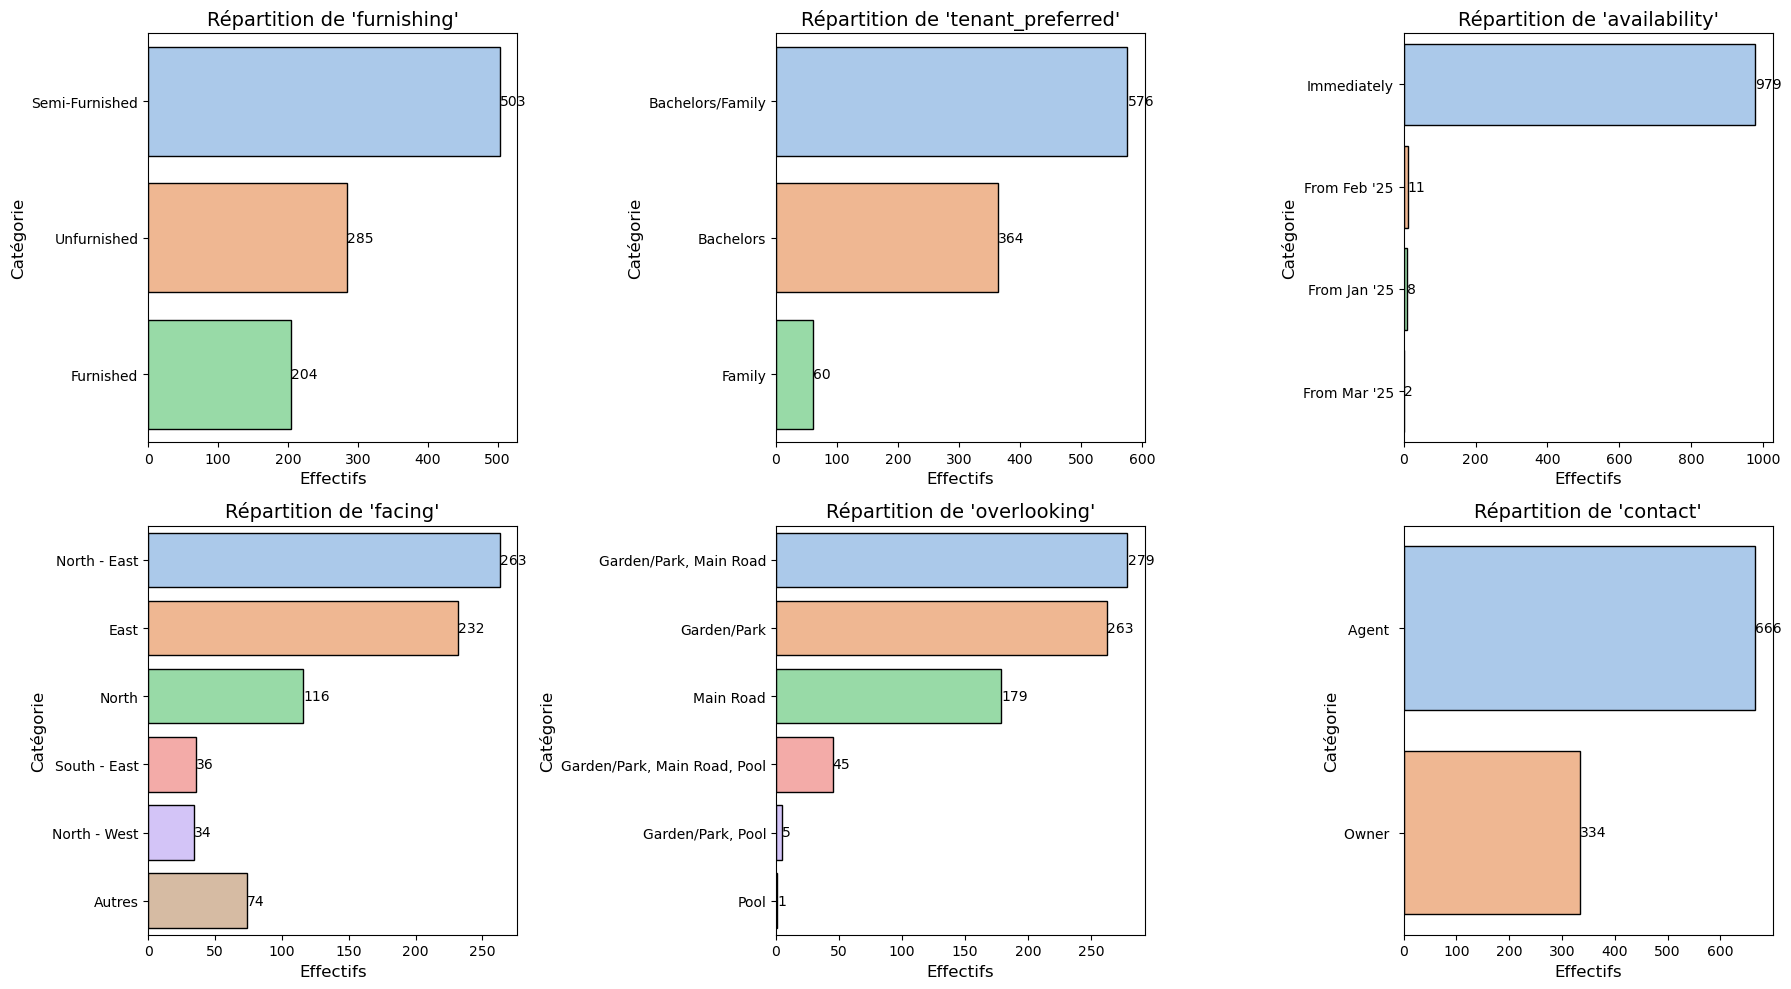

In [132]:
# Fonction qui génère des diagramme en barres
def plot_bar_charts(df, columns, max_unique_values=6):
    """
    Crée des diagrammes en barres pour chaque colonne spécifiée dans un DataFrame.
    
    Paramètres :
        df (pd.DataFrame) : Le DataFrame contenant les données.
        columns (list) : Liste des colonnes pour lesquelles créer les diagrammes en barres.
        max_unique_values (int) : Nombre maximum de valeurs uniques avant de regrouper les plus petites en 'Autres'.
    """
    num_cols = len(columns)
    rows = (num_cols // 3) + (num_cols % 3 > 0)  # Calcul des lignes pour un maximum de 3 graphiques par ligne
    
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
    axes = axes.flatten()  # Aplatir les axes pour un accès facile
    
    for i, col in enumerate(columns):
        if col not in df.columns:
            print(f"La colonne '{col}' n'existe pas dans le DataFrame.")
            fig.delaxes(axes[i])
            continue
        
        # Calcul des fréquences, en ignorant les NaN
        value_counts = df[col].value_counts(dropna=True)
        total = value_counts.sum()

        # Vérifier s'il reste des données après suppression des NaN
        if total == 0:
            print(f"La colonne '{col}' ne contient aucune donnée non nulle.")
            fig.delaxes(axes[i])
            continue
        
        # Regrouper les petites valeurs si nécessaire
        if len(value_counts) > max_unique_values:
            others_count = value_counts[max_unique_values - 1:].sum()
            value_counts = pd.concat(
                [value_counts[:max_unique_values - 1], pd.Series(others_count, index=['Autres'])]
            )
        
        # Données pour le diagramme en barres
        labels = value_counts.index
        sizes = value_counts.values
        
        # Création du diagramme en barres
        sns.barplot(
            x=sizes, y=labels, ax=axes[i], hue=labels,
            palette="pastel", orient="h", edgecolor="black"
        )
        axes[i].set_title(f"Répartition de '{col}'", fontsize=14)
       # axes[i].bar_label(axes[i].containers[0], fmt='%.0f', label_type="edge")
        axes[i].set_xlabel("Effectifs", fontsize=12)
        axes[i].set_ylabel("Catégorie", fontsize=12)
       
        # Ajout des étiquettes d'effectifs sur chaque barre
        for j, value in enumerate(sizes):
            axes[i].text(
                value + 0.1, j, str(value), 
                color='black', va='center', fontsize=10
            )
            
    # Supprimer les axes inutilisés
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Appel de la fonction
plot_bar_charts(df, columns=['furnishing','tenant_preferred','availability','facing','overlooking','contact'])

La répartition des catégories de la variable `availability` est très inégale, avec une modalité (immediately) qui est grandement prédominante. Cette variable, au vu des proportions, ne va pas pouvoir nous apporter beaucoup d'information.

Les autres modalités avec une très faible proportion sont Pool et Garden/Prk, Pool dans la variable `overlooking`. Cependant, les autres modalités étant plutôt bien réparti (sans écrasante majorité) la variable peut nous apporter de l'information utile.

De même qu'avec les variables quantitatives, la librairie Pandas nous offre un attribut qui regroupe les principaux indicateurs à prendre en compte pour avoir une idée globale des données qualitatives.

In [134]:
# Information générale
df.describe(include=[object])

,furnishing,tenant_preferred,availability,floor,facing,overlooking,contact
count,992,1000,1000,996,755,772,1000
unique,3,3,4,74,8,6,2
top,Semi-Furnished,Bachelors/Family,Immediately,2 out of 4,North - East,"Garden/Park, Main Road",Agent
freq,503,576,979,162,263,279,666


Nous allons maintenant passer à l'analyse bivariée pour un jeu de données.

## Analyse Bivariée

L’analyse bivariée est une méthode statistique permettant d’examiner simultanément deux variables afin de comprendre la relation qui les lie. Elle repose sur des mesures de dépendance, des représentations graphiques et des tests statistiques. Elle constitue une étape fondamentale dans l’exploration des données, en identifiant d’éventuelles corrélations ou associations avant d’envisager des analyses plus complexes, comme la régression multiple ou l’analyse factorielle.

Cette approche permet notamment de déterminer si l’une des variables influence l’autre, et si cette influence est positive ou négative. Le choix des outils d’analyse dépend de la nature des variables, qu’il est essentiel d’identifier au préalable. Trois cas de figure peuvent se présenter : deux variables quantitatives, une variable quantitative et une qualitative, ou deux variables qualitatives. Nous commencerons par étudier le cas des deux variables quantitatives


### Analyse de 2 variables quantitatives

#### Diagramme de dispersion

Le diagramme de dispersion est une représentation graphique permettant de visualiser la relation entre deux variables quantitatives. Chaque point du graphique correspond à une observation, avec une variable sur l’axe des abscisses et l’autre sur l’axe des ordonnées.

Outil essentiel de l’analyse bivariée, il permet d’explorer visuellement les relations potentielles entre deux variables. Il sert également à détecter d’éventuelles anomalies ou valeurs aberrantes, visibles sous forme de points isolés.

Ce type de graphique trouve son origine dans les travaux de Francis Galton (1822–1911), pionnier de la statistique, à qui l’on doit aussi les concepts de corrélation et de régression. Il utilisait déjà ce genre de représentation pour étudier, par exemple, la relation entre la taille des parents et celle de leurs enfants.

Enfin, le diagramme de dispersion donne un aperçu de l’intensité de la corrélation : plus les points sont alignés autour d’une ligne ou d’une courbe, plus la corrélation est forte. À l’inverse, une grande dispersion des points traduit une corrélation faible.

Nous pouvons créer un script qui réalise un nuage de points entre chaque pair de variables.

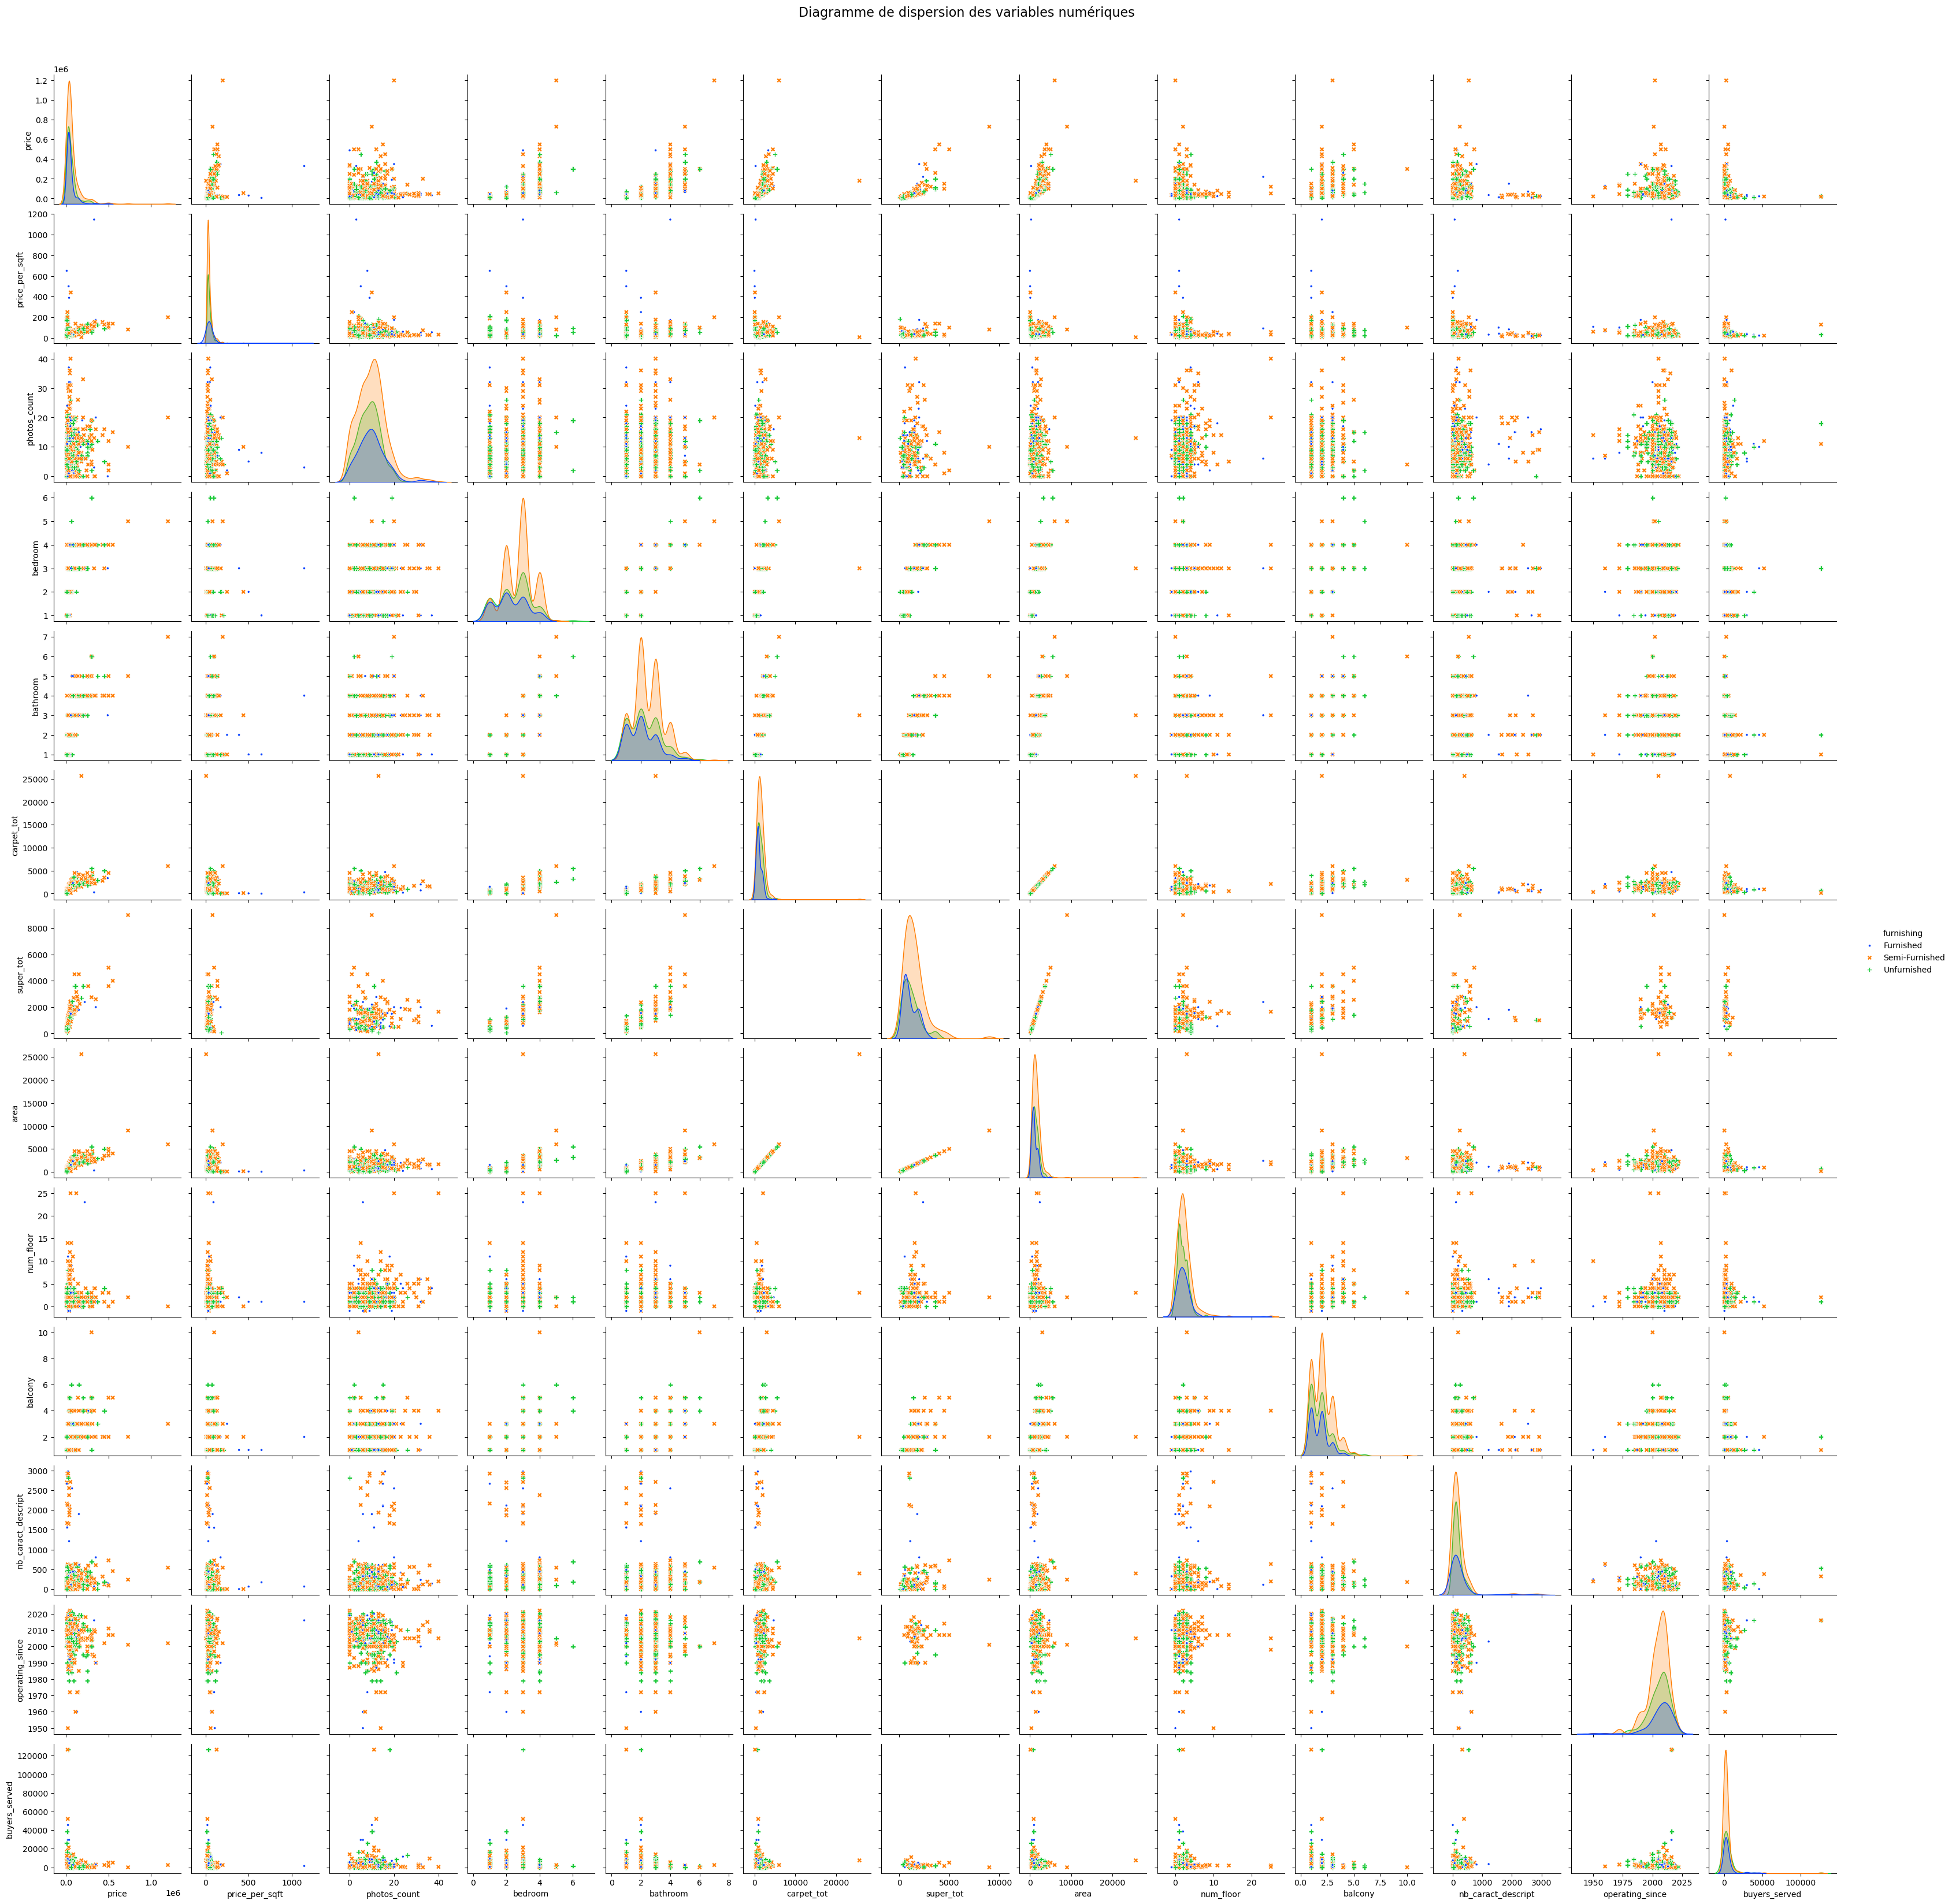

In [141]:
# Importation de Seaborn
import seaborn as sns

# Sélection des colonnes de types int et float
numeric_cols = df.select_dtypes(include=['int', 'float'])

# Ajout d'une colonne catégorielle au DataFrame numérique si elle existe
if "furnishing" in df.columns:
    numeric_cols["furnishing"] = df["furnishing"]

# Création du pairplot
pairplot = sns.pairplot(
    numeric_cols, 
    hue="furnishing",     # Utilisation de la colonne catégorielle pour colorer les points
    palette="bright",     # Palette de couleurs pour les catégories
    diag_kind="kde",      # Type de graphique pour la diagonale (estimation de densité)
    markers=[".", "X", "P"]  # Marqueurs pour différencier les catégories
)

# Ajout d'un titre général au graphique
pairplot.fig.suptitle("Diagramme de dispersion des variables numériques", 
                      y=1.02,  # Position verticale du titre
                      fontsize=16)  # Taille de la police du titre

# Affichage du graphique
plt.show()

# Fermeture de la figure pour libérer les ressources
plt.close(pairplot.fig)

Ce graphique comporte beaucoup de sub-plot, chacun comportant 1000points. Nous avons décidé de différencier les annonces en fonction de la variable `furnishing` pour mettre en évidence une éventuelle tendance d'une des modalités de la variable. De plus, nous pouvons remarquer la présence de nombreux points aberrants dans tous les nuages de points.

Nous allons maintenant passer au coefficient de corrélation linéaire.

#### Le coefficient de corrélation linéaire

Le coefficient de corrélation linéaire, noté r, est une mesure statistique qui quantifie l’intensité et la direction de la relation linéaire entre deux variables quantitatives. Il est également connu sous le nom de coefficient de corrélation de Pearson, en hommage à Karl Pearson qui l’a formalisé.

Le coefficient r est calculé à l’aide de la formule suivante 


$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}
$$

où $x_i$ et $y_i$ sont les valeurs des deux variables et où $\bar{x}$ et $\bar{y}$ sonleurs moyennes respectives. 

Le numérateur exprime la covariance entre $X$ et $Y$ et le dénominateur normalise cette covariance par les écarts-types de $X$ et $Y$. Le  résultat ainsi obtenu est un nombre compris entre -1 et 1.


La valeur du coefficient $r$ peut s'interprêter comme :
   - si $r > 0$ alors la relation est positive. Lorsque $X$ augmente, $Y$ a tendance à augmenter.
   - si $r < 0$ alors la relation est négative. Lorsque $X$ augmente, $Y$ a tendance à diminuer.
   - en revanche si $r = 0$ il n'y a alors acune relation linéaire entre $X$ et $Y$.

En fonction de la valeur du coefficient, nous pouvons parfois interpréter l'amplitude d :
- $0,1 \leq |r| < 0,3$ : la corrélation est faible.
- $0,3 \leq |r| < 0,7$ : la corrélation est modérée.
- $0,7 \leq |r| \leq 1$ : la corrélation est forte.

Le coefficient de corrélation linéaire est bien utile, cependant, il nécessite plusieurs conditions pour être utiliser. Il faut tout d'abord que les variables que nous voulions utiliser soient quantitatives (continues ou discrètes) et de même taille. De plus, pour que $r$ soit pertinent, il faut que la relation soit linéaire, en effet, si la relation est non linéaire, $r$ peut être proche de 0 même si une forte association existe.

Les points extrêmes peuvent avoir un impact démesuré sur $r$. Il est donc recommandé de vérifier la présence de valeurs aberrantes. Enfin, les variables doivent avoir une distribution relativement homogène (pas d’hétéroscédasticité).

Nous pouvons rappeler que "cum hoc sed non propter hoc". Cela signifie que $r$ indique une association, mais pas si une variable en cause une autre. Par exemple, une corrélation entre la consommation de chocolat et les prix Nobel ne signifie pas que l’un cause l’autre. La corrélation n'implique pas la causalité.

Nous pouvons faire un tableau pour chaque pair de variables :

In [145]:
# Sélection des colonnes numériques
numeric_cols = df.select_dtypes(include=['int', 'float'])

# Calcul de la matrice de corrélation
correlation_matrix = numeric_cols.corr()

# Affichage de la matrice de corrélation
print("Matrice de corrélation :")
print(correlation_matrix)

Matrice de corrélation :
                       price  price_per_sqft  photos_count   bedroom  \
price               1.000000        0.382084      0.073052  0.560983   
price_per_sqft      0.382084        1.000000     -0.029127  0.094861   
photos_count        0.073052       -0.029127      1.000000  0.158621   
bedroom             0.560983        0.094861      0.158621  1.000000   
bathroom            0.672993        0.168951      0.140247  0.835109   
carpet_tot          0.534999       -0.015300      0.095847  0.542828   
super_tot           0.791832        0.243411      0.068997  0.752631   
area                0.588124        0.015362      0.088490  0.584917   
num_floor          -0.061240       -0.070569      0.166597  0.028296   
balcony             0.413350        0.083825      0.113547  0.531026   
nb_caract_descript  0.057327       -0.016317      0.117386  0.091727   
operating_since    -0.055008       -0.015937     -0.083051 -0.041386   
buyers_served      -0.103159       -0.0

Il est généralement plus rapide et simple de mettre ce tableau sous forme de heatmap.

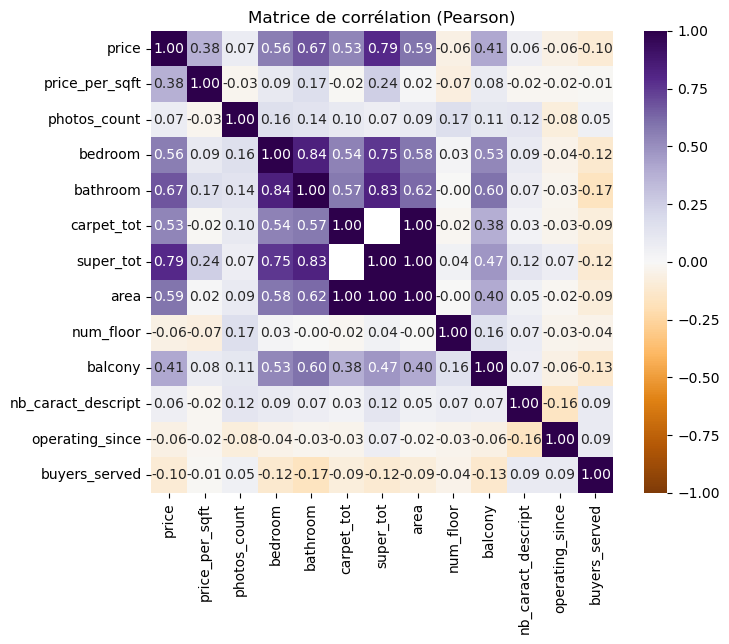

In [147]:
# Matrice de corrélation (Heatmap)

# Sélection des colonnes numériques
numeric_cols = df.select_dtypes(include=["int", "float"])

# Calcul de la matrice de corrélation avec listwise deletion (par défaut dans .corr())
correlation_matrix = numeric_cols.corr()

# Création de la heatmap avec seaborn
plt.figure(figsize=(8, 6))  # Taille du graphique
sns.heatmap(
    correlation_matrix,
    annot=True,  # Affiche les coefficients dans la heatmap
    fmt=".2f",   # Format des coefficients (2 décimales)
    cmap="PuOr",  # Palette de couleurs
    cbar=True,  # Barre de couleur sur le côté
    square=True,  # Cases carrées pour la heatmap
    vmin=-1, vmax=1
)
plt.title("Matrice de corrélation (Pearson)")
plt.show()

Nous pouvons également montrer le coefficient de corrélation linéaire de Pearson dans un graphique par l'intermédiaire d'une courbe de tendance (régression linéaire).

Dans l'esprit de Tukey, les diagrammes de régression de Seaborn sont principalement destinés à ajouter un guide visuel qui aide à mettre en évidence des modèles dans un ensemble de données au cours d'analyses de données exploratoires. La fonction dessine un nuage de points de deux variables, x et y, puis ajuste le modèle de régression y ~ x et trace la ligne de régression résultante ainsi qu'un intervalle de confiance à 95 % pour cette régression :

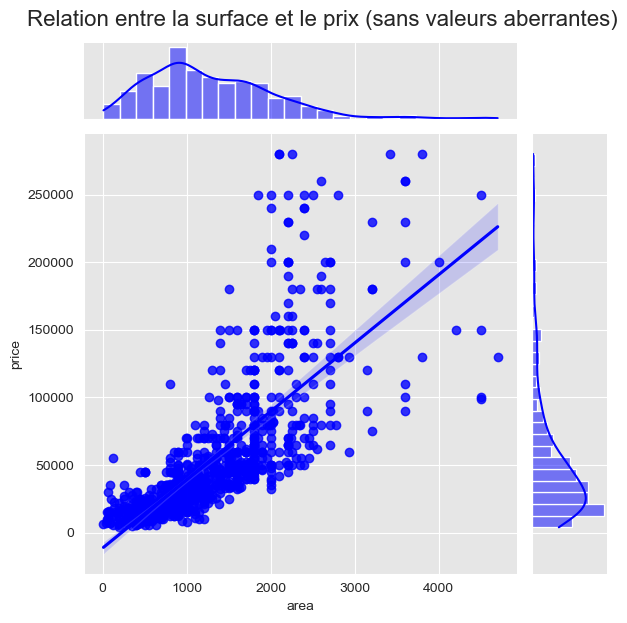

In [149]:
# Fonction qui exclut les valeurs aberrantes
def remove_outliers(df, column, z_threshold=3):
    """
    Exclut les valeurs aberrantes d'une colonne en utilisant le score Z.
    
    Args:
        df (pd.DataFrame): Le DataFrame d'entrée.
        column (str): Nom de la colonne à analyser.
        z_threshold (float): Seuil au-delà duquel une valeur est considérée comme aberrante.
    
    Returns:
        pd.DataFrame: Un DataFrame sans les valeurs aberrantes.
    """
    from scipy.stats import zscore
    
    df_cleaned = df.copy()
    df_cleaned = df_cleaned[(zscore(df_cleaned[column].dropna()) < z_threshold)]
    return df_cleaned

# Suppression des valeurs aberrantes dans les colonnes "area" et "price"
df_no_outliers = remove_outliers(df, "area")
df_no_outliers = remove_outliers(df_no_outliers, "price")

# Application d'un style visuel pour Seaborn
sns.set_style("darkgrid", {"axes.facecolor": ".9"})

# Création du jointplot
jointplot = sns.jointplot(
    x="area", 
    y="price", 
    data=df_no_outliers,
    kind="reg",  # Régression linéaire
    color="blue" # Couleur des points et de la ligne de régression
)

# Ajout d'un titre global au graphique
jointplot.fig.suptitle("Relation entre la surface et le prix (sans valeurs aberrantes)", 
                       fontsize=16, y=1.03)

# Affichage
plt.show()

# Fermeture de la figure pour libérer les ressources
plt.close(jointplot.fig)

Le graphique ci-dessus nous montre la droite de régression linéaire entre les variables area et price, mais également la densité (estimée) des deux variables à travers un histogramme et une courbe KDE.

En faisant l'hypothèse que ces variables soient linéairement corrélées dans la population, nous pouvons voir que dans cet échantillon, les annonces de location en haut à gauche du graphique louent un bien trop cher par rapport à la superficie du bien (toutes choses égales par ailleurs).

Nous pouvons également montrer un graphique pour 3 sous-groupes (les catégories de la variable `furnishing`) et par type de loueurs. Nous avons donc sur un graphique en 2D 4 variables de représentées.

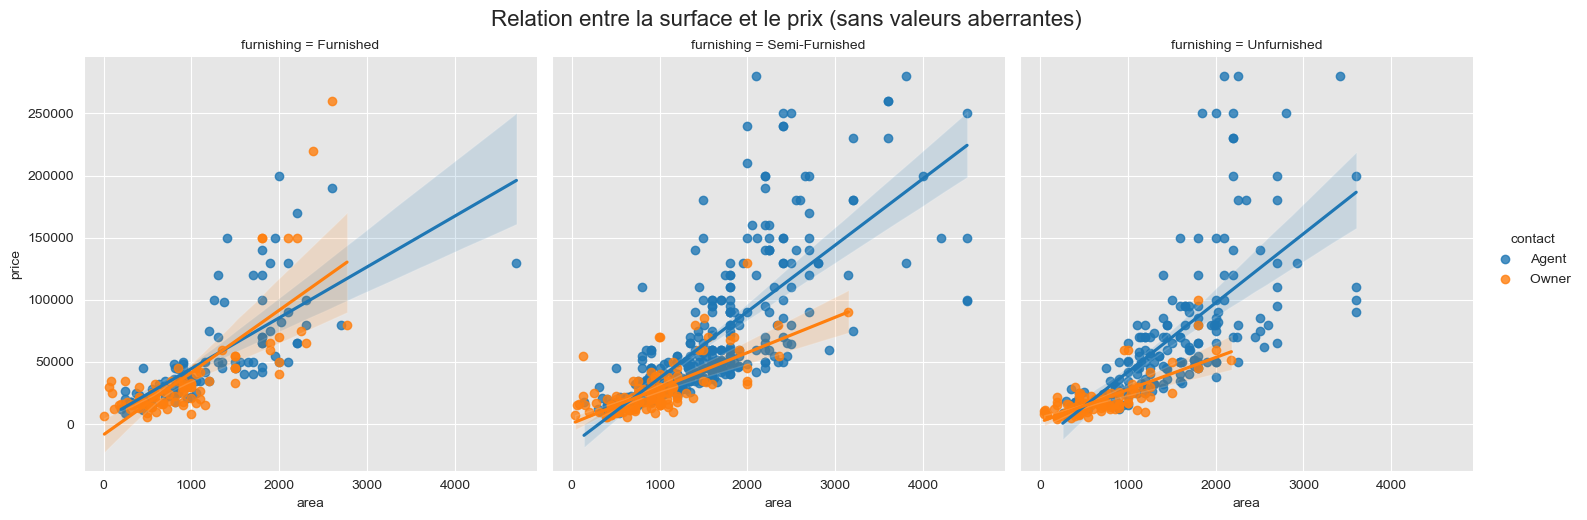

In [151]:
# Fonction qui exclut les valeurs aberrantes
def remove_outliers(df, column, z_threshold=3):
    """
    Exclut les valeurs aberrantes d'une colonne en utilisant le score Z.
    
    Args:
        df (pd.DataFrame): Le DataFrame d'entrée.
        column (str): Nom de la colonne à analyser.
        z_threshold (float): Seuil au-delà duquel une valeur est considérée comme aberrante.
    
    Returns:
        pd.DataFrame: Un DataFrame sans les valeurs aberrantes.
    """
    from scipy.stats import zscore
    
    df_cleaned = df.copy()
    df_cleaned = df_cleaned[(zscore(df_cleaned[column].dropna()) < z_threshold)]
    return df_cleaned

# Suppression des valeurs aberrantes dans les colonnes "area" et "price"
df_no_outliers = remove_outliers(df, "area")
df_no_outliers = remove_outliers(df_no_outliers, "price")

# Application d'un style visuel pour Seaborn
sns.set_style("darkgrid", {"axes.facecolor": ".9"})

# Création du jointplot
lmplot = sns.lmplot(x="area", y="price", data=df_no_outliers, hue="contact",col="furnishing")

# Ajout d'un titre global au graphique
lmplot.fig.suptitle("Relation entre la surface et le prix (sans valeurs aberrantes)", fontsize=16, y=1.03)

# Affichage
plt.show()

# Fermeture de la figure pour libérer les ressources
plt.close(lmplot.fig)

#### Le Coefficient de corrélation de Spearman ($\rho$)

Le coefficient de corrélation de Spearman, noté $\rho$ (ou  $r_s$), est une mesure statistique qui évalue la force et la direction de l'association monotone entre deux variables quantitatives ou ordinales. Contrairement au coefficient de corrélation de Pearson, il ne suppose pas une relation linéaire mais une relation monotone. Ce coefficient a été proposé en 1904 par Charles Spearman.

Le coefficient $\rho$ peut prendre plusieurs valeurs : 
  - $\rho$ varie entre -1 et +1 comme le coefficient de Peason.
  - $\rho = 1$ : Relation parfaitement monotone croissante.
  - $\rho = -1$ : Relation parfaitement monotone décroissante.
  - $\rho = 0$ : Aucune relation monotone détectée.

Le coefficient de Spearman est insensible aux valeurs aberrantes, car il est basé sur les rangs des données et non sur leurs valeurs absolues. C'est donc un indicateur robuste, utilisable sur les variables quantitatives mais aussi ordinales.

La formule générale du coefficient de Spearman est si les données n'ont pas de rangs ex-aequo :
$$
\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}
$$
- $d_i$ : Différence entre les rangs de chaque paire de valeurs $(X_i, Y_i)$.
- $n$ : Nombre d'observations.

Dans le cas où il y a des rangs ex-aequo, on calcule le coefficient de corrélation de Pearson sur les rangs des données :
$$
\rho = \frac{\text{Cov}(R_X, R_Y)}{\sigma_{R_X} \cdot \sigma_{R_Y}}
$$
- $R_X, R_Y$ : Les rangs des observations pour les variables $X$ et $Y$.
- $\text{Cov}(R_X, R_Y)$ : Covariance entre les rangs.
- $\sigma_{R_X}, \sigma_{R_Y}$ : Écarts-types des rangs.

Le coefficient de corrélation de Spearman est un outil puissant pour mesurer les relations monotones, en particulier lorsque les données ne suivent pas une relation linéaire ou contiennent des valeurs aberrantes.

In [153]:
# Exemple d'application

# Importation de Spearmanr
from scipy.stats import spearmanr

# Suppression des lignes avec des valeurs manquantes
filtered_df = df[["photos_count", "area"]].dropna()

# Calcul du coefficient de Spearman
rho, p_value = spearmanr(filtered_df["photos_count"], filtered_df["area"])
print(f"Coefficient de Spearman : {rho}")
print(f"P-valeur : {p_value}")

Coefficient de Spearman : 0.17768939145487117
P-valeur : 1.5397031945745064e-08


Le résultat de 0.23 pour le coefficient de Spearman nous indique que les variables sont faiblement liées entre elles. La p-value < 0,05 nous indique que ce résultat est statistiquement significatif.

Visuellement cela donne :

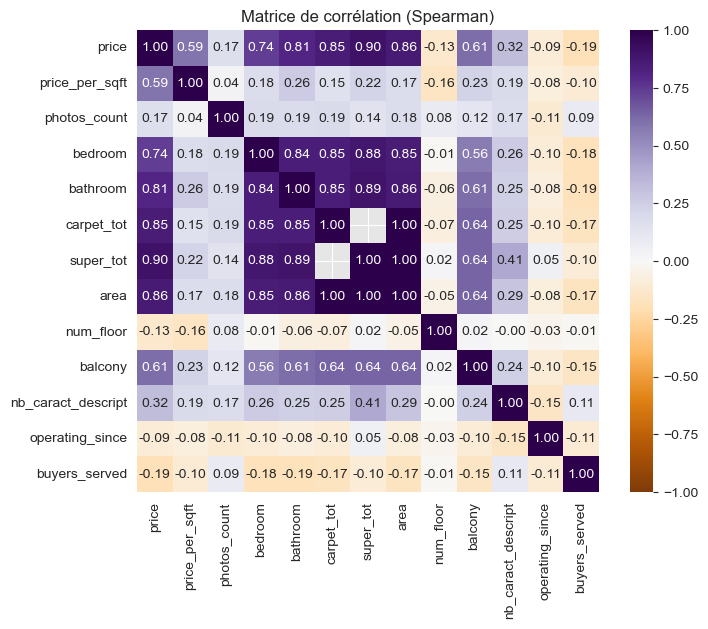

In [155]:
# Matrice de corrélation (Heatmap)

# Sélection des colonnes numériques
numeric_cols = df.select_dtypes(include=["int", "float"])

# Calcul de la matrice de corrélation avec listwise deletion (par défaut dans .corr())
correlation_matrix = numeric_cols.corr(method='spearman')

# Création de la heatmap avec seaborn
plt.figure(figsize=(8, 6))  # Taille du graphique
sns.heatmap(
    correlation_matrix,
    annot=True,  # Affiche les coefficients dans la heatmap
    fmt=".2f",   # Format des coefficients (2 décimales)
    cmap="PuOr",  # Palette de couleurs
    cbar=True,  # Barre de couleur sur le côté
    square=True,  # Cases carrées pour la heatmap
    vmin=-1, vmax=1
)
plt.title("Matrice de corrélation (Spearman)")
plt.show()

Nous pouvons voir que le prix est corrélé avec la surface et que l'intensité de cette relation est plutôt forte avec 86%. Il en va de même avec les variables bedroom et area, bedroom et bathroom, bedroom et price, ou encore bathroom et area. Nous voyons que les variables importantes (qui ont une forte corrélation avec le prix) sont bedroom, bathroom, area et balconny.

Nous allons maintenant passer à l'analyse d'une variable quantitative et d'une variable qualitative.

### Analyse d'une variable quantitative et une qualitative

Il y a trois grands moyens d'analyser une relation éventuelle entre une variable quantitative et une variable qualitative. Ces moyens sont la méthode graphique (à travers des nuages de points, histogrammes ou encore boxplot), les indicateurs statistiques (le rapport de corrélation) et la méthode de l'inférence statistique. Nous utiliserons cette dernière lors de la partie consacrée à l'inférence statistique en générale.

#### Les méthodes graphiques

De manière générale, pour évaluer une possible liaison entre une variable quantitative et qualitative, indépendamment de l’approche choisie, il faut regrouper la variable quantitative en fonction de la variable qualitative. Le but est de savoir si les valeurs de la variable quantitative sont significativement différentes d’un groupe à l’autre.

##### La box-plot

<Figure size 1300x400 with 0 Axes>

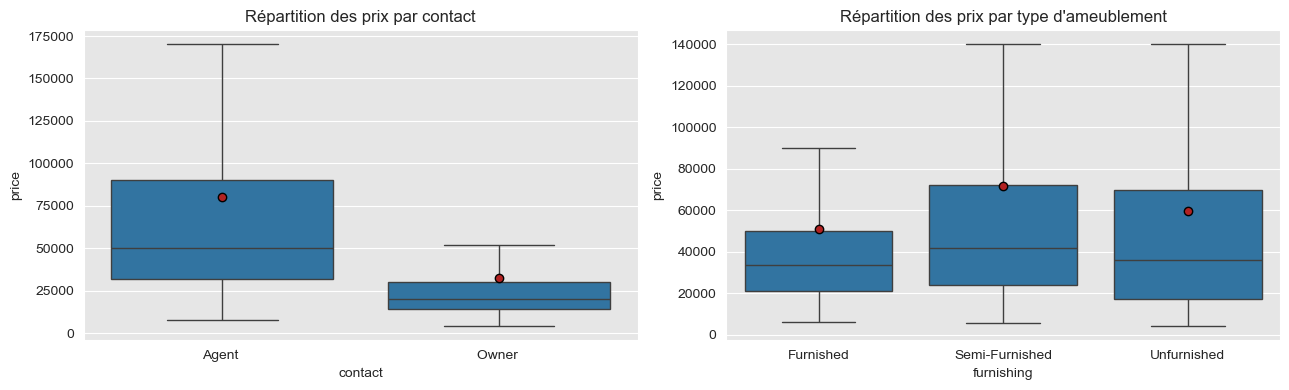

In [162]:
# Création du graphique
plt.figure(figsize=(13,4)) 

# Création du graphique
plt.figure(figsize=(13, 4))  # Taille de la figure

# Sous-graphique 1 : Boxplot pour "contact"
plt.subplot(1, 2, 1)
meanprops = {'marker': 'o', 'markeredgecolor': 'black', 'markerfacecolor': 'firebrick'}
sns.boxplot(x='contact', y='price', data=df, showmeans=True, meanprops=meanprops, showfliers=False)
plt.title("Répartition des prix par contact")

# Sous-graphique 2 : Boxplot pour "furnishing"
plt.subplot(1, 2, 2)
sns.boxplot(x='furnishing', y='price', data=df, showmeans=True, meanprops=meanprops, showfliers=False)
plt.title("Répartition des prix par type d'ameublement")

# Affichage du graphique
plt.tight_layout()  # Ajuste les espaces entre les sous-graphiques
plt.show()

A priori, nous remarquons que le prix moyen des biens de location est différent entre le sous-groupe des `agent` et celui des `owner`. En revanche, les échantillons des sous-groupes de la variable `furnishing` ne semblent pas différents.

Nous pouvons généraliser le script en utilisant les variables de notre choix.

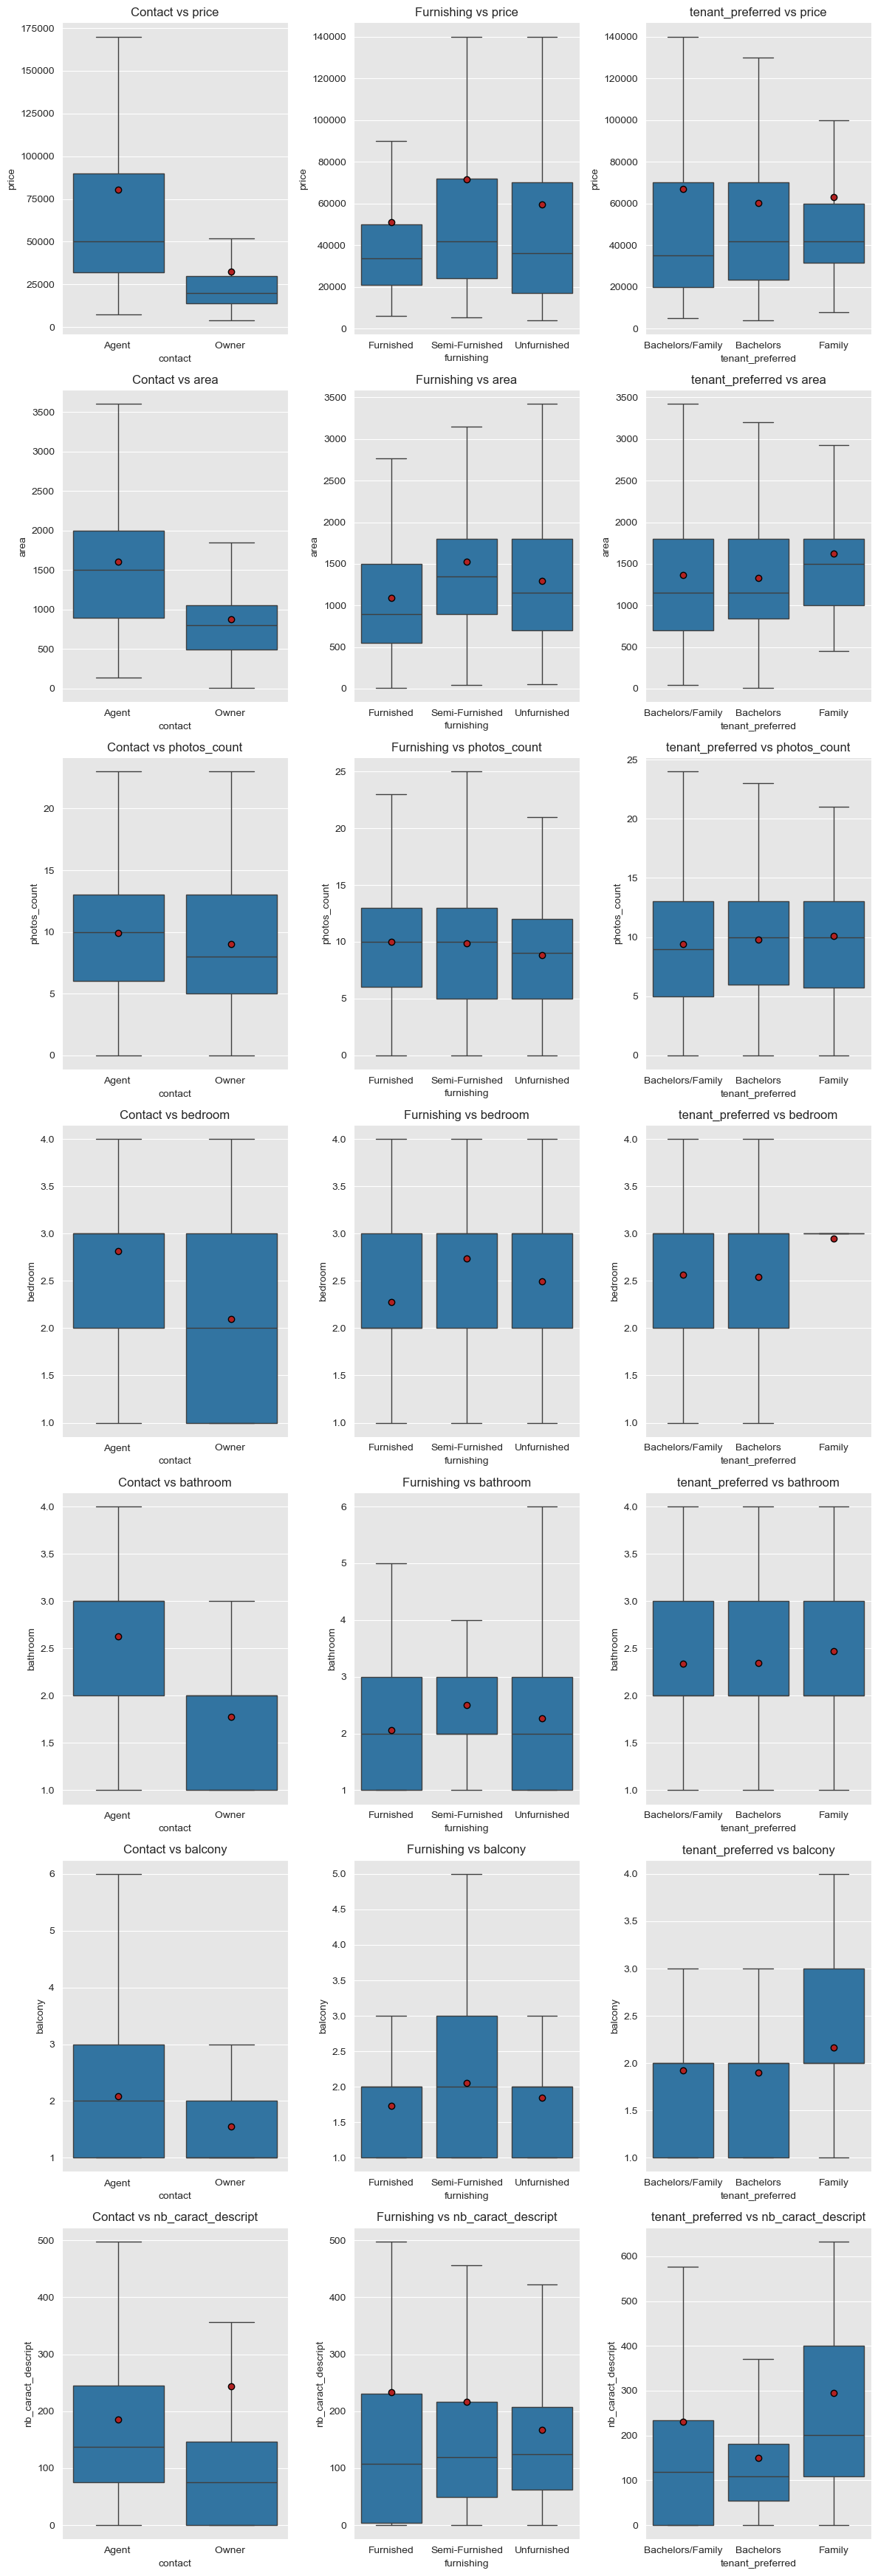

In [164]:
# Liste des variables quantitatives à afficher sur l'axe Y
variables_y = ['price', 'area', 'photos_count','bedroom','bathroom','balcony','nb_caract_descript']

# Création du graphique
n_vars = len(variables_y)  # Nombre de variables
fig, axes = plt.subplots(n_vars, 3, figsize=(12, 5 * n_vars))  # 3 colonnes, n_vars lignes

# Si une seule variable, ajuste les axes pour éviter les erreurs de dimension
if n_vars == 1:
    axes = [axes]

# Boucle sur les variables pour créer les subplots
for i, y_var in enumerate(variables_y):
    # Boxplot pour "contact" (colonne 1)
    sns.boxplot(
        x='contact', y=y_var, data=df, showmeans=True,
        meanprops={'marker': 'o', 'markeredgecolor': 'black', 'markerfacecolor': 'firebrick'},
        showfliers=False, ax=axes[i][0]
    )
    axes[i][0].set_title(f"Contact vs {y_var}")

    # Boxplot pour "furnishing" (colonne 2)
    sns.boxplot(
        x='furnishing', y=y_var, data=df, showmeans=True,
        meanprops={'marker': 'o', 'markeredgecolor': 'black', 'markerfacecolor': 'firebrick'},
        showfliers=False, ax=axes[i][1]
    )
    axes[i][1].set_title(f"Furnishing vs {y_var}")

    # Boxplot pour "tenant_preferred" (colonne 3)
    sns.boxplot(
        x='tenant_preferred', y=y_var, data=df, showmeans=True,
        meanprops={'marker': 'o', 'markeredgecolor': 'black', 'markerfacecolor': 'firebrick'},
        showfliers=False, ax=axes[i][2]
    )
    axes[i][2].set_title(f"tenant_preferred vs {y_var}")

# Ajustement des espaces entre les graphiques
plt.tight_layout()
plt.show()

Globalement, nous pouvons penser que les sous-groupes des 3 variables qualitatives `contact`, `furnishing` et `tenant_preferred`sont plutôt homogène. Les seuls sous-échantillons qui diffèrent sont 'contact vs price', 'contact vs area', 'contact vs bathroom' et peut être 'contact vs nb_caract_descript' et 'tenant_preferred vs nb_caract_descript'.

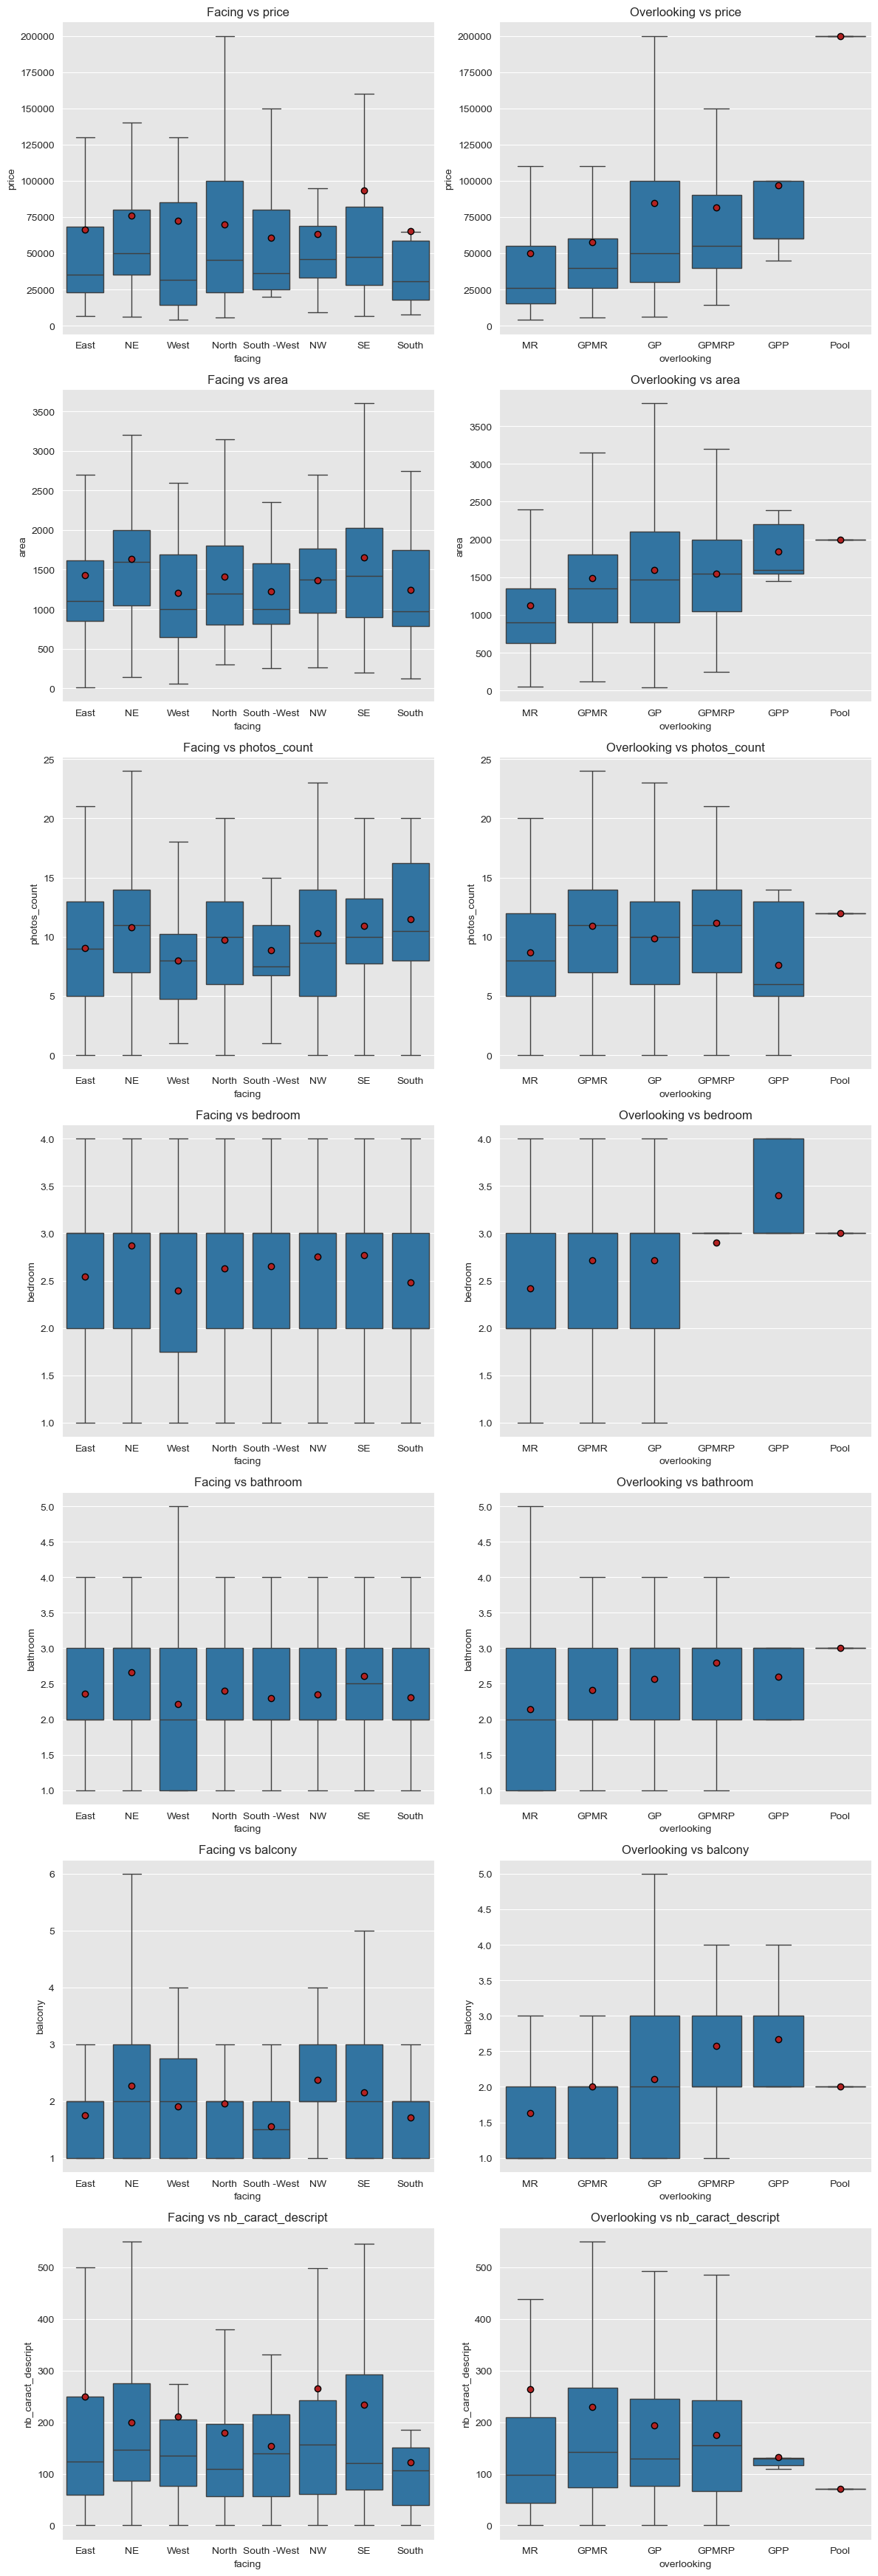

In [166]:
# Renommer les catégories pour éviter les chevauchements
facing_renaming = {'East': 'East', 'North - East': 'NE', 'West': 'West', 'North': 'North', 
                   'South - West': 'SW', 'North - West': 'NW', 'South - East': 'SE', 'South': 'South'}
overlooking_renaming = {'Garden/Park': 'GP', 'Garden/Park, Main Road': 'GPMR', 
                        'Garden/Park, Main Road, Pool': 'GPMRP', 'Garden/Park, Pool': 'GPP',
                        'Main Road': 'MR', 'Pool':'Pool'}


# Liste des variables quantitatives à afficher sur l'axe Y
variables_y = ['price', 'area', 'photos_count','bedroom','bathroom','balcony','nb_caract_descript']

# Création du graphique
n_vars = len(variables_y)  # Nombre de variables
fig, axes = plt.subplots(n_vars, 2, figsize=(12, 5 * n_vars))  # 2 colonnes, n_vars lignes

# Si une seule variable, ajuste les axes pour éviter les erreurs de dimension
if n_vars == 1:
    axes = [axes]

# Boucle sur les variables pour créer les subplots
for i, y_var in enumerate(variables_y):
    # Boxplot pour "facing" (colonne 1)
    sns.boxplot(
        x=df['facing'].replace(facing_renaming), y=y_var, data=df, showmeans=True,
        meanprops={'marker': 'o', 'markeredgecolor': 'black', 'markerfacecolor': 'firebrick'},
        showfliers=False, ax=axes[i][0]
    )
    axes[i][0].set_title(f"Facing vs {y_var}")

    # Boxplot pour "overlooking" (colonne 2)
    sns.boxplot(
        x=df['overlooking'].replace(overlooking_renaming), y=y_var, data=df, showmeans=True,
        meanprops={'marker': 'o', 'markeredgecolor': 'black', 'markerfacecolor': 'firebrick'},
        showfliers=False, ax=axes[i][1]
    )
    axes[i][1].set_title(f"Overlooking vs {y_var}")

# Ajustement des espaces entre les graphiques
plt.tight_layout()
plt.show()

Comme précédemment, nous pouvons voir que les différentes statistiques ne diffèrent pas énormément entre les différents sous-groupes en fonction des catégories. Nous pouvons voir que certains boxplot sont 'écrasés', cela est certainement dû au fait que le nombre de valeurs de cette catégorie est très faible.

L'autre graphique très utilisé pour visualiser l'impact d'une variable qualitative sur une variable quantitative est l'histogramme.

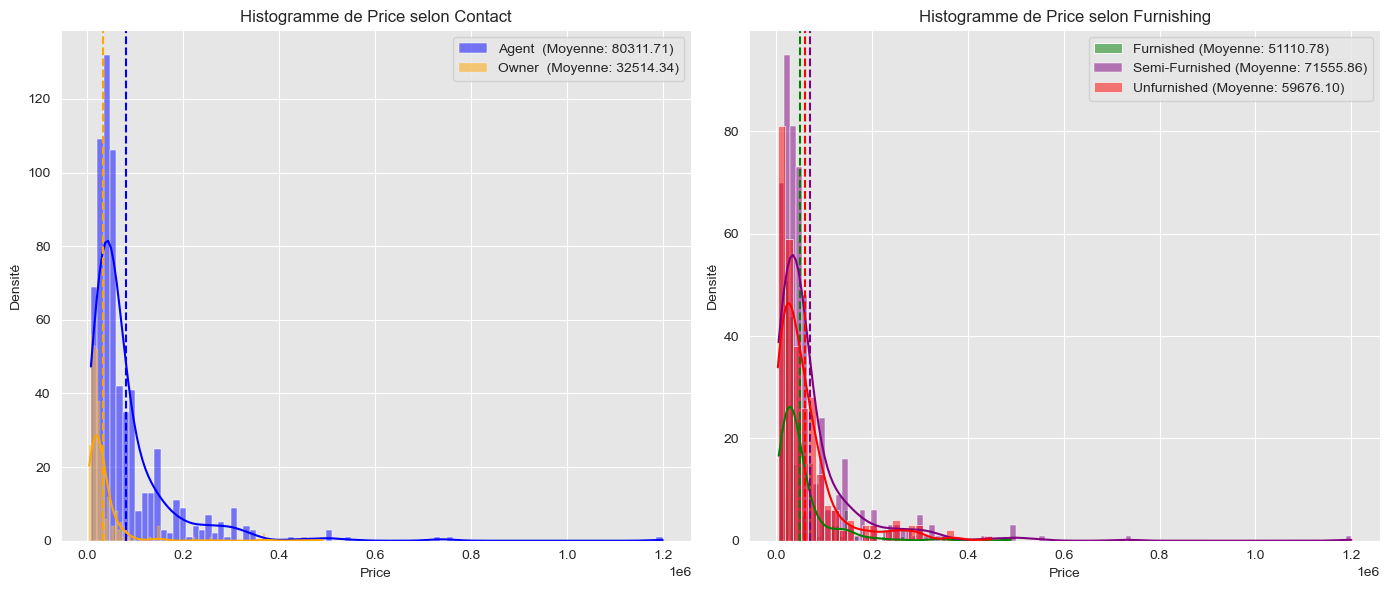

In [168]:
# Création de la figure avec 2 sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Palette de couleurs
contact_colors = ['blue', 'orange']  # Couleurs pour les catégories de "contact"
furnishing_colors = ['green', 'purple', 'red']  # Couleurs pour les catégories de "furnishing"

# Premier subplot : Histogrammes pour les catégories de "contact"
for category, color in zip(df['contact'].unique(), contact_colors):
    subset = df[df['contact'] == category]
    sns.histplot(
        subset['price'], kde=True, color=color, label=f'{category} (Moyenne: {subset["price"].mean():.2f})',
        ax=axes[0], alpha=0.5
    )
    # Ligne verticale pour la moyenne
    axes[0].axvline(subset['price'].mean(), color=color, linestyle='--', linewidth=1.5)

axes[0].set_title('Histogramme de Price selon Contact')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Densité')
axes[0].legend()

# Second subplot : Histogrammes pour les catégories de "furnishing"
for category, color in zip(df['furnishing'].unique(), furnishing_colors):
    subset = df[df['furnishing'] == category]
    sns.histplot(
        subset['price'], kde=True, color=color, label=f'{category} (Moyenne: {subset["price"].mean():.2f})',
        ax=axes[1], alpha=0.5
    )
    # Ligne verticale pour la moyenne
    axes[1].axvline(subset['price'].mean(), color=color, linestyle='--', linewidth=1.5)

axes[1].set_title('Histogramme de Price selon Furnishing')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Densité')
axes[1].legend()

# Ajustement des espaces entre les subplots
plt.tight_layout()
plt.show()

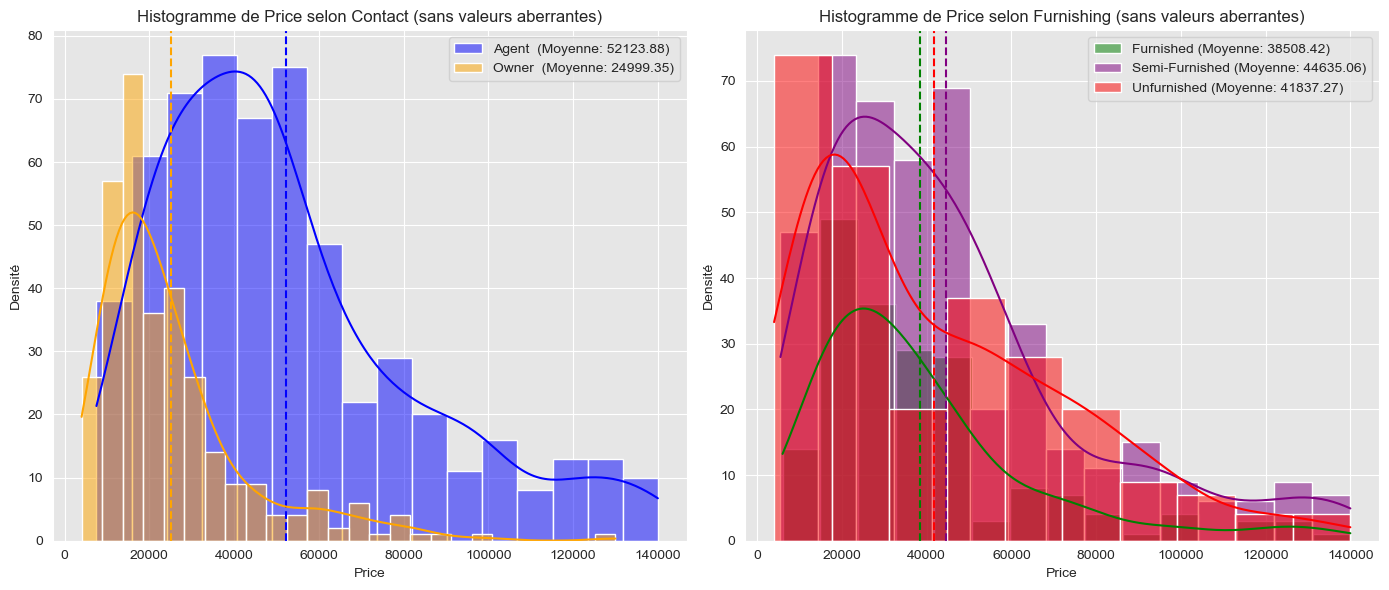

In [169]:
# Suppression des valeurs aberrantes pour la variable "price" (méthode IQR)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrer les données sans valeurs aberrantes
df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# Création de la figure avec 2 sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Palette de couleurs
contact_colors = ['blue', 'orange']  # Couleurs pour les catégories de "contact"
furnishing_colors = ['green', 'purple', 'red']  # Couleurs pour les catégories de "furnishing"

# Premier subplot : Histogrammes pour les catégories de "contact"
for category, color in zip(df_filtered['contact'].unique(), contact_colors):
    subset = df_filtered[df_filtered['contact'] == category]
    sns.histplot(
        subset['price'], kde=True, color=color, label=f'{category} (Moyenne: {subset["price"].mean():.2f})',
        ax=axes[0], alpha=0.5
    )
    # Ligne verticale pour la moyenne
    axes[0].axvline(subset['price'].mean(), color=color, linestyle='--', linewidth=1.5)

axes[0].set_title('Histogramme de Price selon Contact (sans valeurs aberrantes)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Densité')
axes[0].legend()

# Second subplot : Histogrammes pour les catégories de "furnishing"
for category, color in zip(df_filtered['furnishing'].unique(), furnishing_colors):
    subset = df_filtered[df_filtered['furnishing'] == category]
    sns.histplot(
        subset['price'], kde=True, color=color, label=f'{category} (Moyenne: {subset["price"].mean():.2f})',
        ax=axes[1], alpha=0.5
    )
    # Ligne verticale pour la moyenne
    axes[1].axvline(subset['price'].mean(), color=color, linestyle='--', linewidth=1.5)

axes[1].set_title('Histogramme de Price selon Furnishing (sans valeurs aberrantes)')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Densité')
axes[1].legend()

# Ajustement des espaces entre les subplots
plt.tight_layout()
plt.show()

Nous voyons qu'à priori la variable `contact` a un effet sur la variable `price`. En effet, la moyenne d'un sous-échantillon est le double de l'autre. Nous pouvons en conclure que les `agent` louent en moyenne leurs biens plus cher que les `owner`. 

#### Les indicateurs statistiques

##### Le Rapport de Corrélation

Le rapport de corrélation est un indicateur statistique qui évalue l'intensité de la relation entre une variable quantitative et une variable qualitative. Contrairement au coefficient de corrélation classique (comme celui de Pearson), qui mesure une relation linéaire entre deux variables quantitatives, le rapport de corrélation est adapté aux cas où l'une des variables est catégorielle et l'autre continue.

Ce rapport, souvent noté $\eta^2$ (eta carré), est défini comme la proportion de la variance totale de la variable quantitative $Y$ expliquée par les catégories de la variable qualitative $X$. Mathématiquement :

$$
\eta^2 = \frac{\sum_{i=1}^k n_i (\bar{Y}_{x_i} - \bar{Y})^2}{\sum_{i=1}^n (Y_i - \bar{Y})^2}
$$

où le numérateur est la somme des carrés expliquée par les différences entre les moyennes des catégories de $X$ (pour chaque catégorie $x_i$ de la variable qualitative $X$, calculer la moyenne $\bar{Y}_{x_i}$ et la variance associée à cette catégorie) et le dénominateur est la somme des carrés totale soit la variance totale de $Y$ avec $n_i$ le nombre d'observations dans la catégorie $x_i$ et $k$ le nombre total de catégories.

Le rapport de corrélation prend des valeurs entre 0 et 1 :  
- $\eta^2 = 0$ : Aucune liaison entre les deux variables. La variable qualitative $X$ n'a que peu ou pas d'effet sur la variable quantitative $Y$.
- $\eta^2 = 1$ : Une relation parfaite, chaque catégorie de $X$ explique entièrement la variation de $Y$.

L'interprétation de ce rapport est limitée. En effet, il mesure l'intensité de la relation mais pas son sens. De plus, si une catégorie contient beaucoup plus d'observations que les autres, le résultat peut être biaisé. D'où l'intérêt de combiner les méthodes statistiques avec celles graphiques.

Voici un exemple de script pour calculer le rapport de corrélation en Python :

In [173]:
def rapport_de_correlation(df, qualitative_col, quantitative_col):
    '''
    Fonction pour calculer le rapport de corrélation entre une
    variable qualitative et une variable quantitative
    '''
    
    # Moyenne globale de la variable quantitative
    mean_y = df[quantitative_col].mean()

    # Variance totale (SCT)
    sct = np.sum((df[quantitative_col] - mean_y) ** 2)

    # Variance expliquée entre les catégories (SCE_entre)
    sce_entre = 0
    for category in df[qualitative_col].unique():
        subset = df[df[qualitative_col] == category]
        n_i = len(subset)
        mean_y_i = subset[quantitative_col].mean()
        sce_entre += n_i * (mean_y_i - mean_y) ** 2

    # Calcul du rapport de corrélation
    eta_squared = sce_entre / sct
    return eta_squared

# Exemple d'utilisation
eta2 = rapport_de_correlation(df, "contact", "price")
print(f"Rapport de corrélation (η²) : {eta2:.3f}")

Rapport de corrélation (η²) : 0.068


Nous allons modifier le script pour enlever les valeurs manquantes et aberrantes.

In [175]:
def rapport_de_correlation2(df, qualitative_col, quantitative_col):
    '''
    Fonction pour calculer le rapport de corrélation entre une
    variable qualitative et une variable quantitative,
    en excluant les valeurs manquantes et aberrantes.
    '''
    # Suppression des valeurs manquantes
    df = df[[qualitative_col, quantitative_col]].dropna()

    # Détection et suppression des valeurs aberrantes (IQR de 2)
    Q1 = df[quantitative_col].quantile(0.25)
    Q3 = df[quantitative_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR
    df = df[(df[quantitative_col] >= lower_bound) & (df[quantitative_col] <= upper_bound)]

    # Vérification que le DataFrame n'est pas vide après filtrage
    if df.empty:
        print("Aucune donnée exploitable après suppression des valeurs aberrantes.")
        return np.nan

    # Moyenne globale de la variable quantitative
    mean_y = df[quantitative_col].mean()

    # Variance totale (SCT)
    sct = np.sum((df[quantitative_col] - mean_y) ** 2)

    # Variance expliquée entre les catégories (SCE_entre)
    sce_entre = 0
    for category in df[qualitative_col].unique():
        subset = df[df[qualitative_col] == category]
        n_i = len(subset)
        mean_y_i = subset[quantitative_col].mean()
        sce_entre += n_i * (mean_y_i - mean_y) ** 2

    # Calcul du rapport de corrélation
    eta_squared = sce_entre / sct if sct != 0 else 0  # Éviter la division par zéro
    return eta_squared

# Exemple d'utilisation
eta2 = rapport_de_correlation2(df, "contact", "price")
print(f"Rapport de corrélation (η²) : {eta2:.3f}")

Rapport de corrélation (η²) : 0.164


En supprimant les valeurs aberrantes des colonnes, le rapport éta augmente pour atteindre 0,164 ce qui reste faible. La variable qualitative a un "petit" effet sur la variable quantitative.

Nous pouvons générer le rapport $\eta^2$ pour une liste de colonnes quantitatives.

In [177]:
# Liste des variables quantitatives à analyser
quantitative_cols = ["price", "area", "photos_count", "bedroom", "bathroom", "balcony", "nb_caract_descript"]

# Variable qualitative à utiliser
qualitative_col = "contact"

# Calcul et affichage du rapport de corrélation pour chaque variable quantitative
for quantitative_col in quantitative_cols:
    eta2 = rapport_de_correlation(df, qualitative_col, quantitative_col)
    print(f"Rapport de corrélation (η²) entre {qualitative_col} et {quantitative_col} : {eta2:.3f}")

Rapport de corrélation (η²) entre contact et price : 0.068
Rapport de corrélation (η²) entre contact et area : 0.088
Rapport de corrélation (η²) entre contact et photos_count : 0.004
Rapport de corrélation (η²) entre contact et bedroom : 0.125
Rapport de corrélation (η²) entre contact et bathroom : 0.152
Rapport de corrélation (η²) entre contact et balcony : 0.082
Rapport de corrélation (η²) entre contact et nb_caract_descript : 0.005


Le rapport de 0.004 entre la variable `contact` et `photos_count` nous indique que la variable qualitative n'a aucun effet sur la variable quantitative.

Le meilleur score que nous avons est 0.167 ce qui reste faible. Nous pouvons donc conclure que la variable `contact` n'influence que très peu les autres variables. Dans une régression linéaire (simple ou multiple) cette variable n'aura que peu d'intérêt et ne sera pas significativement responsable d'un phénomène.

### Analyse de 2 variables qualitatives

#### Le Tableau de Contingence

Un tableau de contingence est un outil statistique qui permet d’analyser l’association entre deux variables qualitatives. Il organise les fréquences absolues ou relatives des modalités des variables pour faciliter leur comparaison et leur interprétation.  

Dans ce tableau à double entrée les lignes correspondent aux modalités d’une première variable qualitative et les colonnes correspondent aux modalités d’une seconde variable qualitative. Les cellules contiennent le nombre d’occurrences pour chaque combinaison des modalités.

In [182]:
# Création d'un tableau de contingence
df[['contact', 'furnishing']].pivot_table(index='contact', columns='furnishing',
                                          aggfunc=len, margins=True, margins_name="Total")

furnishing,Furnished,Semi-Furnished,Unfurnished,Total
contact,,,,
Agent,112,366,187,665
Owner,92,137,98,327
Total,204,503,285,992


Le tableau de contingence peut être représenté graphiquement à l'aide des fréquences d'un diagramme en barres (empilées ou groupées).

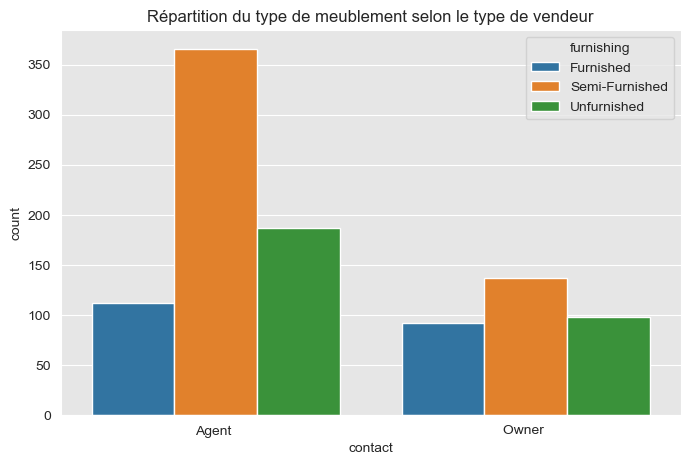

In [184]:
# Création du graphique
plt.figure(figsize=(8,5))
sns.countplot(x="contact", hue="furnishing", data=df)
plt.title("Répartition du type de meublement selon le type de vendeur")

# Affichage
plt.show()

Le tableau des profils-lignes est le tableau des fréquences conditionnelles $\frac{n_{ij}}{n_{i\cdot}}$ (la somme de chaque ligne est ramenée à 1) et le tableau des profils-colonnes est le taleau des fréquences conditionnelles $\frac{n_{ij}}{n_{\cdot j}}$.

Nous pouvons remarquer que la moyenne des profils-lignes avec des poids correspondant aux effectifs marginaux des lignes est le profil marginal des colonnes :
$$
\sum_{i=1}^{r} \frac{n_{ij}}{n_{i\cdot}}(\frac{n_{i\cdot}}{n}) = \frac{n_{j\cdot}}{n}
$$
de même :
$$
\sum_{i=1}^{s} \frac{n_{ij}}{n_{\cdot j}}(\frac{n_{\cdot j}}{n}) = \frac{n_{i\cdot}}{n}
$$

In [186]:
# Création d'un tableau de contingence
contingency_table = df[['contact', 'furnishing']].pivot_table(index='contact', columns='furnishing',
                                          aggfunc=len, margins=True, margins_name="Total")

# Profils-lignes
contingency_table.div(contingency_table["Total"], axis=0)

furnishing,Furnished,Semi-Furnished,Unfurnished,Total
contact,,,,
Agent,0.168421,0.550376,0.281203,1.0
Owner,0.281346,0.418960,0.299694,1.0
Total,0.205645,0.507056,0.287298,1.0


#### La Mesure de Liaison $d^2$ ou Khi-Deux ($\chi^2$)

La mesure de liaison du khi² est utilisée pour déterminer si une relation existe entre deux variables catégorielles. Ce test statistique vérifie si les fréquences observées dans un échantillon diffèrent significativement des fréquences attendues, ce qui peut être utilisé pour tester l'indépendance entre deux variables aléatoires.

Généralement on interprète la valeur du khi-deux comme :
- Si $\chi^2$ est faible, les effectifs observés sont proches des effectifs attendus donc les variables sont indépendantes.
- Si $\chi^2$ est élevé, les effectifs observés sont très différents des effectifs attendus et les variables sont dépendantes.

En anticipant un peu sur la partie Inférence Statistique, les conditions énoncées pour réaliser un test du chi-2 sont souvent :
- Condition n°1 :  L'effectif total du tableau de contingence ($n$) doit être supérieur ou égal à 20
- Condition n°2 :  L'effectif marginal du tableau de contingence ($n_{i \cdot}$ ou $n_{\cdot j}$) doit toujours être supérieur ou égal à 5.
- Condition n°3 :  L'effectif théorique ($n_{ij}$) des  cases du tableau de contingence doit être supérieur à 5 dans 80% des cases du tableau de contingence.

En python, avec les hypothèses suivantes, cela donne :
- $H_0$ : Les variables sont indépendantes.
- $H_1$ : Les variables ne sont pas indépendantes.

Et avec le degré de significativité des relations statistiques (p-value) suivant :
 
| Seuil de rejet de $H_0$ | Relation ... | Symbole |
|----------------------------|------------|-----------|
| > 0.10              | ... non significative        | -          |
| 0.05 à 0.10              | ... peu significative          | *        |
| 0.01 à 0.05              | ... significative          | **          |
| 0.001 à 0.01                | ... très significative        | ***        |
| 0.001 <                | ... extrêmement significative        | ****        |les sont dépendantes.

In [189]:
# Importation de la fonction
from scipy.stats import chi2_contingency

# Création du tableau de contingence
table_contingence = pd.crosstab(df["contact"], df["furnishing"])

# Test du Khi-Deux
chi2, p_value, dof, expected = chi2_contingency(table_contingence)

print(f"Statistique Khi-Deux: {chi2:.3f}")
print(f"P-value : {p_value:.5f}")

if p_value < 0.05:
    print("Les variables sont dépendantes (on rejette l'hypothèse d'indépendance).")
else:
    print("Les variables sont indépendantes.")

Statistique Khi-Deux: 21.320
P-value : 0.00002
Les variables sont dépendantes (on rejette l'hypothèse d'indépendance).


#### Les Mesures de l’Intensité
Si le test Khi-Deux montre une association, plusieurs coefficients liés au $d^2$ ($\chi^2$) ont été proposés pour obtenir une mesure comprise entre 0 (indépendance) et 1 (liaison fonctionnelle) de la force de cette association. 

Les plus connus sont :

Le coefficient de contingence de K. Pearson $C = \sqrt{\frac{\chi^2}{n + \chi_2}}$;

Le coefficient de Tschuprow $T = \sqrt{\frac{\chi^2}{n \sqrt{(r - 1)(s - 1)}}}$;

Le coefficient de Cramer $V = \sqrt{\frac{\chi^2}{n \times \min[(r-1);(s-1)]}}$

On interprète ces coefficients comme :
| Coefficient | Force de l’Association |
|-------------|----------------------|
| 0.1 - 0.2   | Faible               |
| 0.2 - 0.4   | Modérée              |
| 0.4 - 0.6   | Forte                |
| > 0.6       | Très Forte           |

Par exemple, si $V \approx 1$, alors la dépendance est quasi-fonctionnelle.

In [191]:
# Calcul du V de Cramer
n = table_contingence.sum().sum()
r, s = table_contingence.shape
cramer_v = np.sqrt(chi2 / (n * (min(r-1, s-1))))

print(f"Le coefficient V de Cramer est {cramer_v:.3f}")

Le coefficient V de Cramer est 0.147


#### La Contribution au Khi-Deux 

La construction du tableau des $\frac{n_{i \cdot}n_{\cdot j}}{n}$ qui est le tableau d'indépendance et sa comparaison avec le tableau des $n_{ij}$ est souvent importante, en particulier le calcul pour chaque case du terme : 
$$
\text{Contribution}_{ij} = \frac{(n_{ij} - E_{ij})^2}{E_{ij}} \times \frac{1}{\chi^2}
$$ 
appelé contribution au $\chi^2$ car elle indique quelles cellules du tableau de contingence participent le plus à la dépendance entre les variables et donc quels écarts sont les plus significatifs. Une valeur élevée signifie que la cellule contribue fortement à l’association. A l'inverse, une valeur faible signifie que la cellule a peu ou pas d’impact sur la liaison.

In [194]:
# Calcul de la contribution
contributions = (table_contingence - expected) ** 2 / expected
print(contributions)

furnishing  Furnished  Semi-Furnished  Unfurnished
contact                                           
Agent        4.480761        2.461115     0.085998
Owner        9.112251        5.005020     0.174890


In [195]:
def tableau_independance_et_contribution(df, var1, var2):
    """
    Calcule le tableau d'indépendance et la contribution au khi-2 pour deux variables qualitatives.
    
    Paramètres :
    df : DataFrame pandas contenant les données.
    var1 : Nom de la première variable qualitative (index du tableau de contingence).
    var2 : Nom de la deuxième variable qualitative (colonnes du tableau de contingence).

    Retourne :
    - Le tableau d’indépendance (effectifs attendus)
    - La matrice des contributions au khi-2
    """
    
    # Création du tableau de contingence (effectifs observés)
    tableau_contingence = pd.crosstab(df[var1], df[var2])
    
    # Calcul du khi-2, des effectifs attendus et des p-values
    khi2, p_value, dof, effectifs_attendus = chi2_contingency(tableau_contingence)
    
    # Conversion en DataFrame (tableau d’indépendance)
    tableau_independance = pd.DataFrame(effectifs_attendus, 
                                        index=tableau_contingence.index, 
                                        columns=tableau_contingence.columns)
    
    # Calcul de la contribution individuelle au khi-2
    contribution_khi2 = ((tableau_contingence - tableau_independance) ** 2) / tableau_independance
    
    # Normalisation de la contribution au khi-2
    contribution_khi2_norm = contribution_khi2 / khi2
    
    return tableau_independance, contribution_khi2, contribution_khi2_norm

# Exemple d'utilisation
tableau_indep, contrib_khi2, contrib_khi2_norm = tableau_independance_et_contribution(df, "contact", "furnishing")

# Affichage des résultats
print("\n Tableau d'Indépendance (Effectifs Attendus) :")
print(tableau_indep)

print("\n Contribution au Khi-2 par cellule :")
print(contrib_khi2)

print("\n Contribution normalisée au Khi-2 par cellule :")
print(contrib_khi2_norm)


 Tableau d'Indépendance (Effectifs Attendus) :
furnishing   Furnished  Semi-Furnished  Unfurnished
contact                                            
Agent       136.754032       337.19254   191.053427
Owner        67.245968       165.80746    93.946573

 Contribution au Khi-2 par cellule :
furnishing  Furnished  Semi-Furnished  Unfurnished
contact                                           
Agent        4.480761        2.461115     0.085998
Owner        9.112251        5.005020     0.174890

 Contribution normalisée au Khi-2 par cellule :
furnishing  Furnished  Semi-Furnished  Unfurnished
contact                                           
Agent        0.210167        0.115437     0.004034
Owner        0.427403        0.234757     0.008203


Nous analysons ici l'association entre les variables "contact" (Agent ou Owner) et "furnishing" (Furnished, Semi-Furnished, Unfurnished) grâce à un test du khi-2 et aux contributions individuelles des cellules.  
  
Pour le tableau d'indépendance, nous  savons qu'il représente les effectifs que nous attendrions si les deux variables étaient indépendantes. Par exemple, si "contact" et "furnishing" n'avaient aucun lien, on s’attendrait à voir environ 136.75 logements meublés gérés par des agents et 67.25 par des propriétaires.

Pour le second tableau, chaque cellule indique dans quelle mesure elle contribue au score global du khi-2. Plus la valeur est élevée, plus l'écart entre les effectifs observés et attendus est grand (plus cette case influence la dépendance). Ici, la catégorie Owner : Furnished a la plus grande contribution (9.11), ce qui signifie que la part des propriétaires qui proposent des logements meublés est très différente de ce qu'on attendrait sous hypothèse d'indépendance. Ensuite, la catégorie Agent : Furnished contribue aussi fortement (4.48). La catégorie Unfurnished a des contributions très faibles, ce qui indique qu'il n'y a pas de grand écart entre les effectifs attendus et observés pour cette catégorie.
  
Enfin, le troisième tableau montre les contributions en pourcentage du total du khi-2 (le poids relatif des écarts). La modalité Furnished explique à lui seul 63.7% du khi-2 (42.7% Owner + 21.0% Agent). La modalité Semi-Furnished contribue elle aussi de manière significative (23.5% Owner + 11.5% Agent). En revanche, Unfurnished n’a presque aucune influence (0.4% + 0.8%), ce qui suggère que le choix entre agent ou propriétaire n'affecte pas vraiment la décision d’avoir un logement non meublé.

En conclusion, les variables "contact" et "furnishing" ne sont pas indépendantes car certaines cellules ont de fortes contributions au khi-2. Les propriétaires proposent proportionnellement beaucoup plus de logements meublés que ce qu'on attendrait sous hypothèse d'indépendance. De plus, les agents gèrent principalement des logements non meublés et semi-meublés (ce qui est conforme aux attentes). Enfin, les logements non meublés semblent répartis de manière équilibrée entre agents et propriétaires, ce qui signifie que ce critère n’est pas influencé par le type de contact.  

Nous pouvons visuellement afficher ces résultats grâce à une Heatmap (carte de chaleur).

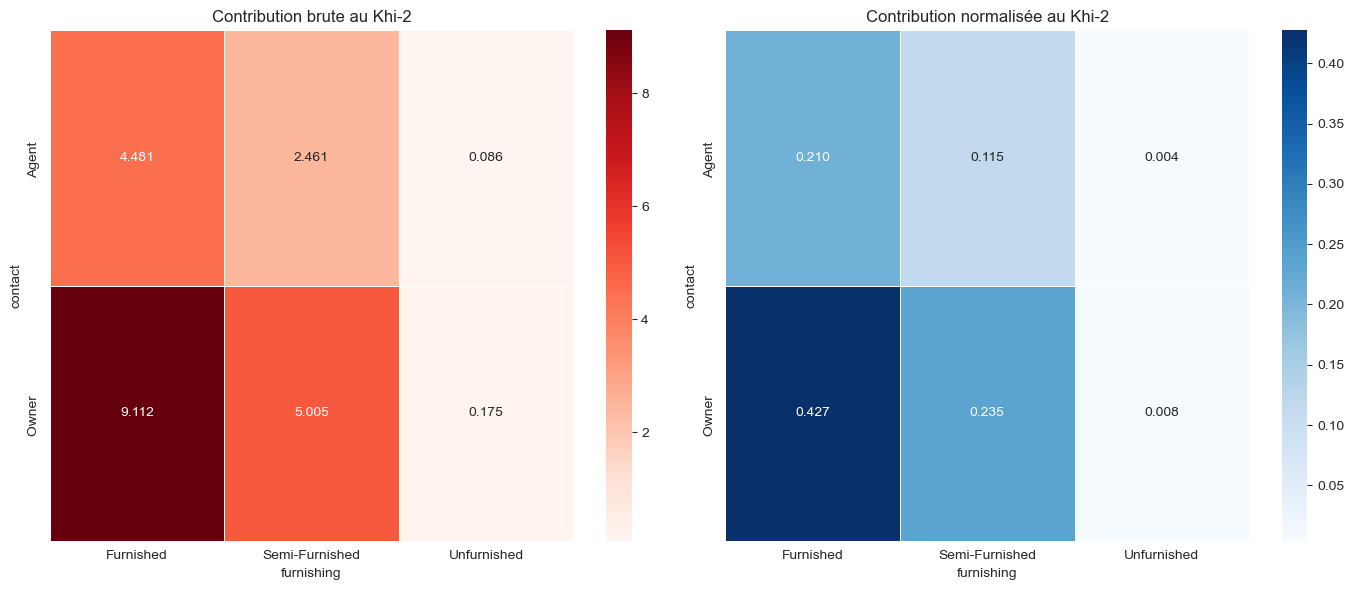

In [197]:
def tableau_independance_et_contribution(df, var1, var2):
    """
    Calcule le tableau d'indépendance et la contribution au khi-2 pour deux variables qualitatives.
    Affiche la contribution sous forme de heatmap.

    Paramètres :
    df : DataFrame pandas contenant les données.
    var1 : Nom de la première variable qualitative (index du tableau de contingence).
    var2 : Nom de la deuxième variable qualitative (colonnes du tableau de contingence).

    Retourne :
    - Le tableau d’indépendance (effectifs attendus)
    - La matrice des contributions au khi-2 (heatmap)
    """
    
    # Création du tableau de contingence (effectifs observés)
    tableau_contingence = pd.crosstab(df[var1], df[var2])
    
    # Calcul du khi-2, des effectifs attendus et des p-values
    khi2, p_value, dof, effectifs_attendus = chi2_contingency(tableau_contingence)
    
    # Conversion en DataFrame (tableau d’indépendance)
    tableau_independance = pd.DataFrame(effectifs_attendus, 
                                        index=tableau_contingence.index, 
                                        columns=tableau_contingence.columns)
    
    # Calcul de la contribution individuelle au khi-2
    contribution_khi2 = ((tableau_contingence - tableau_independance) ** 2) / tableau_independance
    
    # Normalisation de la contribution au khi-2
    contribution_khi2_norm = contribution_khi2 / khi2
    
    # Affichage des heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(contribution_khi2, annot=True, cmap="Reds", fmt=".3f", linewidths=0.5, ax=axes[0])
    axes[0].set_title("Contribution brute au Khi-2")

    sns.heatmap(contribution_khi2_norm, annot=True, cmap="Blues", fmt=".3f", linewidths=0.5, ax=axes[1])
    axes[1].set_title("Contribution normalisée au Khi-2")

    plt.tight_layout()
    plt.show()
    
    return tableau_independance, contribution_khi2, contribution_khi2_norm

# Exemple d'utilisation
tableau_indep, contrib_khi2, contrib_khi2_norm = tableau_independance_et_contribution(df, "contact", "furnishing")

Plus la contribution est forte, plus cette cellule influence la dépendance entre les variables.

## Analyse Multivariée

Le plus souvent, lorsque l'on a un jeu de données, nous n'observons pas qu'une variable par individu mais un nombre $p$ assez élevé. L'étude de ces variables de manière individuelle et par couple est nécessaire mais est loin d'être suffisante pour avoir une vision globale de l'ensemble des relations existantes entre ces données.

C'est pourquoi il faut donc analyser les données en tenant compte de leur caractère multidimensionnel. L’analyse multivariée se présente donc comme un ensemble de techniques statistiques utilisées pour analyser plusieurs variables (dimensions) simultanément. 

Nous allons dans un premier temps utiliser une analyse en composantes principales.

### Analyse en Composantes Principales (ACP)

L'Analyse en Composantes Principales (ACP) est une technique d'analyse multivariée permettant de réduire la dimension d'un jeu de données quantitatif tout en conservant l'information essentielle. Cette méthode est particulièrement utile pour l'exploration et la visualisation des données.

Pour que l’ACP soit pertinente et que l’interprétation ne soit pas biaisée par l’échelle des variables, les données ont été normalisées (centrées et réduites), cela signifie que toutes les variables auront le même poids. Nous avons par la suite calculé l’inertie des axes, l’inertie étant une mesure de la quantité d’information statistique présente dans un jeu de données et permettant de déterminer comment cette information est répartie sur les axes principaux.

In [202]:
# Importation des fonctions nécessaires
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sélectionner les variables
variables_selectionnees = ['price', 'area', 'photos_count', 'bedroom', 'bathroom', 'balcony', 'nb_caract_descript']

# Suppression des valeurs manquantes
df_selected = df[variables_selectionnees].dropna()

# Détection et suppression des valeurs aberrantes (Basé sur 3 fois l'IQR)
Q1 = df_selected.quantile(0.25)  # Premier quartile
Q3 = df_selected.quantile(0.75)  # Troisième quartile
IQR = Q3 - Q1  # Calcul de l'Intervalle Interquartile

# Définition des bornes pour filtrer les valeurs aberrantes
borne_inf = Q1 - 3 * IQR
borne_sup = Q3 + 3 * IQR

# Suppression des valeurs aberrantes
df_cleaned = df_selected[~((df_selected < borne_inf) | (df_selected > borne_sup)).any(axis=1)]

# Normalisation des données
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

# Application de l'ACP
# pca = PCA(n_components=2)  # Réduction à 2 composantes principales
pca = PCA()
principal_components = pca.fit_transform(df_scaled)

Nous allons maintenant choisir les axes que nous allons utiliser.

In [204]:
# Analyse des valeurs propres
p=7
comp = pd.DataFrame(
    {
        "Dimension" : ["Dim" + str(x + 1) for x in range(p)], 
        "Valeur propre" : pca.explained_variance_,
        "% variance expliquée" : np.round(pca.explained_variance_ratio_ * 100),
        "% cum. var. expliquée" : np.round(np.cumsum(pca.explained_variance_ratio_) * 100)
    },
    columns = ["Dimension", "Valeur propre", "% variance expliquée", "% cum. var. expliquée"]
)
comp

,Dimension,Valeur propre,% variance expliquée,% cum. var. expliquée
0,Dim1,3.770984,54.0,54.0
1,Dim2,1.051138,15.0,69.0
2,Dim3,0.874485,12.0,81.0
3,Dim4,0.563568,8.0,89.0
4,Dim5,0.424857,6.0,95.0
5,Dim6,0.185056,3.0,98.0
6,Dim7,0.139435,2.0,100.0


Nous pouvons voir que les 2 premiers axes expliquent 69% de la variance. 

#### Le Choix du Nombre d’Axes Principaux
Un axe avec une forte inertie explique une grande part de la variance des données et est donc informatif. En revanche, un axe avec une faible inertie apporte peu d’information et peut être négligé. En général, les premiers axes captent l’essentiel de l’inertie totale, ce qui justifie la réduction de dimension en ACP. Le choix du nombre de composantes principales à conserver repose sur plusieurs critères : 

- Critère du pourcentage de variance expliquée : on choisit les axes qui expliquent une part suffisante de l’inertie totale. 
- Critère de la courbe de l’éboulis : on examine la décroissance des valeurs propres et on regarde là où elle devient beaucoup plus lente.
- Critère de Kaiser : on conserve les composantes dont l’inertie est supérieure à 1.
Sous forme de graphique, cela donne :


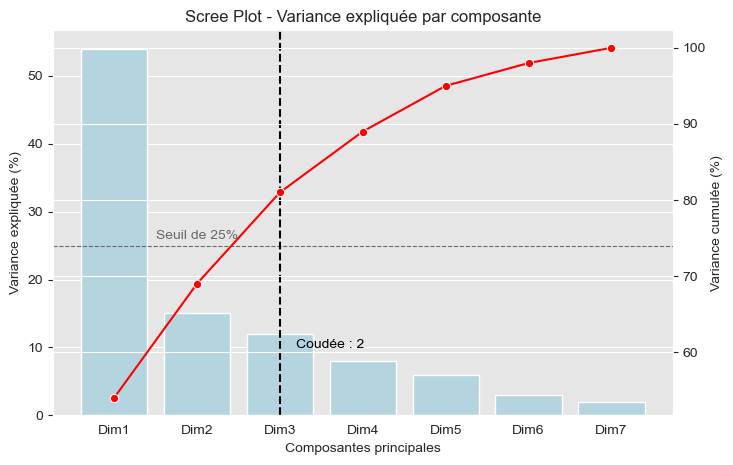

In [206]:
# Déterminer le "point de coudée" (méthode d'Elbow)
point_coude = np.argmax(np.diff(np.round(np.cumsum(pca.explained_variance_ratio_) * 100)) < 1) + 1  # Trouver la rupture de pente

# Création du Scree Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Graphique en barres pour la variance expliquée
sns.barplot(x="Dimension", y="% variance expliquée", data=comp, color="lightblue", ax=ax1)
ax1.set_ylabel("Variance expliquée (%)")
ax1.set_xlabel("Composantes principales")
ax1.set_title("Scree Plot - Variance expliquée par composante")

# Ajout de la ligne de référence (25%)
ax1.axhline(y=25, linewidth=0.8, color="dimgray", linestyle="--")
ax1.text(0.5, 26, "Seuil de 25%", color="dimgray")

# Ajout de la courbe de variance cumulée
ax2 = ax1.twinx()  # Second axe Y
sns.lineplot(x="Dimension", y="% cum. var. expliquée", data=comp, marker="o", color="red", ax=ax2)
ax2.set_ylabel("Variance cumulée (%)")

# Annotation du point de coudée
ax1.axvline(x=point_coude + 1, color="black", linestyle="--")
ax1.text(point_coude + 1.2, 10, f"Coudée : {point_coude+1}", color="black")

# Affichage
plt.show()

Ici, la méthode du coude et celle de Kaiser nous conseillent toutes deux de garder 2 axes principaux.

#### Les Représentations Graphiques
Le cercle des corrélations permet de visualiser l’association entre variables et axes. Plus une variable est fortement corrélée à un axe, plus elle contribue à la définition de cet axe


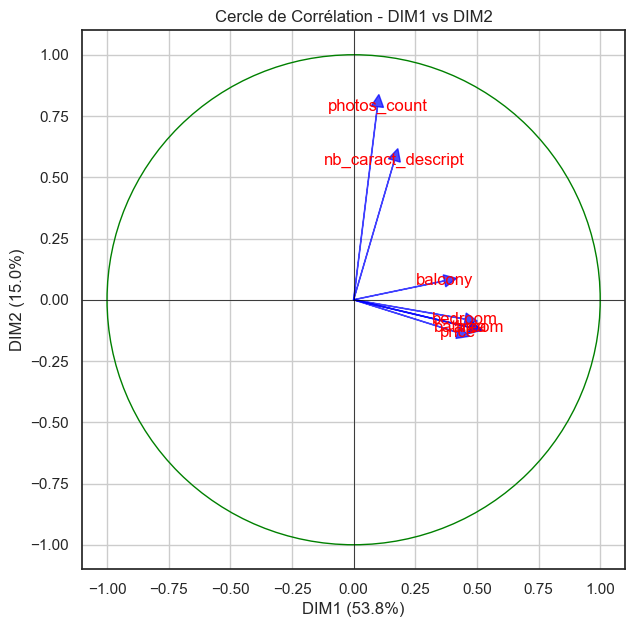

In [208]:
# Récupération des coordonnées des variables sur les composantes principales
pca_components = pca.components_.T  # Transposition pour avoir les variables en lignes
pca_df = pd.DataFrame(pca_components, index=variables_selectionnees, columns=[f"DIM{i+1}" for i in range(len(variables_selectionnees))])

# Choix des axes à afficher
dim_x = "DIM1"
dim_y = "DIM2"

# Création du Cercle de Corrélation
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(7, 7))

# Tracer le cercle unité
circle = plt.Circle((0, 0), 1, color="green", fill=False)
ax.add_artist(circle)

# Tracer les flèches pour chaque variable
for var in pca_df.index:
    x, y = pca_df.loc[var, dim_x], pca_df.loc[var, dim_y]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, color="blue", alpha=0.7)
    plt.text(x, y, var, fontsize=12, ha="center", va="center", color="red")

# Axes et quadrants
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

# Labels et titre
ax.set_xlabel(dim_x + f" ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(dim_y + f" ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"Cercle de Corrélation - {dim_x} vs {dim_y}")

# Affichage
plt.grid()
plt.show()

Avec les axes 1 et 2, nous pouvons voir que la majorité des flèches se situent entre le centre du cercle et son bord. Cela signifie que les variables sont moyennement représentées sur les axes choisis. En général, une flèche proche du bord du cercle signifie que la variable est bien représentée sur les axes alors qu'une flèche courte et proche du centre signifie que la variable n’est pas bien expliquée par les axes choisis. Elle influence d’autres dimensions.

Par exemple, la projection de la flèche `photos_count` sur l'axe DIM2 vaut 0.75, c'est à dire que `photos_count` et DIM2 ont une corrélation de 75%.

Nous pouvons également dire que les flèches proches les unes des autres sont fortement corrélées entre elles. C'est par exemple le cas de la variable `bedroom` et `bathroom`, même si en réalité il faut être prudent car le cercle des corrélations n'est pas fait pour interpréter la corrélation entre 2 variables initiales. Il est plutôt fait pour interpréter la corrélation entre une variable initiale et l'un des axes d'inertie dû fait que les flèches sont en fait des projections.


Il est donc préférable de n’interpréter que les flèches les plus longues, car les flèches les plus petites correspondent à des variables dites « mal représentées » sur le premier plan factoriel, et seulement avec les axes de projection.

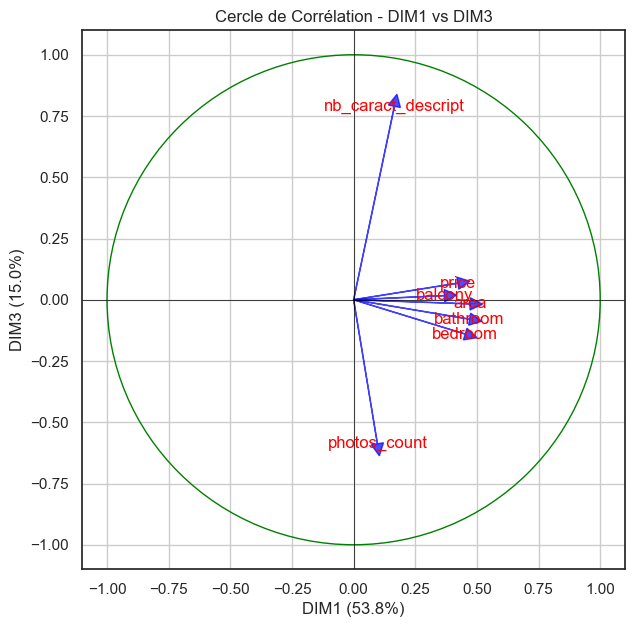

In [210]:
# Récupération des coordonnées des variables sur les composantes principales
pca_components = pca.components_.T  # Transposition pour avoir les variables en lignes
pca_df = pd.DataFrame(pca_components, index=variables_selectionnees, columns=[f"DIM{i+1}" for i in range(len(variables_selectionnees))])

# Choix des axes à afficher
dim_x = "DIM1"
dim_y = "DIM3"

# Création du Cercle de Corrélation
fig, ax = plt.subplots(figsize=(7, 7))

# Tracer le cercle unité
circle = plt.Circle((0, 0), 1, color="green", fill=False)
ax.add_artist(circle)

# Tracer les flèches pour chaque variable
for var in pca_df.index:
    x, y = pca_df.loc[var, dim_x], pca_df.loc[var, dim_y]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, color="blue", alpha=0.7)
    plt.text(x, y, var, fontsize=12, ha="center", va="center", color="red")

# Axes et quadrants
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

# Labels et titre
ax.set_xlabel(dim_x + f" ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(dim_y + f" ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"Cercle de Corrélation - {dim_x} vs {dim_y}")

# Affichage
sns.set_theme(style="whitegrid")
plt.grid()
plt.show()

Avec la projection sur les axes 1 et 3 nous pouvons voir que les variables `photos_count` et `nb_caract_descript` sont opposées l'une de l'autre. Cela signifie qu'elles sont "certainement" corrélées négativement.

Enfin, nous voyons que les variables restantes sont proches les unes des autres, l’angle qui les sépare est proche de 0 degré, et $cos(0)=1$, donc leur coefficient de corrélation est proche de 1. Ces variables sont très corrélées.

Pour conclure sur les statistiques descriptives, nous pouvons dire que les statistiques descriptives (univariées et multivariées) sont cruciales pour résumer et comprendre les données disponibles, mais elles ne permettent pas de prendre des décisions généralisables. C'est à qu'intervient l'inférence statistique. 

# Inférence Statistique

L’inférence statistique regroupe les méthodes qui permettent de tirer des conclusions sur une population à partir d’un échantillon, lorsqu’observer l’ensemble de la population est impossible ou trop coûteux. Elle repose sur la théorie des probabilités, afin de tenir compte de l’incertitude liée à l’utilisation d’un sous-ensemble de données.

L’inférence permet également de tester des hypothèses et de prendre des décisions éclairées. Par exemple, une entreprise peut comparer deux stratégies marketing à l’aide d’un test statistique pour déterminer si une différence de résultats est significative ou due au hasard. Grâce à des outils comme les intervalles de confiance ou les tests d’hypothèses, il est possible de mesurer la fiabilité des estimations et de quantifier l’erreur liée à l’échantillonnage.

Il existe une complémentarité entre analyse exploratoire et inférence statistique, en effet l’analyse exploratoire (statistiques univariées, multivariées) identifie tendances, corrélations ou structures dans les données, et aide à formuler des hypothèses tandis que l’inférence statistique, elle, permet de valider ces observations et de vérifier leur généralisabilité à la population.

Nous allons commencer par voir les tests de normalité.

## Les tests de normalité

Les tests de normalité permettent de vérifier si un échantillon suit une distribution normale, ce qui est une condition importante pour l’utilisation de nombreux tests statistiques paramétriques car dans le cas contraire, cela peut biaiser les résultats.

Il existe de pleins de tests de normalité dont les principaux sont :
- Le Test de Shapiro-Wilk : c'est l’un des tests les plus puissants pour des petits échantillons ($n<50$).
- Le Test de Kolmogorov-Smirnov (KS) : ce test compare la distribution des données avec une distribution normale. Il fonctionne bien pour des grands échantillons mais manque de puissance pour des petits. Cependant, il est sensible aux déviations aux extrêmes.
- Le Test de Lilliefors (version améliorée du test KS) : il est plus adapté aux petits échantillons que le test KS et est souvent utilisé quand la moyenne et l’écart-type ne sont pas connus à l’avance.
- Le Test d’Anderson-Darling est une variante du test KS, plus sensible aux écarts aux extrêmes. Il Fournit une mesure de la distance entre la distribution des données et la loi normale.
- Le Test de Jarque-Ber Se base sur la skewness (asymétrie) et la kurtosis (aplatissement) des données. Il est plus adapté pour des grands échantillons.

Nous n'allons voir ici que les tests de Lilliefors et de Jarque-Ber.

### Le Test de Lilliefors pour la normalité

Le test de Lilliefors compare la distribution empirique des données à une distribution estimé (comme la loi normale). En effet, il mesure la plus grande différence absolue entre la fonction de répartition empirique des données et la fonction de répartition d’une loi normale estimé et plus cette différence est grande, plus il est probable que les données ne suivent pas la loi normale.  

Nous posons les hypothèses suivantes :  
- $H_0$ : Les données suivent une distribution normale.  
- $H_1$ : Les données ne suivent pas une distribution normale.  

La statistique du test est :
$
D_n = \sup |F_n(x) - F(x)|
$
où :  
- $F_n(x)$ est la fonction de répartition empirique de l’échantillon,  
- $F(x)$ est la fonction de répartition d’une loi normale estimée à partir des données (avec la moyenne $\hat\mu$ et l’écart-type $\hat\sigma$).
- $\sup$ représente le supremum (la plus grande distance absolue observée entre les deux courbes).  

Si $D_n$ est trop grand, la p-valeur sera faible et on rejettera l’hypothèse de normalité.  

Ce test est une version modifiée du test de Kolmogorov-Smirnov qui supposait que les paramètres de la distribution théorique (moyenne et variance) soient connus.

In [218]:
# Importation du test de liliefors
from statsmodels.stats.diagnostic import lilliefors

# Liste des colonnes à tester
colonnes_a_tester = ['price', 'area', 'photos_count', 'bedroom', 'bathroom', 'balcony', 'nb_caract_descript', 'buyers_served']

# Définition du seuil de significativité
alpha = 0.05

# Appliquer le test de Lilliefors sur les colonnes sélectionnées en excluant les NaN
results = {}
for col in colonnes_a_tester:
    if col in df.columns:
        data_clean = df[col].dropna()  # Exclure les valeurs manquantes
        if len(data_clean) > 30:  # Vérifier qu'il y a suffisamment de données pour le test
            results[col] = lilliefors(data_clean)

# Affichage des résultats
for col, (stat, p) in results.items():
    print(f"Colonne : {col} | Statistique : {stat:.4f} | P-valeur : {p:.4f}")
    if p > alpha:
        print("  → On ne rejette pas H0 : les données suivent une loi normale.\n")
    else:
        print("  → On rejette H0 : les données ne suivent pas une loi normale.\n")

Colonne : price | Statistique : 0.2460 | P-valeur : 0.0010
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : area | Statistique : 0.1411 | P-valeur : 0.0010
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : photos_count | Statistique : 0.0716 | P-valeur : 0.0010
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : bedroom | Statistique : 0.2288 | P-valeur : 0.0010
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : bathroom | Statistique : 0.2222 | P-valeur : 0.0010
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : balcony | Statistique : 0.2466 | P-valeur : 0.0010
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : nb_caract_descript | Statistique : 0.2902 | P-valeur : 0.0010
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : buyers_served | Statistique : 0.3568 | P-valeur : 0.0010
  → On rejette H0 : les données ne suiv

Nous voyons que les colonnes sélectionnées ne suivent pas une loi normale, ce résultat est statistiquement significatif.

### Le Test de Jarque-Bera (JB) pour la normalité

 Le test de Jarque-Bera vérifie si la distribution d’un échantillon suit une loi normale en analysant l’asymétrie (skewness) et l’aplatissement (kurtosis) de la distribution.  

Le test repose sur le principe qu'une distribution normale doit être symétrique (skewness = 0) et avoir un aplatissement de 3 (kurtosis = 3). Le test JB mesure donc l’écart entre ces valeurs théoriques et celles observées.  

Nous posons les hypothèses suivantes :
- $H_0$ : Les données suivent une distribution normale.  
- $H_1$ : Les données ne suivent pas une distribution normale.  

La statistique du test JB est :
$$
JB = \frac{n}{6} \left( S^2 + \frac{(K - 3)^2}{4} \right)
$$
où :  
- $n$ est la taille de l’échantillon,  
- $S$ est la skewness (mesure de l’asymétrie),  
- $K$ est la kurtosis (mesure de l’aplatissement).  

Sous $H_0$, la statistique suit approximativement une loi du Khi-deux à 2 degrés de liberté ($\chi^2(2)$). Si la statistique JB est trop grande, cela signifie que la distribution est trop asymétrique ou trop aplatie, et donc qu’elle n’est pas normale. C'est un test qui est moins précis si la distribution présente des écarts uniquement sur les queues de la distribution (extrêmes).  

In [222]:
# Importation du test
from scipy.stats import jarque_bera

# Définition de la liste des colonnes à tester
colonnes_a_tester = ['price', 'area', 'photos_count', 'bedroom', 'bathroom', 'balcony', 'nb_caract_descript', 'buyers_served']

# Définition du seuil de significativité
alpha = 0.05

# Appliquer le test de Jarque-Bera sur les colonnes sélectionnées en excluant les NaN
results = {}
for col in colonnes_a_tester:
    if col in df.columns:
        data_clean = df[col].dropna()  # Exclure les valeurs manquantes
        if len(data_clean) > 30:  # Vérifier qu'il y a suffisamment de données pour le test
            results[col] = jarque_bera(data_clean)

# Affichage des résultats
for col, (stat, p) in results.items():
    print(f"Colonne : {col} | Statistique : {stat:.4f} | P-valeur : {p:.4f}")
    if p > alpha:
        print("  → On ne rejette pas H0 : les données suivent une loi normale.\n")
    else:
        print("  → On rejette H0 : les données ne suivent pas une loi normale.\n")

Colonne : price | Statistique : 75130.6759 | P-valeur : 0.0000
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : area | Statistique : 1579868.4303 | P-valeur : 0.0000
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : photos_count | Statistique : 341.1302 | P-valeur : 0.0000
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : bedroom | Statistique : 332.0886 | P-valeur : 0.0000
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : bathroom | Statistique : 70.4155 | P-valeur : 0.0000
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : balcony | Statistique : 1681.2089 | P-valeur : 0.0000
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : nb_caract_descript | Statistique : 37793.8696 | P-valeur : 0.0000
  → On rejette H0 : les données ne suivent pas une loi normale.

Colonne : buyers_served | Statistique : 340507.9183 | P-valeur : 0.0000
  → On rejet

Nous obtenons le même résultat avec le test de Jarque-Bera.

## Les Tests d'adéquation de loi

Pour tester si un échantillon suit une loi de Poisson, nous pouvons utiliser plusieurs méthodes. L'une des plus courantes est de comparer les données de l'échantillon avec les paramètres théoriques d'une loi de Poisson en utilisant un test du Chi-2.

On pose d'abord les hypothèses suivantes :
- $H_0$ : L'échantillon suit une loi de Poisson avec un certain paramètre $\lambda$.
- $H_1$ : L'échantillon ne suit pas une loi de Poisson.

Dans une loi de Poisson, le paramètre $\lambda$ représente la moyenne et la variance. Nous allons estimer $\lambda$ à partir de l'échantillon en prenant la moyenne de l'échantillon.

Nous devons calculer les fréquences observées et attendues :  
   - Fréquences observées (O) : le nombre de fois chaque valeur apparaît dans notre échantillon.
   - Fréquences attendues (E) : Pour chaque valeur, nous devons calculer la fréquence attendue en utilisant la fonction de masse de probabilité (fonction de densité d'une loi de probabilité discrète) de la loi de Poisson :
     $$
     P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}
     $$
     où $k$ est le nombre d'occurrences dans l'échantillon, et $\lambda$ est l'estimation de la moyenne de l'échantillon.


Le test du Chi-2 compare les fréquences observées et attendues. La statistique du Chi-2 est donnée par :
   $$
   \chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}
   $$
   où $O_i$ et $E_i$ sont respectivement les fréquences observées et attendues pour chaque catégorie.

Enfin, nous devons comparer la statistique du Chi-2 à la valeur critique provenant de la table de Chi-2 avec un certain degré de liberté ($k-1$) et un seuil de significativité $\alpha$ (généralement 0.05).

In [226]:
# Importation des fonctions nécessaires
from scipy.stats import poisson, chisquare

# Choix de l'échantillon
data = df['bedroom'].copy
data = data().dropna()

# Estimation du paramètre λ (moyenne de l'échantillon)
lambda_hat = np.mean(data)

# Calcul des fréquences observées (O)
observed_freq = pd.Series(data).value_counts().sort_index()

# Assurer que max_value soit un entier
max_value = int(observed_freq.index.max())

# Calcul des fréquences attendues (E) selon la loi de Poisson
expected_freq = np.array([poisson.pmf(k, lambda_hat) * len(data) for k in range(max_value + 1)])

# Aligner les indices des fréquences observées et attendues
all_values = np.arange(max_value + 1)
observed_freq_aligned = observed_freq.reindex(all_values, fill_value=0)
expected_freq_aligned = expected_freq

# Vérifier si les sommes des fréquences observées et attendues sont égales
observed_sum = observed_freq_aligned.sum()
expected_sum = expected_freq_aligned.sum()

# Si les sommes ne sont pas égales, normaliser les fréquences attendues
if observed_sum != expected_sum:
    expected_freq_aligned = expected_freq_aligned * observed_sum / expected_sum

# Comparer les fréquences observées et attendues avec le test du Chi-2
chi2_stat, p_value = chisquare(observed_freq_aligned, expected_freq_aligned)

# Afficher les résultats
print(f"Statistique du chi carré : {chi2_stat:.4f}")
print(f"P-valeur : {p_value:.4f}")

# Interpréter les résultats
alpha = 0.05
if p_value > alpha:
    print("On ne rejette pas H0 : l'échantillon suit une loi de Poisson.")
else:
    print("On rejette H0 : l'échantillon ne suit pas une loi de Poisson.")

Statistique du chi carré : 360.2868
P-valeur : 0.0000
On rejette H0 : l'échantillon ne suit pas une loi de Poisson.


Les variables bedroom, bathroom, balcony et photos_count ne suivent pas une loi de poisson.

En testant l'hypothèse que les variables suivent une loi du $\chi^2$ :

In [229]:
# Importation des tests du Chi-2
from scipy.stats import chi2, chisquare

# Sélection de la variable
data = df['balcony'].dropna()

# Vérifier qu'on a encore des données après nettoyage
if data.empty:
    raise ValueError("Erreur : La colonne 'bedroom' ne contient pas de valeurs valides après nettoyage.")

# Définir les intervalles (bins) pour l'histogramme
num_bins = 7
observed_freq, bin_edges = np.histogram(data, bins=num_bins)

# Degré de liberté (généralement = nombre de classes - 1)
#df_chi2 = num_bins - 1  
df_chi2 = 2

# Calculer les fréquences attendues sous l'hypothèse de loi du Chi-2
expected_freq = np.diff(chi2.cdf(bin_edges, df_chi2)) * len(data)

# Ajustement : S'assurer que la somme des fréquences attendues est la même que celle des fréquences observées
expected_freq = expected_freq * (sum(observed_freq) / sum(expected_freq))

# Correction : Éviter les fréquences nulles
expected_freq[expected_freq == 0] = 1e-6

# Effectuer le test du Chi-2
chi2_stat, p_value = chisquare(observed_freq, expected_freq)

# Afficher les résultats
print(f"Statistique du Chi-2 : {chi2_stat:.4f}")
print(f"P-valeur : {p_value:.4f}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("On ne rejette pas H0 : l'échantillon suit une loi du Chi-2.")
else:
    print("On rejette H0 : l'échantillon ne suit pas une loi du Chi-2.")

Statistique du Chi-2 : 311.4490
P-valeur : 0.0000
On rejette H0 : l'échantillon ne suit pas une loi du Chi-2.


## La Comparaison entre 2 moyennes

Les tests de comparaison des moyennes entre différents échantillons permettent de vérifier si les différences observées entre les moyennes des groupes sont statistiquement significatives. Il existe plusieurs tests pour cela, les plus connus sont le test-t de comparaison de moyennes et le test ANOVA. Cependant, comme les hypothèses de normalité ou d’homogénéité des variances ne sont pas respectées, il est préférable d'utiliser un autre test.

### Le Test de Kruskal-Wallis

Le test de Kruskal-Wallis, nommé en référence à William Kruskal et Wilson Allen Wallis, est un test statistique non paramétrique utilisé pour déterminer si les médianes de deux groupes ou plus diffèrent. Ce test est une alternative au test ANOVA à un facteur lorsque les hypothèses de normalité ou d'homoscédasticité ne sont pas respectées. Il compare les sommes des rangs des différentes groupes plutôt que les moyennes, ce qui permet d'éviter les hypothèses de distribution normale. La statistique de test est basée sur la distribution $\chi^2$.

Un test de Kruskal-Wallis significatif indique qu'au moins un échantillon domine stochastiquement un autre échantillon, mais il ne spécifie pas où cette dominance se produit.

Nous posons les hypothèses suivantes :
- Hypothèse nulle ($H_0$) : Les groupes ont la même distribution (les médianes sont égales).
- Hypothèse alternative ($H_1$) : Au moins un groupe a une distribution différente.

Le test de Kruskal-Wallis repose sur le classement des valeurs et l'utilisation d'une statistique H. Il faut tout d'abord mélanger toutes les observations des groupes et attribuer un rang à chaque observation (1 pour la plus petite, 2 pour la suivante, etc.). En cas d’ex aequo, nous devons attribuer la moyenne des rangs.

Il faut après calculer la statistique $H$ du test qui est donnée par la formule :
$$
H = \frac{12}{N (N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)
$$

où :
- $N$ = nombre total d'observations,
- $k$ = nombre de groupes,
- $n_i$ = nombre d'observations dans le groupe $i$,
- $R_i$ = somme des rangs du groupe $i$.

Enfin, nous allons comparer cette statistique avec la loi du chi-deux. En effet, sous l’hypothèse $H_0$, la statistique $H$ suit approximativement une loi du chi-deux avec $k-1$ degrés de liberté.

Si $H$ est grand, la différence entre les groupes est importante. Pour comparer la valeur obtenue avec un seuil critique basé sur la loi du $\chi^2$, il faut calculer la p-valeur :  
  - Si p-value > $\alpha$ (ex. 0.05) : On ne rejette pas $H_0$ → Pas de différence significative.
  - Si p-value < $\alpha$ : On rejette $H_0$ → Au moins un groupe est significativement différent.

In [234]:
# Importation du test
from scipy.stats import kruskal

# Séparer les groupes en fonction d'une variable qualitative
group_A = df[df['contact'] == 'agent']['price']
group_B = df[df['contact'] == 'owner']['price']

# Le test de Kruskal-Wallis
stat, p_value = kruskal(group_A, group_B)

# Afficher les résultats
print(f"Statistique H de Kruskal-Wallis : {stat:.4f}")
print(f"P-valeur : {p_value:.4f}")

# Interprétation
alpha = 0.05
if p_value > alpha:
    print("On ne rejette pas H0 : Pas de différence significative entre les groupes.")
else:
    print("On rejette H0 : Les groupes sont significativement différents.")

Statistique H de Kruskal-Wallis : nan
P-valeur : nan
On rejette H0 : Les groupes sont significativement différents.


# Modèle prédictif

La régression linéaire simple a pu être montré graphiquement lors de l'[analyse bivariée](#Analyse-de-2-variables-quantitatives). Pour ne pas alourdir le projet, nous passerons directement à la présentation de la régression linéaire multiple.


## La Régression linéaire multiple

 La régression linéaire multiple est une extension de la régression linéaire simple où l'on explique une variable dépendante $Y$ par plusieurs variables indépendantes $X_1, X_2, ..., X_k$. Mathématiquement, le modèle de régression linéaire multiple s’écrit sous la forme :
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_k X_k + \varepsilon
$$

où :  
- $Y$ = Variable dépendante (ce qu'on cherche à expliquer)  
- $X_1, X_2, ..., X_k$ = Variables explicatives (ce qui influence $Y$)  
- $\beta_0$ = Ordonnée à l'origine (intercept)  
- $\beta_1, \beta_2, ..., \beta_k$ = Coefficients de régression (effet des $X$ sur $Y$)  
- $\varepsilon$ = Erreur aléatoire 

L’objectif est d’estimer les coefficients $\beta$ pour comprendre l’influence des variables explicatives sur $Y$.

Nous commençons par poser les hypothèses standard de la Régression linéaire, soient :
- Hypothèse 1 : La matrice $X$ est de plein rang-colonne, donc $X'X$ est inversible. Cela signifie que l'on ne peut pas obtenir une variable explicative du modèle en combinant linéairement 2 ou plus autres variables du modèle. 

- Hypothèse 2 : La matrice $X$ est non-aléatoire ($X$ et $\varepsilon$ ne sont pas linéairement corrélés). La nature nous donne donc toujours le même jeu de données, cela permet d'avoir un $\hat\beta$ non biaisé.

- Hypothèse 3 : Les effets sur la variable à expliquer des variables de second ordre se compensent entre eux à chaque observation, donc $\mathbb{E}[\varepsilon] = 0$.

Avec ces 3 hypothèses, l'estimateur des MCO est sans biais.

- Hypothèse 4.1 : Il y a homoscédasticité des perturbations, les perturbations ont donc toutes une variance identique.

- Hypothèse 4.2 : Il y a non-autocorrélation des perturbations, il n'y a donc pas de relations linéaires entre les erreurs.

Avec les 4 premières hypothèses, l'estimateur des MCO est dit BLUE (théorème de Gauss-Markov), c'est donc l'estimateur sans biais le plus précis.

- Hypothèse 5 : L'estimateur des MCO converge en probabilité vers $\beta$

- Hypothèse 6 : Les erreurs sont normalement distribuées.

Ces dernières hypothèses permettent d'étendre les propriétés de l'estimateur des MCO à distance finie à l'ensemble des estimateurs (linéaires ou non). Cet estimateur est donc le plus précis possible.

 
Les coefficients $\beta$ sont estimés par la méthode des moindres carrés ordinaires (MCO), qui cherche à minimiser la somme des carrés des erreurs :
$$
argmin_{\beta} (\varepsilon'\varepsilon)
$$

Cela nous donne :
$$
\hat\beta = (X'X)^{-1}X'Y
$$

Pour avoir plus de détails sur la construction des hypothèses et des résulats, nous pouvons nous référer au cours d'Econométrie de L2.

En python cela donne (cas 1) :

In [239]:
# Importation de statsmodels
import statsmodels.api as sm

df_cleaned3 = df_encoded[['area', 'price', 'bathroom', 'bedroom', 'num_floor']].dropna()

# Définition des variables
Y = df_cleaned3['price']
X = df_cleaned3[['area','bathroom', 'bedroom', 'num_floor']]

# Ajout de la constante
X = sm.add_constant(X)

# Création du modèle
model = sm.OLS(Y,X).fit()

# Résumé des résultats
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     246.1
Date:                Wed, 16 Apr 2025   Prob (F-statistic):          9.80e-146
Time:                        15:49:10   Log-Likelihood:                -12084.
No. Observations:                 971   AIC:                         2.418e+04
Df Residuals:                     966   BIC:                         2.420e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.588e+04   6028.591     -9.269      0.0

Avant de commenter les résultats, refaisons une régression en supprimant les outliers (cas 2).

In [241]:
# Importation du zscore
from scipy.stats import zscore

# Sélection des colonnes pertinentes et suppression des NaN
df_cleaned3 = df_encoded[['area', 'price', 'bathroom', 'bedroom', 'num_floor']].dropna()

# Calcul des Z-scores
z_scores = np.abs(zscore(df_cleaned3))

# Seuil de détection des outliers (valeurs au-delà de |3|)
threshold = 3
df_no_outliers = df_cleaned3[(z_scores < threshold).all(axis=1)]

# Définition des variables
Y = df_no_outliers['price']
X = df_no_outliers[['area', 'bathroom', 'bedroom', 'num_floor']]

# Ajout de la constante
X = sm.add_constant(X)

# Création du modèle
model = sm.OLS(Y, X).fit()

# Résumé des résultats
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     387.2
Date:                Wed, 16 Apr 2025   Prob (F-statistic):          3.17e-196
Time:                        15:49:10   Log-Likelihood:                -11068.
No. Observations:                 935   AIC:                         2.215e+04
Df Residuals:                     930   BIC:                         2.217e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.244e+04   3723.328     -3.340      0.0

La suppression des valeurs aberrantes a enlevé 36 observations dans le jeu de données. Cependant, il y a 935 observations ce qui reste suffisant pour une régression linéaire.

Globalement, le $R^2 = 0.625$ signifie qu'environ 62.5% de la variance du prix est expliquée par les variables indépendantes, avant suppression des outliers le $R^2$ était de 50,5%, donc avoir enlevé des observations aberrantes a amélioré la 'qualité' du modèle. Dans les deux cas, le $R^2$ ajusté est proche du $R^2$, cela signifie que l’ajout de variables explicatives ne pénalise pas significativement le modèle.  

De même, Dans les 2 cas la Prob (F-Statistic) est proche de 0. Le modèle est globalement significatif, ce qui signifie qu’au moins une variable explicative a un effet significatif sur le prix. 

Pour passer à l'interprétation des coefficients, nous pouvons dire que dans le cas 2 que toutes les variables sont statistiquement significatives (p-value < 0.05), elles ont donc un impact réel sur le prix. Ce qui n'est pas le cas dans le cas 1 où l'effet de la variable 'bedroom' à 11,1% de chance d'être dû au hasard.

Pour interpréter quelques coefficients du cas 2, nous pouvons dire qu'une augmentation de 1 unité de surface entraîne une augmentation moyenne du prix de 42.79 roupies, toutes choses égales par ailleurs. De même, ajouter une salle de bains augmente le prix de 25 030 roupied en moyenne. C’est la variable avec le plus fort impact positif sur le prix. En revanche et contre-intuitivement, ajouter une chambre fait baisser le prix de 15 170 roupies. Cela peut être dû à une corrélation avec d’autres facteurs (ex : les maisons avec plus de chambres ont peut-être une surface plus petite par chambre, ce qui impacte négativement le prix). Enfin, chaque location dans un étage supplémentaire diminue le prix de 3 775 roupies.

Que ce soit le cas 1 ou le 2, nous n'avons pas mis toutes les variables dans le modèle. Nous avons choisi les variables selon leurs effets sur le R-squared et leurs P>|t pour avoir les meilleurs résultats globaux. En mettant toutes les variables dans le modèle nous avons pu voir que les effets de certaines variables avaient 92,5% (la variable balcony) de chance d'être dû au hasard, c'est énorme.

En regardant les statistiques en bas des tableaux, nous pouvons voir un Durbin-Watson proche de 2 (dans les 2 cas) ce qui indique l'absence d’autocorrélation des résidus. C'est une bonne chose.

En revanche, l'Omnibus et le Jarque-Bera des 2 cas étant proche de 0, cela suggère que les résidus ne suivent pas une distribution normale, ce qui peut affecter la fiabilité des intervalles de confiance, même si en enlevant les valeurs extrêmes nous avons réussi à réduire les statistiques.

Le Condition Number est proche de 5400, c'est une valeur élevée qui peut indiquer un problème de multicolinéarité (les variables explicatives sont corrélées entre elles). 

En conclusion, le modèle est exploitable mais peut être encore amélioré en enlevant les variables ayant un problème de multicolinéarité et également en transformant les données. Si cela n'améliore pas les résultats il est toujours possible d'essayer d'autres modèles (à cause de la non-normalité des résidus).

### La Multicolinéarité

La multicolinéarité est un phénomène qui se produit lorsque deux ou plusieurs variables indépendantes sont fortement corrélées entre elles. Cela peut poser plusieurs problèmes pour l'interprétation et la stabilité du modèle.

En effet, en présence de multicolinéarité, les coefficients de la régression deviennent très sensibles aux petites variations des données. Cela signifie que de légères modifications dans les données peuvent entraîner des changements importants dans les coefficients estimés. Il y a une instabilité des coefficients et il est donc difficile de déterminer l'effet individuel de chaque variable sur la variable dépendante.

De plus, les erreurs standards des coefficients augmentent, ce qui peut conduire à des tests d'hypothèses moins fiables. Les variables peuvent sembler non significatives alors qu'elles le sont réellement.

Nous pouvons détecter la multicolinéarité à l'aide d'une matrice de corrélation des variables indépendantes pour identifier les paires de variables fortement corrélées. Il faut cependant faire remarquer d'une forte corrélation d'induit pas toujours une multicolinéarité alors que l'inverse est vrai.

Le facteur d'inflation de la variance (VIF) mesure l'impact de la multicolinéarité sur les coefficients de régression. Un VIF élevé (généralement supérieur à 10) indique une multicolinéarité problématique.

Le VIF est calculé à partir du coefficient de détermination $R^2$ obtenu en régressant une variable sur les autres soit pour une variable explicative $X_j$, son VIF est donné par :
$$
VIF_j = \frac{1}{1 - R_j^2}
$$

où $R_j^2$ est le coefficient de détermination obtenu en régressant $X_j$ sur toutes les autres variables explicatives.

In [245]:
# Importation des librairies
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Normalisation des données
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_no_outliers), columns=df_no_outliers.columns)

# Calcul du VIF pour chaque variable
vif_data = pd.DataFrame()
vif_data["Variable"] = df_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(df_scaled.values, i) for i in range(df_scaled.shape[1])]

# Affichage des résultats
print(vif_data)

# Identification des variables problématiques
vif_threshold = 10  # Seuil habituel pour détecter la multicolinéarité
high_vif = vif_data[vif_data["VIF"] > vif_threshold]

if not high_vif.empty:
    print("\n⚠️ Attention : Les variables suivantes présentent une forte multicolinéarité (VIF > 10) :\n")
    print(high_vif)
else:
    print("\n✅ Aucune variable ne présente de forte multicolinéarité.")

    Variable       VIF
0       area  4.326637
1      price  2.665185
2   bathroom  4.549608
3    bedroom  3.881218
4  num_floor  1.035416

✅ Aucune variable ne présente de forte multicolinéarité.


Si nous étions en présence de multicolinéarité, les solutions possibles pour contrer ce problème serait par exemple la suppression de certaines variables fortement corrélées entre elles, l'utilisation de techniques de régularisation comme la régression Ridge ou Lasso pour réduire l'impact de la multicolinéarité ou encore la transformation des données pour réduire la corrélation.

Nous allons maintenant passer à l'autre problème que nous avons.

### La Non-Normalité des Erreurs

En régression linéaire, l'un des principaux postulats du modèle est que les résidus suivent une distribution normale $\epsilon \sim \mathcal{N}(0, \sigma^2)$. Lorsque cette hypothèse n'est pas respectée, cela peut affecter l'inférence statistique et la fiabilité des tests sur les coefficients du modèle.

Pour vérifier la normalité des Erreurs, il est possible d'utiliser un test de [normalité](#Les-tests-de-normalité) (Shapiro-Wilk, Kolmogorov-Smirnov, Anderson-Darling, etc.). Cependant, il est à noter que la normalité des résidus est surtout importante pour les petits échantillons. En effet, avec un grand échantillon (n > 30-50), on peut s'appuyer sur le théorème central limite, qui rend la normalité moins cruciale.

En cas de non-normalité, plusieurs solutions s'offrent à nous. Tout d'abord, il est possible de transformer les variables avec par exemple une transformation logarithmique $Y' = \log(Y)$ (avec $Y$ strictement positif). Il est également possible d'ajouter des variables explicatives pertinentes car un manque de variables importantes peut causer des résidus non normaux.

Enfin, il est parfois nécessaire d'utiliser des modèles plus robustes comme la régression quantile, la régression robuste (RANSAC, Theil-Sen) ou d'utiliser des modèles non linéaires (régression GAM, arbres de décision, etc.).

A partir de la régression faite plus haut, cela donne :

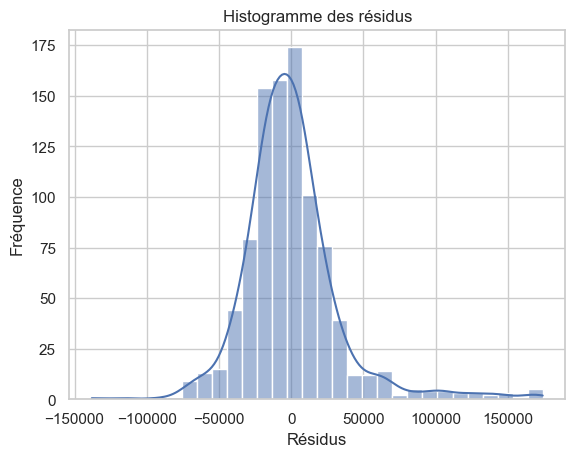

In [248]:
# Extraction des résidus
residuals = model.resid

## Histogramme des résidus
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Histogramme des résidus")
plt.show()

En regardant le QQ plot cela donne :

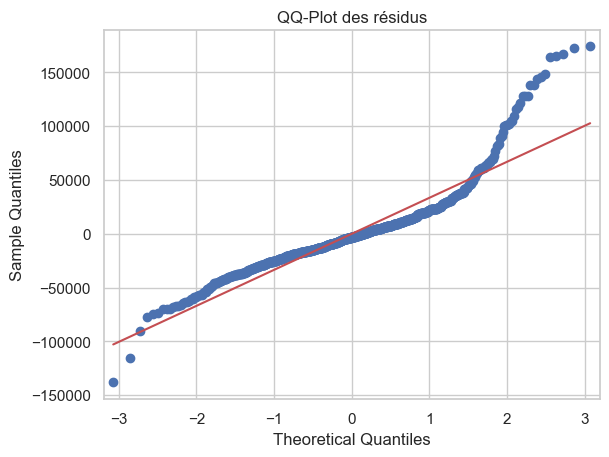

In [250]:
# QQ-Plot (Quantile-Quantile Plot)
import scipy.stats as stats

# Création du graphique
sm.qqplot(residuals, line='s')
plt.title("QQ-Plot des résidus")
plt.show()

Comme ces deux graphiques nous le montre, la distribution des résidus semblent normalement distribuées. Cependant, la queue de distribution assez lourde à droite pose problème et indique une non-normalité des erreurs que nous pouvons vérifier avec un test.

In [252]:
# Test de Kolmogorov-Smirnov
from scipy.stats import kstest

stat, p_value = kstest(residuals, 'norm')
print(f"Statistique du test : {stat}, p-value : {p_value}")

if p_value < 0.05:
    print("Les résidus ne suivent pas une loi normale.")
else:
    print("Les résidus suivent une loi normale.")

Statistique du test : 0.558288770053476, p-value : 5.789465018306566e-275
Les résidus ne suivent pas une loi normale.


Ce résultat nous indique qu'il est préférable de transformer les données ou d'utiliser un autre modèle. Cependant nous allons nous arrêter ici pour la réalisation de ce projet car il a couvert la majorité des sujets que nous voulions traiter, même s'il est de facto encore possible d'analyser ce jeu de données par de multiples méthodes.

# Conclusion

L'objectif principal de ce projet était d'explorer et d'analyser les annonces de location immobilière à New Delhi en utilisant des techniques avancées d'analyse de données. À travers un processus structuré allant du web scraping au nettoyage des données, nous avons pu identifier les principales tendances du marché et les facteurs influençant les loyers.

L'analyse a débuté par l'extraction des données via le web scraping à partir du site MagicBricks. Ce processus nous a permis de récupérer 1400 annonces brutes, qui ont ensuite été nettoyées et consolidées en un jeu de données structuré de 1000 annonces exploitables. Le prétraitement des données a inclus plusieurs étapes essentielles comme la suppression des colonnes inutiles (ex : liens d'images, informations non pertinentes), la conversion des formats de prix (ex : ₹1 Lac → 100 000 INR) et de surface pour assurer une uniformité, la détection et gestion des valeurs manquantes avec différentes approches (suppression, imputation par la moyenne/médiane, ou utilisation de valeurs par défaut) et enfin l'encodage des variables catégorielles en variables numériques via le One-Hot Encoding pour faciliter l'analyse statistique.

Une analyse approfondie des caractéristiques des annonces a permis de dégager des tendances clés sur le marché locatif à New Delhi. Par exemple, le loyer moyen s’élève à 64 347 INR/mois, mais la médiane est de 38 000 INR/mois, indiquant une distribution asymétrique. Cette différence s’explique par la présence de quelques biens de luxe dont le loyer est beaucoup plus élevé que la majorité des logements.

Cette analyse nous a également appris que certains facteurs influencent les loyers. Par exemple, les appartements meublés sont généralement plus chers que les logements non meublés. Le nombre de salles de bains et de chambres a un impact significatif sur le prix, la surface habitable (area) influence fortement le loyer, bien que des anomalies existent et l’emplacement (quartier, proximité de services) joue un rôle essentiel dans la fixation des loyers. 

L'analyse a révélé l'existence de valeurs aberrantes avec certaines annonces affichant des loyers extrêmement élevés ou bas par rapport à la distribution globale et globalement des anomalies dans la superficie et le nombre d'étages.

Ce projet m'a amené a adopté une méthodologie robuste avec un processus d’analyse de données bien structuré, couvrant toutes les étapes depuis la récupération des données jusqu’à l’exploration statistique. J'ai pu découvrir la majorité des étapes du pré-traitement nécessaire à une analyse de données avec par exemple la correction des incohérences, la suppression des doublons ou encore transformation des données pour une meilleure exploitation. De plus, l'utilisation de Python m'a aidé à créer des graphiques et des indicateurs qui m'ont permis de mieux comprendre la structure du marché locatif.

Cependant, ce projet m'a montré qu'il était difficile d'obtenir des données de qualité, par exemple dans notre jeu de données certaines informations clés manquaient pour plusieurs annonces (l'orientation, le nombre de salle de bains, etc.). De plus, certaines informations qualitatives (ex : état du bien, attractivité du quartier) ne sont pas prises en compte numériquement ce qui peut avoir comme conséquence des modèles mal formulés. Par ailleurs, l’échantillon de 1000 annonces est représentatif mais pourrait être élargi pour obtenir une vision plus globale du marché. 

Ce projet est une première approche et est loin d'être complet. En effet, il est encore possible d'aller plus loin avec des modélisations avancées et d'autres modèles pour tirer le plein potentiel du jeu de données. Il est également possible d'intégration d’autres sources de données (indices de prix immobilier, tendances économiques, ...) pour affiner les analyses. Ainsi, cette étude fournit une base solide pour aller plus loin dans l’analyse du marché locatif et pourrait être utilisée pour des recommandations stratégiques aux investisseurs ou aux agences immobilières.

C'est un projet qui m'a tenu à coeur car il m'a permis de développer de nouvelles compétences, tant en programmation avec l'utilisation omni-présente de Python qu'avec les concepts statistiques que j'ai découvert. A travers ce projet, j'ai eu l'occasion d'avoir un aperçu du métier de Data Scientist, vers lequel j'aimerai me diriger. Cependant, il m'a montré que c'était un univers extrêmement vaste et qu'il me restait énormément de choses à apprendre, tant en statistiques, qu'en programmation ou encore en compétences transversales avec la présentation du projet à d'autres personnes.


Merci d'être arrivé jusqu'ici.